# Gnuradio GFSK Decoding

## Works great on short file

Captured: IQ=5518 complex, disc=5518, lpf=5518, clk=346, bits=346


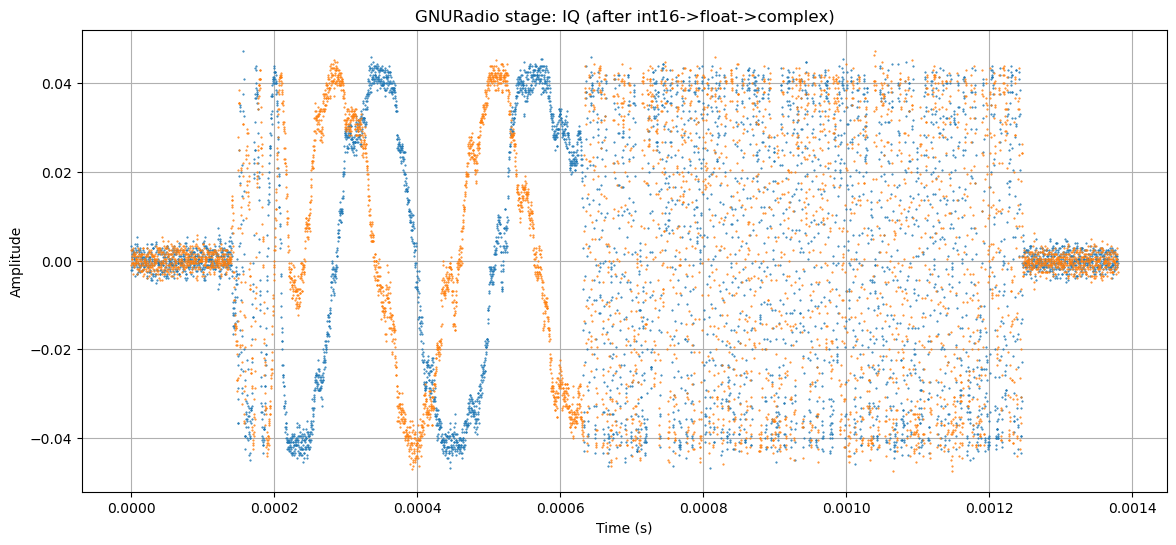

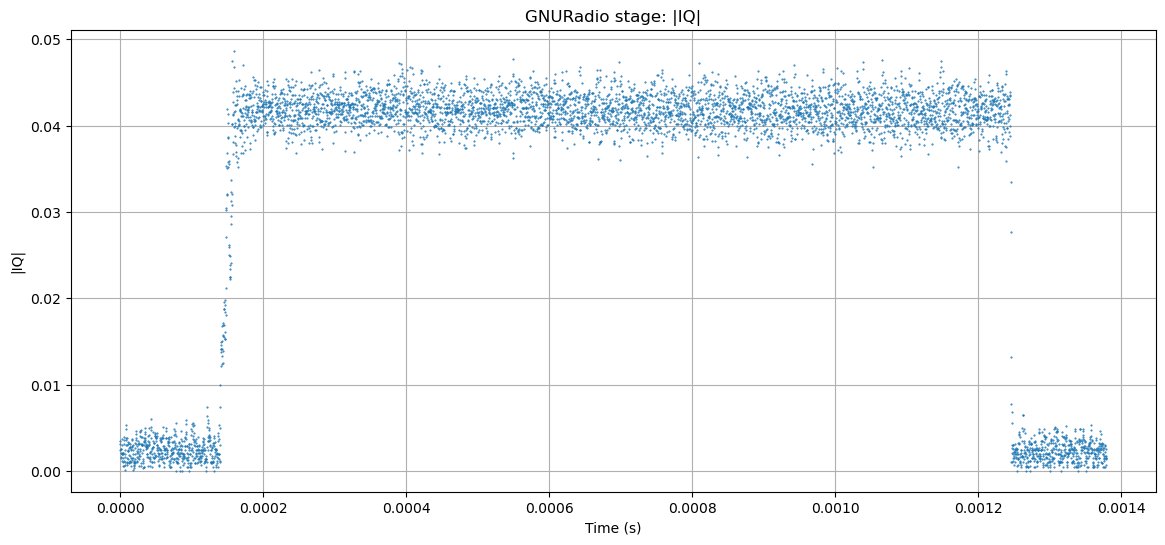

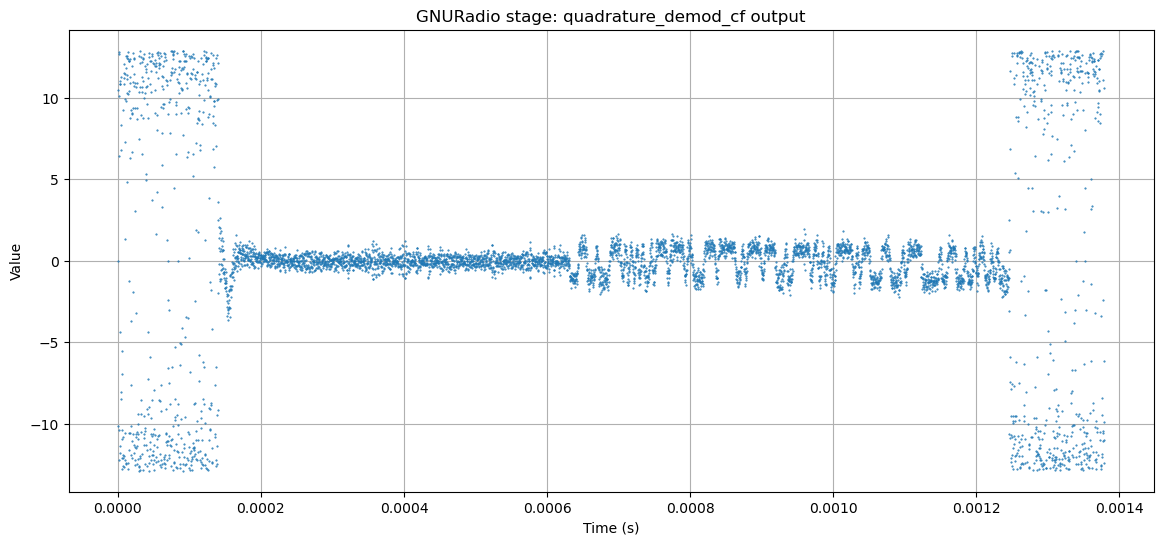

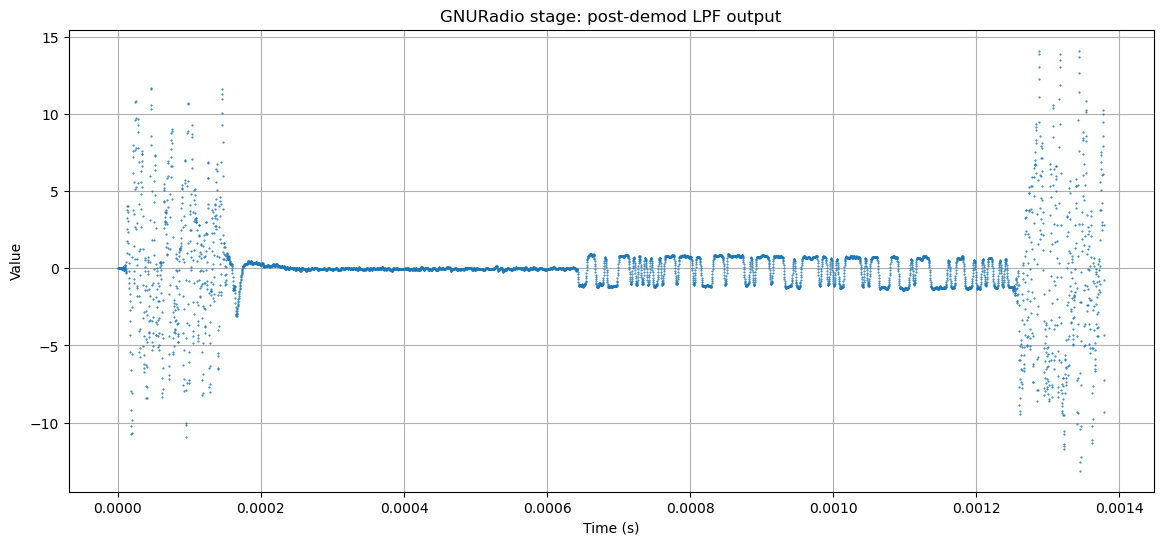

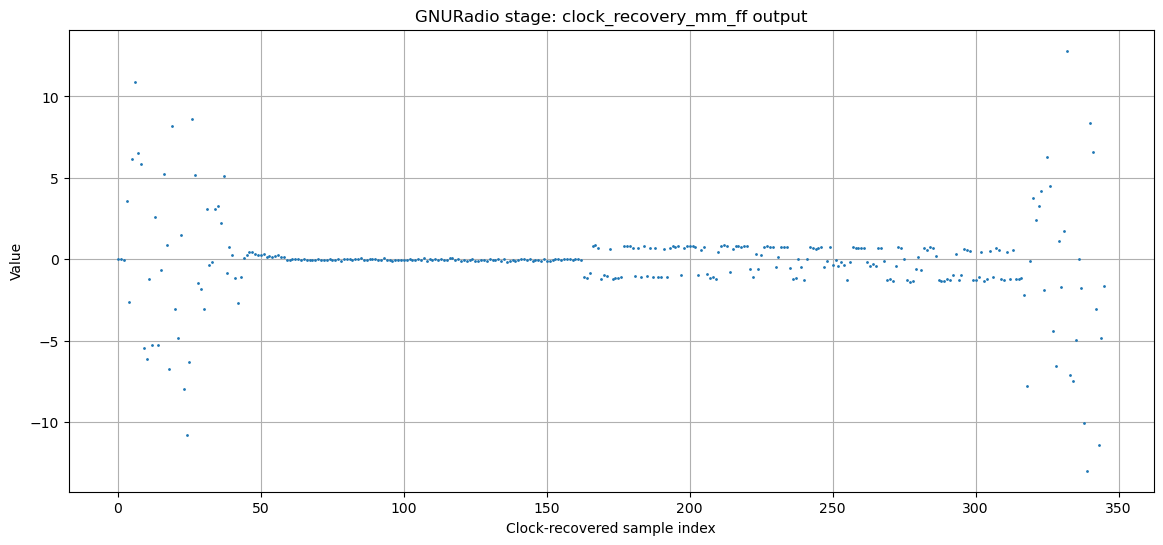

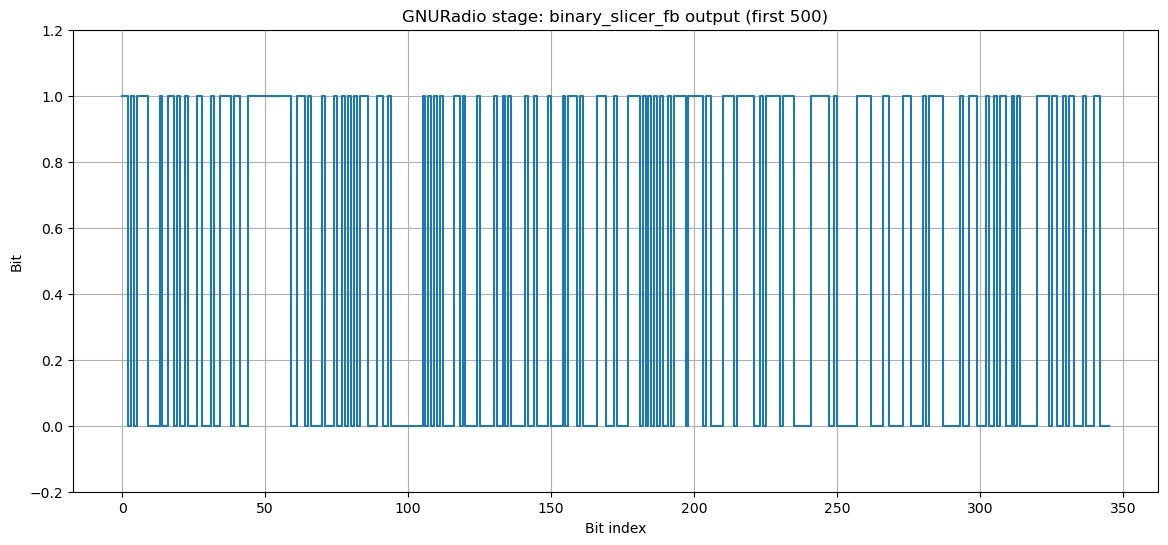

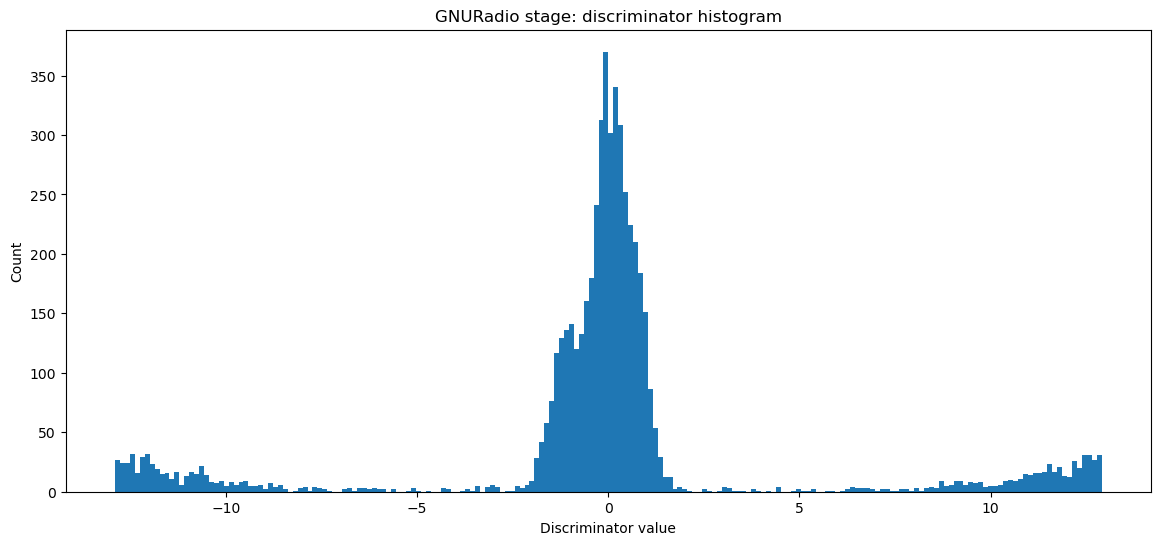

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS (edit)
# -----------------------------
iq_file = r"ls-OFF-4M-p6M.complex32s"
#iq_file = r"ls-OFF-4M-p6M-02.complex32s"
samp_rate = 4_000_000
samples_per_symbol = 16

# Quad Gain
df = 155_000  # FSK frequency deviation (freq_spacing / 2)
quad_gain = samp_rate / (2*np.pi*df)   # ≈ 4.11
#quad_gain = 4.11
n_plot = 20000  # complex samples captured for plotting
# -----------------------------

tb = gr.top_block("tap_each_stage")

# Source: int16 stream I0,Q0,I1,Q1,...
src = blocks.file_source(gr.sizeof_short, iq_file, False)

# Split interleaved shorts into I and Q streams
deint = blocks.deinterleave(gr.sizeof_short)

# int16 -> float ~[-1, 1]
# i_f = blocks.short_to_float(1, 1.0 / 32768.0)
# q_f = blocks.short_to_float(1, 1.0 / 32768.0)
i_f = blocks.short_to_float(1, 32768.0)
q_f = blocks.short_to_float(1, 32768.0)

# float I/Q -> complex
iq_c = blocks.float_to_complex(1)

# Limit run length (complex samples)
head_c = blocks.head(gr.sizeof_gr_complex, n_plot)

# ---- taps (vector sinks) ----
tap_iq   = blocks.vector_sink_c()   # complex IQ after conversion
tap_disc = blocks.vector_sink_f()   # after quadrature demod
tap_lpf  = blocks.vector_sink_f()   # after LPF
tap_clk  = blocks.vector_sink_f()   # after clock recovery
tap_bits = blocks.vector_sink_b()   # after slicer (bytes 0/1)

# 2-FSK discriminator
fsk_disc = analog.quadrature_demod_cf(quad_gain)

# Post-demod LPF
# sym_rate = samp_rate / float(samples_per_symbol)
# lpf_taps = firdes.low_pass(1.0, samp_rate, 0.45 * sym_rate, 0.20 * sym_rate, WIN)
# lpf = filter.fir_filter_fff(1, lpf_taps)
# Replace the sym_rate-derived LPF with a deviation-friendly LPF
lpf_cutoff_hz = 350_000   # try 250k, 350k, 450k
lpf_trans_hz  = 100_000

lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

# Clock recovery (Mueller & Muller)
clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

# Bit slicer
slicer = digital.binary_slicer_fb()

# ---- connections ----
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# Use the same limited IQ stream for all downstream taps
tb.connect(iq_c, head_c)

tb.connect(head_c, tap_iq)
tb.connect(head_c, fsk_disc)
tb.connect(fsk_disc, tap_disc)
tb.connect(fsk_disc, lpf)
tb.connect(lpf, tap_lpf)
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk)
tb.connect(clockrec, slicer)
tb.connect(slicer, tap_bits)

tb.run()

# ---- pull data for plotting ----
iq   = np.asarray(tap_iq.data(),   dtype=np.complex64)
disc = np.asarray(tap_disc.data(), dtype=np.float32)
lpfv = np.asarray(tap_lpf.data(),  dtype=np.float32)
clk  = np.asarray(tap_clk.data(),  dtype=np.float32)
bits = np.asarray(tap_bits.data(), dtype=np.uint8)

print(f"Captured: IQ={iq.size} complex, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")


fig_size = (14, 6)
marker_size = 1

t_iq = np.arange(iq.size) / samp_rate
t_f  = np.arange(disc.size) / samp_rate

# 1) IQ (I and Q)
plt.figure(figsize=fig_size)
plt.plot(t_iq, iq.real, '.', markersize=marker_size); 
plt.plot(t_iq, iq.imag, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("GNURadio stage: IQ (after int16->float->complex)")
plt.grid()
plt.show()

# 2) |IQ|
plt.figure(figsize=fig_size)
plt.plot(t_iq, np.abs(iq), '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.title("GNURadio stage: |IQ|")
plt.grid()
plt.show()

# 3) Discriminator output
plt.figure(figsize=fig_size)
plt.plot(t_f, disc, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: quadrature_demod_cf output")
plt.grid()
plt.show()

# 4) LPF output
plt.figure(figsize=fig_size)
plt.plot(np.arange(lpfv.size) / samp_rate, lpfv, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: post-demod LPF output")
plt.grid()
plt.show()

# 5) Clock recovery output (index axis; sample rate has changed)
marker_size = 2
plt.figure(figsize=fig_size)
plt.plot(clk, '.', markersize=marker_size); 
plt.xlabel("Clock-recovered sample index")
plt.ylabel("Value")
plt.title("GNURadio stage: clock_recovery_mm_ff output")
plt.grid()
plt.show()

# 6) Bits (first 500)
plt.figure(figsize=fig_size)
m = min(500, bits.size)
plt.step(np.arange(m), bits[:m], where="post", markersize=marker_size); 
plt.ylim(-0.2, 1.2)
plt.xlabel("Bit index")
plt.ylabel("Bit")
plt.title("GNURadio stage: binary_slicer_fb output (first 500)")
plt.grid()
plt.show()

# Optional: histogram of discriminator (often shows two lobes for 2-FSK)
plt.figure(figsize=fig_size)
plt.hist(disc, bins=200)
plt.xlabel("Discriminator value")
plt.ylabel("Count")
plt.title("GNURadio stage: discriminator histogram")
plt.show()


In [2]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
#pattern_str = "1110001"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(indices)

[166]


## Adding Masking for Demodulaltion, otherwise magnitude of quadrature_demod is way off

- required threshold stats

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS (edit)
# -----------------------------
iq_file = r"ls-OFF-4M-p6M.complex32s"
#iq_file = r"ls-OFF-4M-p6M-02.complex32s"
samp_rate = 4_000_000
samples_per_symbol = 16

# Quad Gain
df = 155_000  # FSK frequency deviation (freq_spacing / 2)
quad_gain = samp_rate / (2*np.pi*df)   # ≈ 4.11
#quad_gain = 4.11
n_plot = 20000  # complex samples captured for plotting
# -----------------------------

tb = gr.top_block("tap_each_stage")

# Source: int16 stream I0,Q0,I1,Q1,...
src = blocks.file_source(gr.sizeof_short, iq_file, False)

# Split interleaved shorts into I and Q streams
deint = blocks.deinterleave(gr.sizeof_short)

# int16 -> float ~[-1, 1]
i_f = blocks.short_to_float(1, 1.0 / 32768.0)
q_f = blocks.short_to_float(1, 1.0 / 32768.0)

# float I/Q -> complex
iq_c = blocks.float_to_complex(1)

# Limit run length (complex samples)
head_c = blocks.head(gr.sizeof_gr_complex, n_plot)

# ---- taps (vector sinks) ----
tap_iq   = blocks.vector_sink_c()   # complex IQ after conversion
tap_disc = blocks.vector_sink_f()   # after quadrature demod
tap_lpf  = blocks.vector_sink_f()   # after LPF
tap_clk  = blocks.vector_sink_f()   # after clock recovery
tap_bits = blocks.vector_sink_b()   # after slicer (bytes 0/1)

# 2-FSK discriminator
fsk_disc = analog.quadrature_demod_cf(quad_gain)

# Post-demod LPF
# sym_rate = samp_rate / float(samples_per_symbol)
# lpf_taps = firdes.low_pass(1.0, samp_rate, 0.45 * sym_rate, 0.20 * sym_rate, WIN)
# lpf = filter.fir_filter_fff(1, lpf_taps)
# Replace the sym_rate-derived LPF with a deviation-friendly LPF
lpf_cutoff_hz = 350_000   # try 250k, 350k, 450k
lpf_trans_hz  = 100_000

lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

# Clock recovery (Mueller & Muller)
clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

# Bit slicer
slicer = digital.binary_slicer_fb()


# Masking
# ========================================================================
mag = blocks.complex_to_mag(1)

# Choose thresholds based on your envelope stats
# lo/hi provide hysteresis: below lo -> 0, above hi -> 1
gate = blocks.threshold_ff(0.004, 0.006, 0)   # <-- tune these two numbers

disc_gate = blocks.multiply_ff(1)

# Optional: clamp insane discriminator spikes even during burst edges
clip = blocks.clip_ff(-5.0, 5.0)   # tune range; start wide

# Optional: DC removal (if your build has no dc_blocker_ff, skip for now)
# Use moving average subtraction if needed:
dc_ma = blocks.moving_average_ff(64, 1.0/64.0, 4000)
dc_sub = blocks.sub_ff()
# ========================================================================




# ---- connections ----
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# Use the same limited IQ stream for all downstream taps
tb.connect(iq_c, head_c)

tb.connect(head_c, tap_iq)
tb.connect(head_c, fsk_disc)



tb.connect(fsk_disc, tap_disc)
tb.connect(fsk_disc, lpf)
tb.connect(lpf, tap_lpf)
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk)
tb.connect(clockrec, slicer)
tb.connect(slicer, tap_bits)

tb.run()

# ---- pull data for plotting ----
iq   = np.asarray(tap_iq.data(),   dtype=np.complex64)
disc = np.asarray(tap_disc.data(), dtype=np.float32)
lpfv = np.asarray(tap_lpf.data(),  dtype=np.float32)
clk  = np.asarray(tap_clk.data(),  dtype=np.float32)
bits = np.asarray(tap_bits.data(), dtype=np.uint8)

print(f"Captured: IQ={iq.size} complex, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")


fig_size = (14, 6)
marker_size = 1

t_iq = np.arange(iq.size) / samp_rate
t_f  = np.arange(disc.size) / samp_rate

# 1) IQ (I and Q)
plt.figure(figsize=fig_size)
plt.plot(t_iq, iq.real, '.', markersize=marker_size); 
plt.plot(t_iq, iq.imag, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("GNURadio stage: IQ (after int16->float->complex)")
plt.grid()
plt.show()

# 2) |IQ|
plt.figure(figsize=fig_size)
plt.plot(t_iq, np.abs(iq), '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.title("GNURadio stage: |IQ|")
plt.grid()
plt.show()

# 3) Discriminator output
plt.figure(figsize=fig_size)
plt.plot(t_f, disc, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: quadrature_demod_cf output")
plt.grid()
plt.show()

# 4) LPF output
plt.figure(figsize=fig_size)
plt.plot(np.arange(lpfv.size) / samp_rate, lpfv, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: post-demod LPF output")
plt.grid()
plt.show()

# 5) Clock recovery output (index axis; sample rate has changed)
marker_size = 2
plt.figure(figsize=fig_size)
plt.plot(clk, '.', markersize=marker_size); 
plt.xlabel("Clock-recovered sample index")
plt.ylabel("Value")
plt.title("GNURadio stage: clock_recovery_mm_ff output")
plt.grid()
plt.show()

# 6) Bits (first 500)
plt.figure(figsize=fig_size)
m = min(500, bits.size)
plt.step(np.arange(m), bits[:m], where="post", markersize=marker_size); 
plt.ylim(-0.2, 1.2)
plt.xlabel("Bit index")
plt.ylabel("Bit")
plt.title("GNURadio stage: binary_slicer_fb output (first 500)")
plt.grid()
plt.show()

# Optional: histogram of discriminator (often shows two lobes for 2-FSK)
plt.figure(figsize=fig_size)
plt.hist(disc, bins=200)
plt.xlabel("Discriminator value")
plt.ylabel("Count")
plt.title("GNURadio stage: discriminator histogram")
plt.show()


AttributeError: module 'gnuradio.blocks' has no attribute 'clip_ff'

In [2]:
bits.shape

(346,)

In [3]:
bits

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,

In [4]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
#pattern_str = "1110001"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(indices)


[166]


In [5]:
bits[166:]

array([1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0], dtype=uint8)

In [6]:
print(bits)

[1 1 0 1 0 1 1 1 1 0 0 0 0 1 0 0 1 1 0 1 0 0 1 0 0 0 1 1 0 0 0 1 0 0 1 1 1
 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 0 0 0 0 1 0 0 0
 1 0 0 1 0 1 0 1 0 1 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0
 1 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0
 0 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1
 0 1 0 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 0
 0 1 0 1 1 1 1 1 0 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 0 0 1 0 0 0 0 0 0 0 1 1
 1 1 1 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0
 1 1 1 0 0 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1 1 1 1 0 1 1 0 0 1 0 1 1
 0 0 0 1 0 0 0 1 1 0 0 0 0]


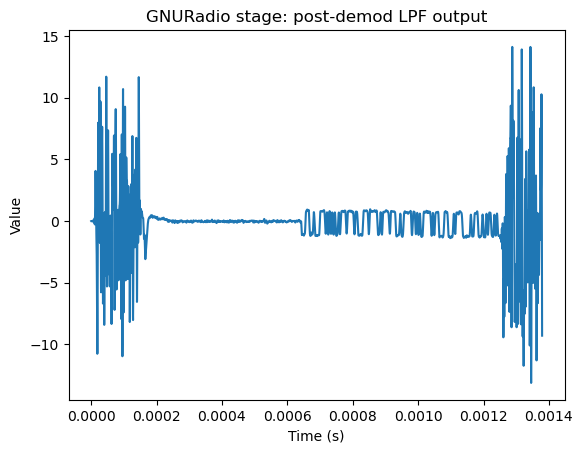

In [7]:
plt.figure()
plt.plot(np.arange(lpfv.size) / samp_rate, lpfv)
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: post-demod LPF output")
plt.show()

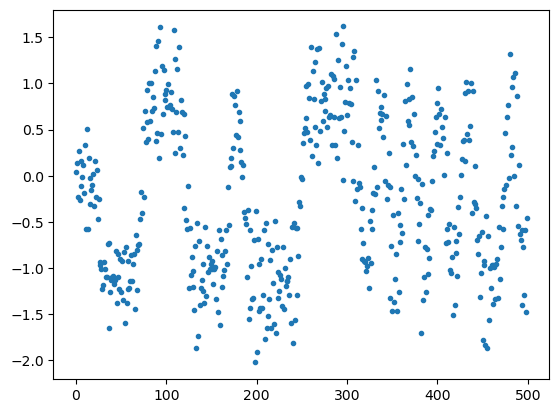

In [8]:
plt.figure()
plt.plot(disc[2500:3000],'.')

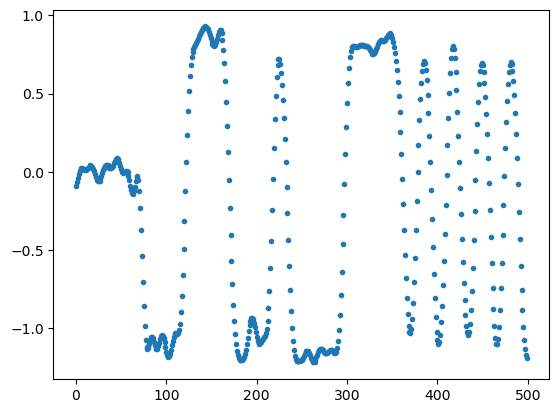

In [9]:
plt.figure()
#plt.plot(lpfv[2500:3000],'.')
plt.plot(lpfv[2500:3000], '.')

Done. Wrote ALL decoded bits to: out_bits.bin


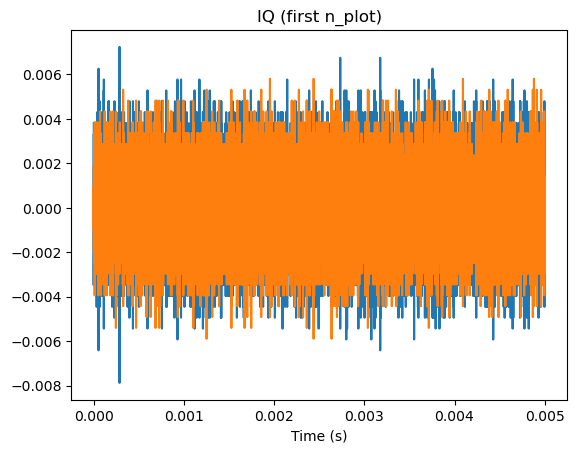

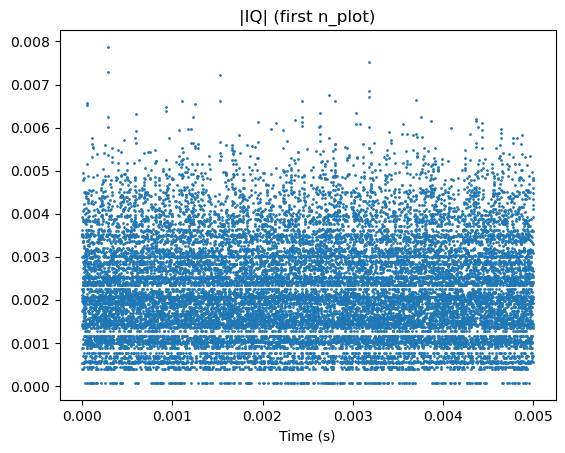

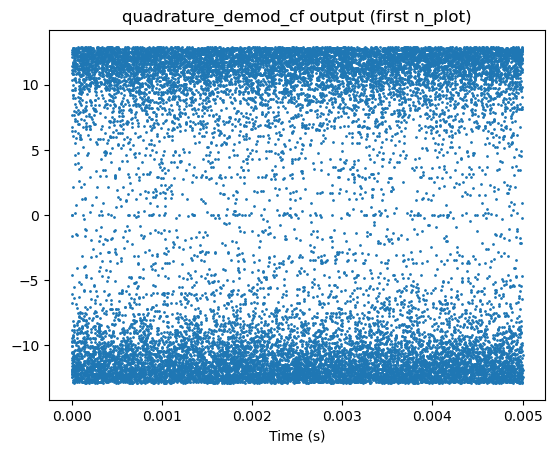

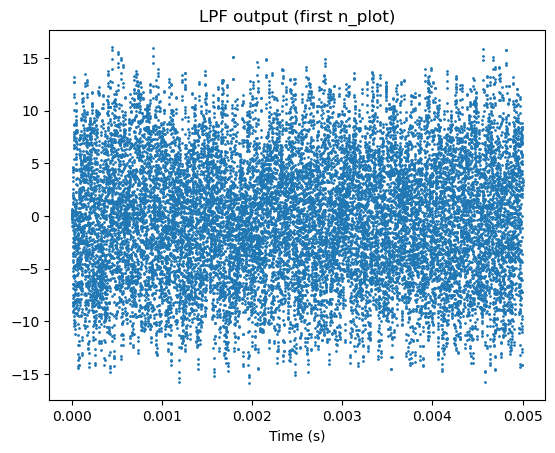

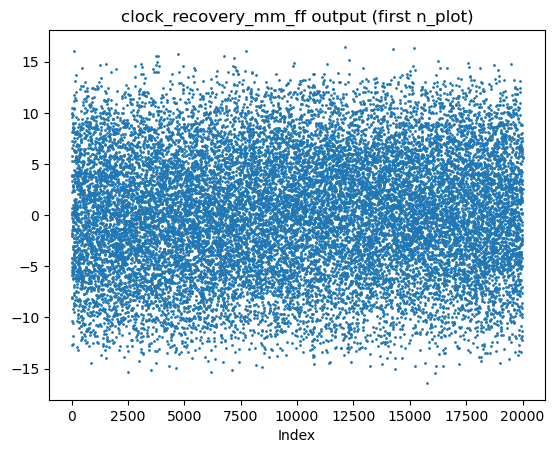

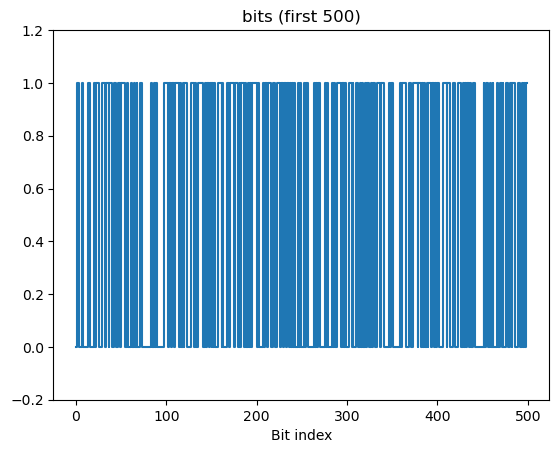

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M.complex32s"
iq_file = r"ls-OFF-4M-p6M-02.complex32s"   # int16 interleaved I,Q
out_bits_file = "out_bits.bin"            # FULL decoded bits (bytes 0/1)

samp_rate = 4_000_000
samples_per_symbol = 16

# Quad Gain
df = 155_000  # FSK frequency deviation (freq_spacing / 2)
quad_gain = samp_rate / (2*np.pi*df)   # ≈ 4.11
#quad_gain = 4.11

lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# tap files (FULL streams; we will only plot first n_plot when reading)
tap_iq_file   = "tap_iq.c64"
tap_disc_file = "tap_disc.f32"
tap_lpf_file  = "tap_lpf.f32"
tap_clk_file  = "tap_clk.f32"
tap_bits_file = "tap_bits.u8"

n_plot = 20000  # plotting only
# -----------------------------

tb = gr.top_block("full_decode_with_file_taps")

# Source: int16 I,Q
src = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f = blocks.short_to_float(1, 32768.0)
q_f = blocks.short_to_float(1, 32768.0)
iq_c = blocks.float_to_complex(1)

# Demod chain
demod = analog.quadrature_demod_cf(quad_gain)
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)
slicer = digital.binary_slicer_fb()

# Main output
bits_sink = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# Tap sinks (files)
tap_iq_sink   = blocks.file_sink(gr.sizeof_gr_complex, tap_iq_file, False)
tap_disc_sink = blocks.file_sink(gr.sizeof_float,      tap_disc_file, False)
tap_lpf_sink  = blocks.file_sink(gr.sizeof_float,      tap_lpf_file,  False)
tap_clk_sink  = blocks.file_sink(gr.sizeof_float,      tap_clk_file,  False)
tap_bits_sink = blocks.file_sink(gr.sizeof_char,       tap_bits_file, False)

# Connections
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# Tap IQ (full)
tb.connect(iq_c, tap_iq_sink)

# Demod
tb.connect(iq_c, demod)
tb.connect(demod, tap_disc_sink)

# LPF
tb.connect(demod, lpf)
tb.connect(lpf, tap_lpf_sink)

# Clock recovery
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk_sink)

# Bits
tb.connect(clockrec, slicer)
tb.connect(slicer, tap_bits_sink)
tb.connect(slicer, bits_sink)

tb.run()
print("Done. Wrote ALL decoded bits to:", out_bits_file)

# -----------------------------
# Plot first n_plot samples from tap files
# -----------------------------
def read_c64(path, n):
    # GNU Radio gr_complex is complex64 (2x float32)
    raw = np.fromfile(path, dtype=np.complex64, count=n)
    return raw

def read_f32(path, n):
    return np.fromfile(path, dtype=np.float32, count=n)

def read_u8(path, n):
    return np.fromfile(path, dtype=np.uint8, count=n)

iq   = read_c64(tap_iq_file, n_plot)
disc = read_f32(tap_disc_file, n_plot)
lpfv = read_f32(tap_lpf_file,  n_plot)
clk  = read_f32(tap_clk_file,  n_plot)
bits = read_u8(tap_bits_file,  n_plot)

t_iq = np.arange(len(iq)) / samp_rate
t_f  = np.arange(len(disc)) / samp_rate

plt.figure(); plt.plot(t_iq, iq.real, markersize=2); plt.plot(t_iq, iq.imag, markersize=2)
plt.title("IQ (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

plt.figure(); plt.plot(t_iq, np.abs(iq), '.', markersize=2)
plt.title("|IQ| (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

plt.figure(); plt.plot(t_f, disc, '.', markersize=2)
plt.title("quadrature_demod_cf output (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

plt.figure(); plt.plot(t_f, lpfv, '.', markersize=2)
plt.title("LPF output (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

plt.figure(); plt.plot(clk, '.', markersize=2)
plt.title("clock_recovery_mm_ff output (first n_plot)"); plt.xlabel("Index"); plt.show()

plt.figure(); m = min(500, len(bits)); plt.step(np.arange(m), bits[:m], where="post"); plt.ylim(-0.2, 1.2)
plt.title("bits (first 500)"); plt.xlabel("Bit index"); plt.show()


In [ ]:
def read_c64_all(path):
    return np.fromfile(path, dtype=np.complex64)

def read_f32_all(path):
    return np.fromfile(path, dtype=np.float32)

def read_u8_all(path):
    return np.fromfile(path, dtype=np.uint8)

iq   = read_c64_all(tap_iq_file)
disc = read_f32_all(tap_disc_file)
lpfv = read_f32_all(tap_lpf_file)
clk  = read_f32_all(tap_clk_file)
bits = read_u8_all(tap_bits_file)

print(
    "IQ:", iq.size,
    "disc:", disc.size,
    "lpf:", lpfv.size,
    "clk:", clk.size,bbbb
    "bits:", bits.size
)

## Adding Masking

# New code with new blocks

Done. Wrote ALL decoded bits to: out_bits.bin


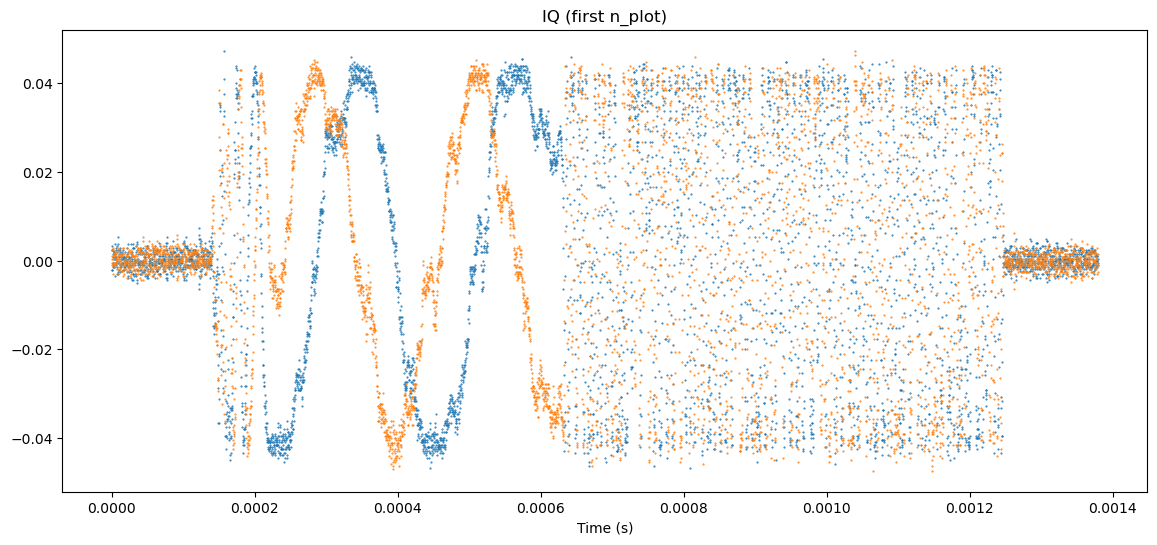

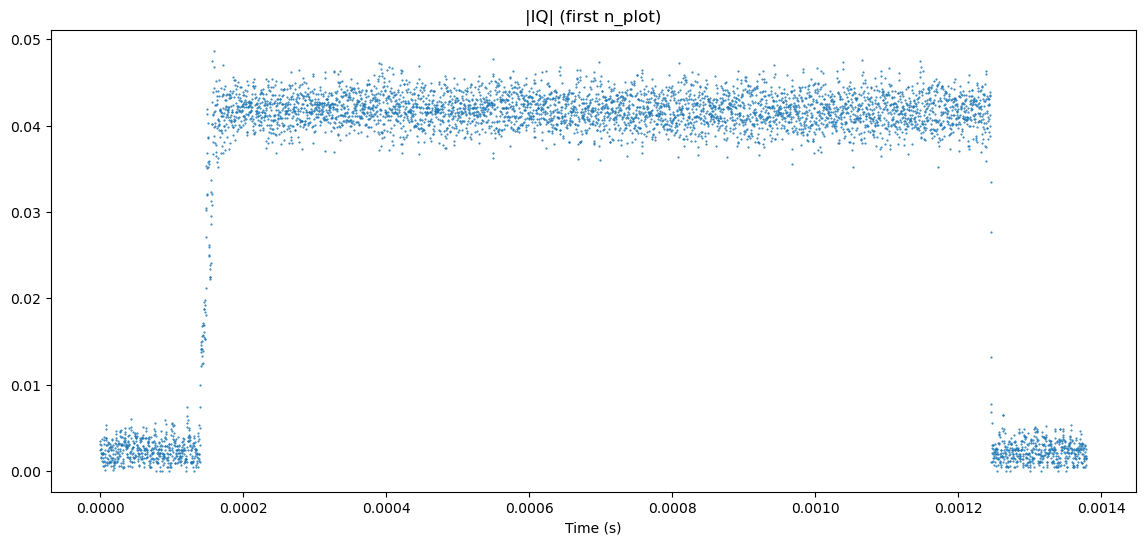

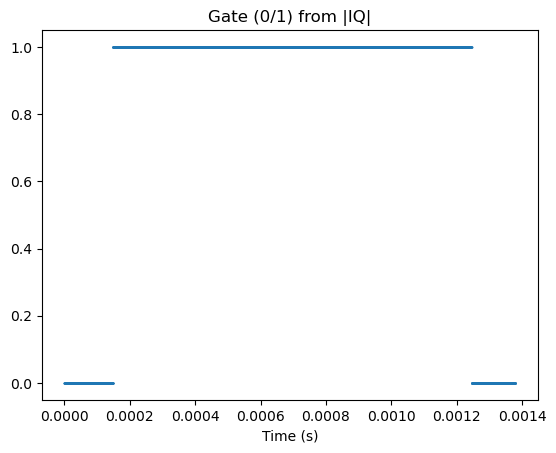

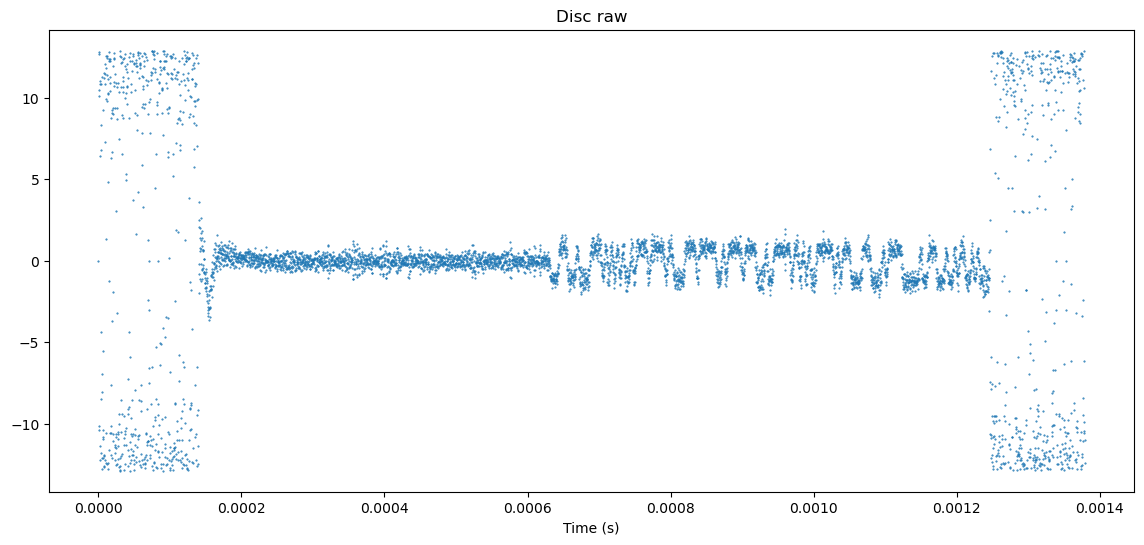

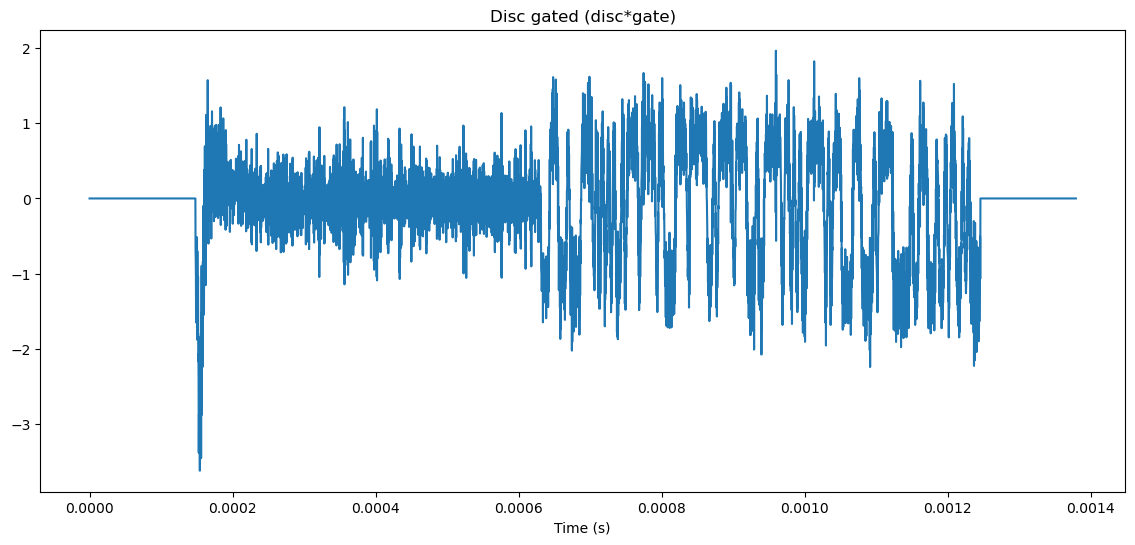

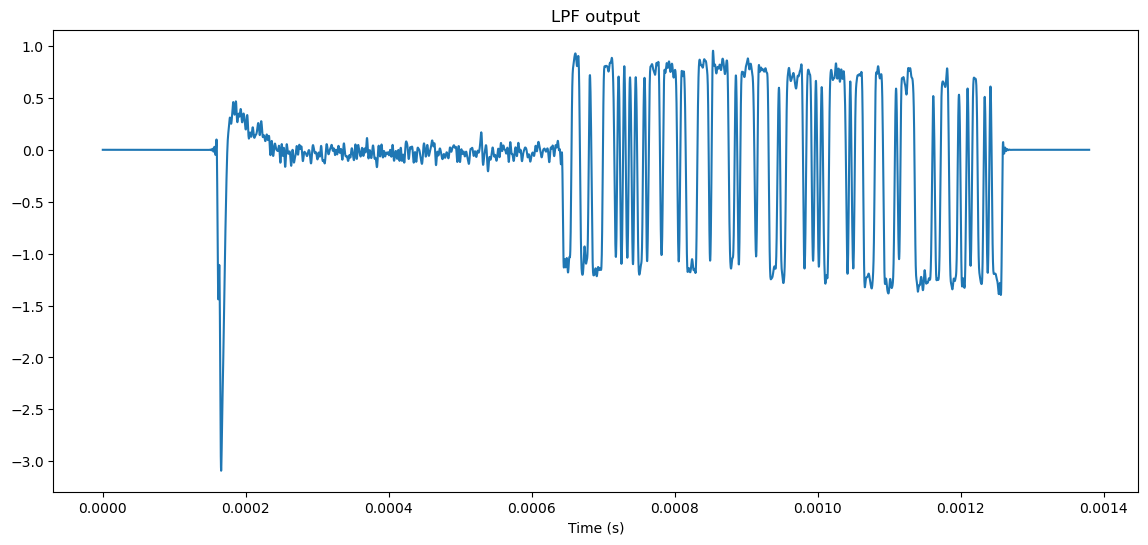

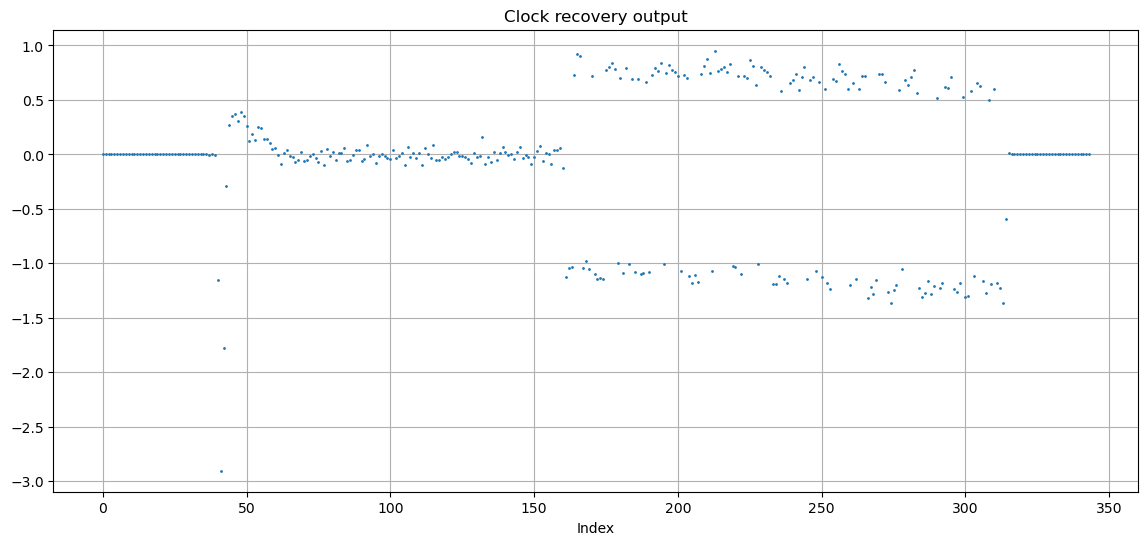

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M.complex32s"
#iq_file = r"ls-OFF-4M-p6M-02.complex32s"   # int16 interleaved I,Q
out_bits_file = "out_bits.bin"            # FULL decoded bits (bytes 0/1)

samp_rate = 4_000_000
samples_per_symbol = 16

# Quadrature demod gain: normalize to ~±1 for ±df
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)   # ≈ 4.11

# LPF on discriminator
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# Gate thresholds on |IQ| (tune these!)
# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.03 # above -> gate=1  (hysteresis)
gate_lo = 0.02 # below -> gate=0
gate_initial = 0

# tap files (FULL streams)
tap_iq_file   = "tap_iq.c64"
tap_mag_file  = "tap_mag.f32"
tap_gate_file = "tap_gate.f32"
tap_disc_file = "tap_disc.f32"
tap_dg_file   = "tap_disc_gated.f32"
# tap_rail_file = "tap_disc_rail.f32"
tap_lpf_file  = "tap_lpf.f32"
tap_clk_file  = "tap_clk.f32"
tap_bits_file = "tap_bits.u8"

n_plot = 20000  # plotting only
# -----------------------------

tb = gr.top_block("fsk_burst_gate_then_mm")

# Source: int16 I,Q
src = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f = blocks.short_to_float(1, 32768.0)
q_f = blocks.short_to_float(1, 32768.0)
iq_c = blocks.float_to_complex(1)

# Magnitude -> gate
mag = blocks.complex_to_mag(1)
gate = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)   # outputs 0.0 or 1.0

# Demod
demod = analog.quadrature_demod_cf(float(quad_gain))

# Gate discriminator (disc * gate)
disc_gate = blocks.multiply_ff(1)

# LPF
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

# Clock recovery + slicer
clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)
slicer = digital.binary_slicer_fb()

# Main output
bits_sink = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# Tap sinks
tap_iq_sink   = blocks.file_sink(gr.sizeof_gr_complex, tap_iq_file, False)
tap_mag_sink  = blocks.file_sink(gr.sizeof_float,      tap_mag_file, False)
tap_gate_sink = blocks.file_sink(gr.sizeof_float,      tap_gate_file, False)
tap_disc_sink = blocks.file_sink(gr.sizeof_float,      tap_disc_file, False)
tap_dg_sink   = blocks.file_sink(gr.sizeof_float,      tap_dg_file, False)
# tap_rail_sink = blocks.file_sink(gr.sizeof_float,      tap_rail_file, False)
tap_lpf_sink  = blocks.file_sink(gr.sizeof_float,      tap_lpf_file,  False)
tap_clk_sink  = blocks.file_sink(gr.sizeof_float,      tap_clk_file,  False)
tap_bits_sink = blocks.file_sink(gr.sizeof_char,       tap_bits_file, False)

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# Tap IQ
tb.connect(iq_c, tap_iq_sink)

# Magnitude + gate taps
tb.connect(iq_c, mag)
tb.connect(mag, tap_mag_sink)
tb.connect(mag, gate)
tb.connect(gate, tap_gate_sink)

# Demod + tap
tb.connect(iq_c, demod)
tb.connect(demod, tap_disc_sink)

# disc * gate
tb.connect(demod, (disc_gate, 0))
tb.connect(gate,  (disc_gate, 1))
tb.connect(disc_gate, tap_dg_sink)

# LPF + tap
tb.connect(disc_gate, lpf)
tb.connect(lpf, tap_lpf_sink)

# Clock recovery + tap
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk_sink)

# Bits + taps
tb.connect(clockrec, slicer)
tb.connect(slicer, tap_bits_sink)
tb.connect(slicer, bits_sink)

tb.run()
print("Done. Wrote ALL decoded bits to:", out_bits_file)

# -----------------------------
# Plot first n_plot samples
# -----------------------------
def read_c64(path, n): return np.fromfile(path, dtype=np.complex64, count=n)
def read_f32(path, n): return np.fromfile(path, dtype=np.float32,  count=n)
def read_u8(path, n):  return np.fromfile(path, dtype=np.uint8,    count=n)

iq   = read_c64(tap_iq_file, n_plot)
magv = read_f32(tap_mag_file, n_plot)
gatev= read_f32(tap_gate_file, n_plot)
disc = read_f32(tap_disc_file, n_plot)
dg   = read_f32(tap_dg_file, n_plot)
# railv= read_f32(tap_rail_file, n_plot)
lpfv = read_f32(tap_lpf_file,  n_plot)
clk  = read_f32(tap_clk_file,  n_plot)
bits = read_u8(tap_bits_file,  min(n_plot, 5000))

fig_size = (14, 6)
marker_size = 1

t = np.arange(len(disc)) / samp_rate
t_iq = np.arange(len(iq)) / samp_rate

plt.figure(figsize=fig_size); 
plt.plot(t_iq, iq.real, '.', markersize=1); plt.plot(t_iq, iq.imag, '.', markersize=1)
plt.title("IQ (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, magv, '.', markersize=1); plt.title("|IQ| (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

plt.figure();  
plt.plot(t, gatev, '.', markersize=1); plt.title("Gate (0/1) from |IQ|"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, disc, '.', markersize=1); plt.title("Disc raw"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, dg, markersize=1); plt.title("Disc gated (disc*gate)"); plt.xlabel("Time (s)"); plt.show()
# plt.figure(); plt.plot(t, railv,'.', markersize=1); plt.title("Disc gated + railed"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, lpfv, markersize=1); plt.title("LPF output"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(clk, '.', markersize=2); plt.title("Clock recovery output"); plt.xlabel("Index"); plt.grid(); plt.show()

# plt.figure(figsize=fig_size); 
# m = min(500, len(bits)); plt.step(np.arange(m), bits[:m], where="post"); plt.ylim(-0.2, 1.2)
# plt.title("Bits (first 500)"); plt.xlabel("Bit index"); plt.show()


In [3]:
bits.shape

(344,)

In [4]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
pattern_str = "1110001"
pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(indices)

[164]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

iq_file = Path(r"ls-OFF-4M-p6M.complex32s")

raw = np.fromfile(iq_file, dtype=np.int16)
i = raw[0::2].astype(np.float32) / 32768.0
q = raw[1::2].astype(np.float32) / 32768.0
x = i + 1j*q
mag = np.abs(x)

In [6]:
print('np.min(max) =', np.min(mag))
print('np.max(max) =', np.max(mag))

np.min(max) = 3.0517578e-05
np.max(max) = 0.04866245


In [157]:
import os, numpy as np
p="tap_mag.f32"
print("bytes:", os.path.getsize(p), "mod4:", os.path.getsize(p)%4)
a = np.fromfile(p, dtype=np.float32, count=10)
print(a)


bytes: 22072 mod4: 0
[0.0034668  0.00314153 0.00240005 0.00206552 0.00253314 0.00159306
 0.00145751 0.0025682  0.00298074 0.00373189]


# Check Gnuradio file read

In [162]:
import numpy as np
from gnuradio import gr, blocks

iq_file = "ls-OFF-4M-p6M.complex32s"

tb = gr.top_block()

src = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f = blocks.short_to_float(1, 32768.0)
q_f = blocks.short_to_float(1, 32768.0)
iq_c = blocks.float_to_complex(1)

head = blocks.head(gr.sizeof_gr_complex, N)
sink = blocks.vector_sink_c()

tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))
tb.connect(iq_c, head, sink)

tb.run()

iq = np.asarray(sink.data(), dtype=np.complex64)
print("iq dtype:", iq.dtype, "len:", len(iq))
print("iq.real min/max:", iq.real.min(), iq.real.max())
print("iq.imag min/max:", iq.imag.min(), iq.imag.max())
print("|iq| min/max:", np.abs(iq).min(), np.abs(iq).max())

iq dtype: complex64 len: 5518
iq.real min/max: -0.046875 0.047332764
iq.imag min/max: -0.0473938 0.047302246
|iq| min/max: 3.0517578e-05 0.04866245


In [68]:
def read_c64_all(path):
    return np.fromfile(path, dtype=np.complex64)

def read_f32_all(path):
    return np.fromfile(path, dtype=np.float32)

def read_u8_all(path):
    return np.fromfile(path, dtype=np.uint8)

iq   = read_c64_all(tap_iq_file)
disc = read_f32_all(tap_disc_file)
lpfv = read_f32_all(tap_lpf_file)
clk  = read_f32_all(tap_clk_file)
bits = read_u8_all(tap_bits_file)

print(
    "IQ:", iq.size,
    "disc:", disc.size,
    "lpf:", lpfv.size,
    "clk:", clk.size,
    "bits:", bits.size
)



IQ: 54788096 disc: 54788096 lpf: 54788096 clk: 3952293 bits: 3952293


In [69]:
clk.shape


(3952293,)

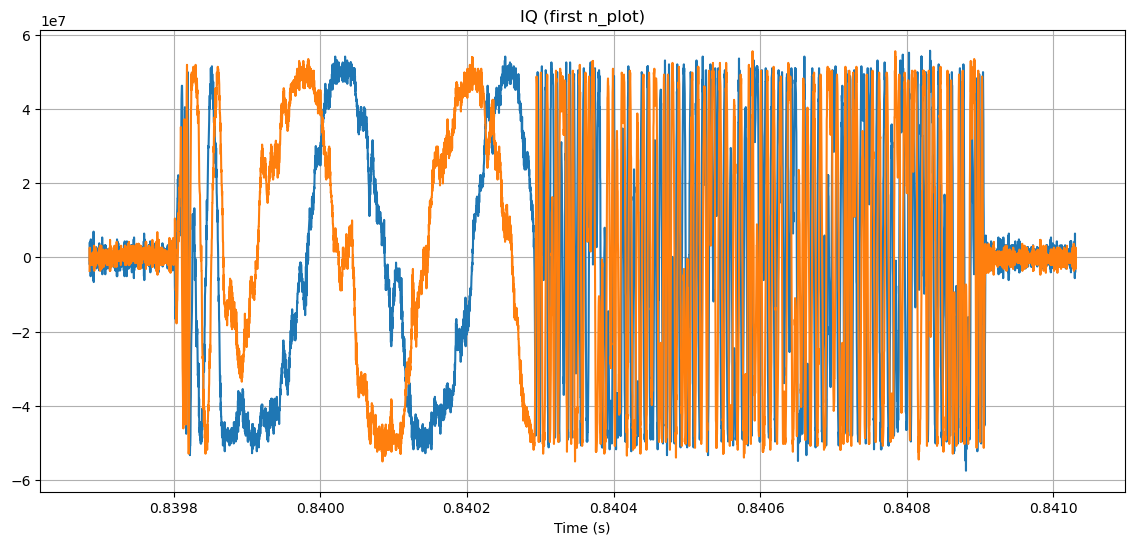

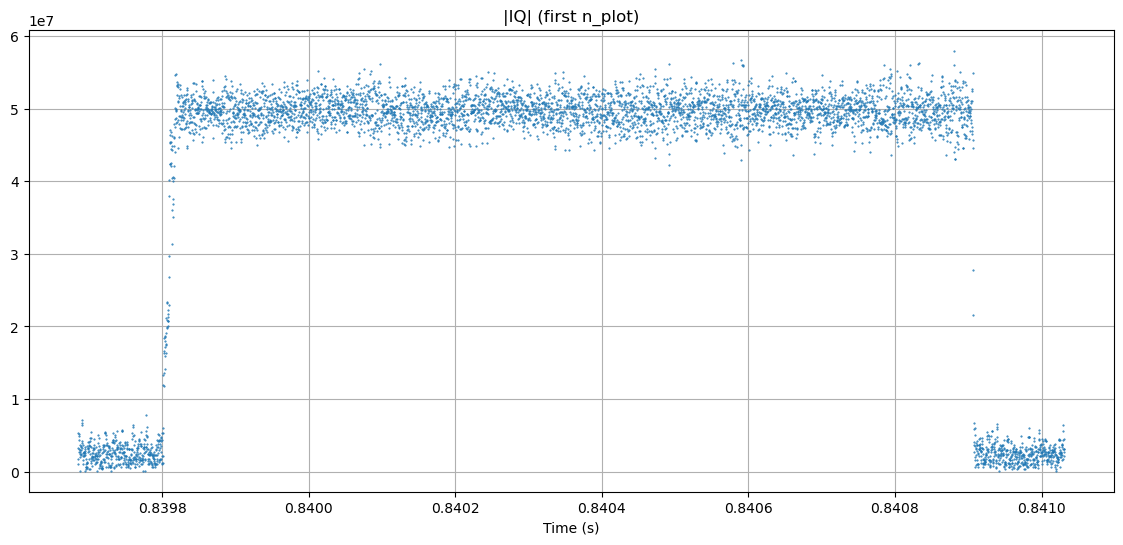

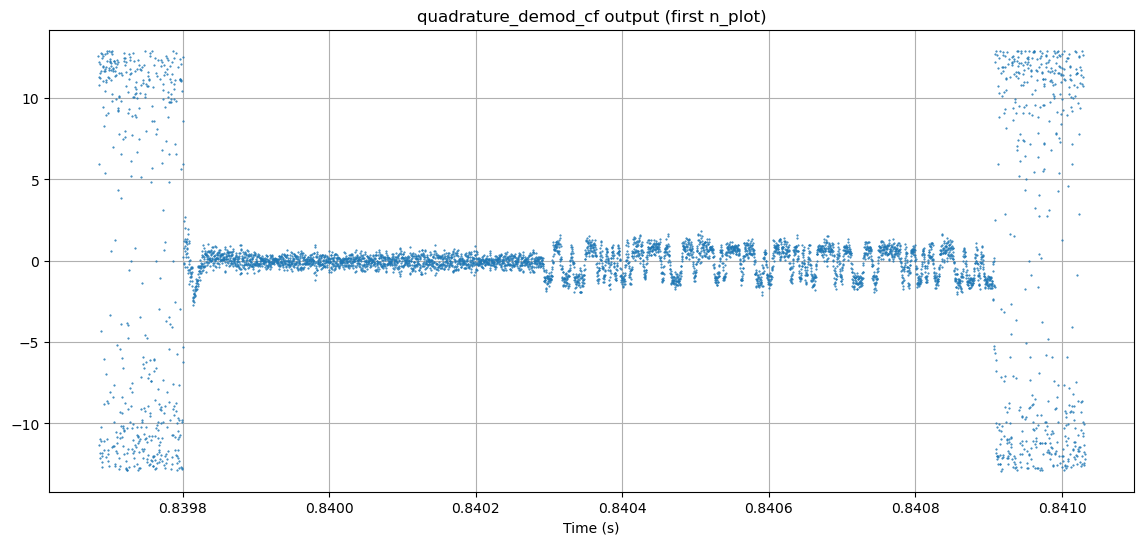

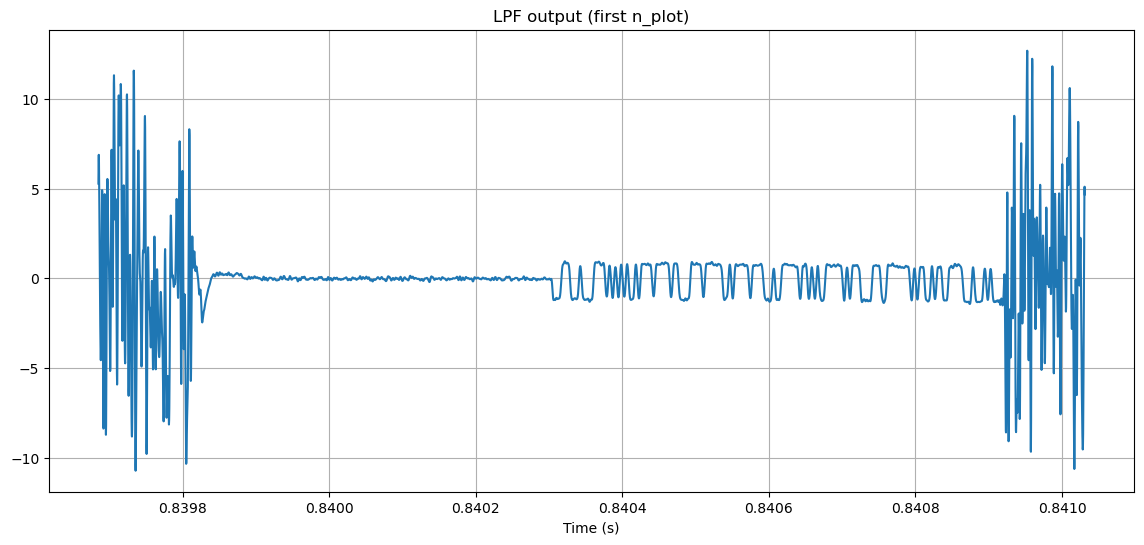

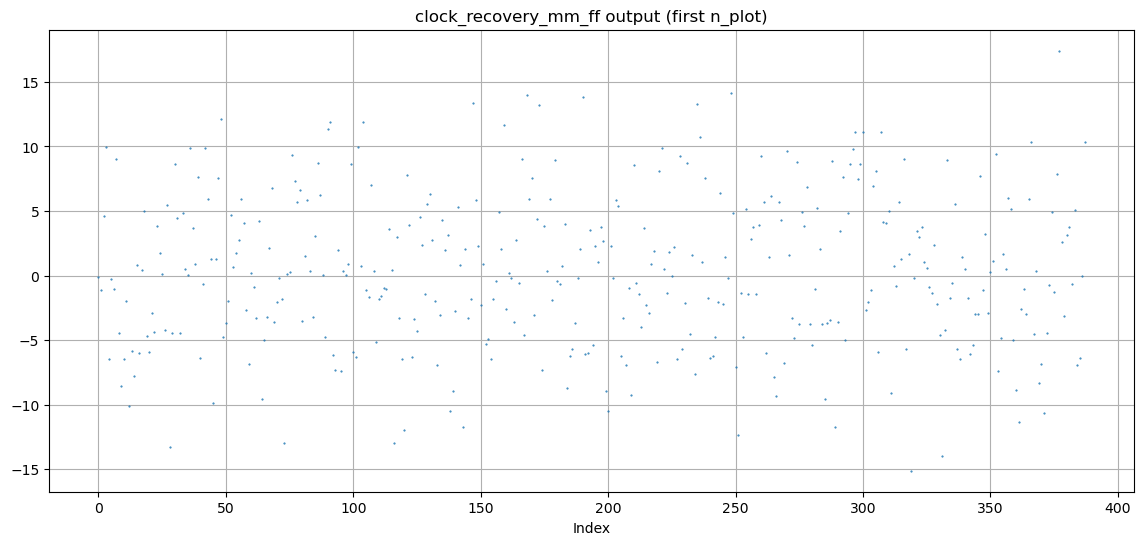

In [71]:
burst_idx = 0

fig_size = (14, 6)
marker_size = 1
t_iq = np.arange(len(iq)) / samp_rate
t_f  = np.arange(len(disc)) / samp_rate

plt.figure(figsize=fig_size); 
plt.plot(t_iq[bursts[burst_idx][0]:bursts[burst_idx][1]], iq.real[bursts[burst_idx][0]:bursts[burst_idx][1]], markersize=marker_size); 
plt.plot(t_iq[bursts[burst_idx][0]:bursts[burst_idx][1]], iq.imag[bursts[burst_idx][0]:bursts[burst_idx][1]], markersize=marker_size)
plt.title("IQ (first n_plot)"); plt.xlabel("Time (s)"); plt.grid(); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t_iq[bursts[burst_idx][0]:bursts[burst_idx][1]], np.abs(iq)[bursts[burst_idx][0]:bursts[burst_idx][1]], '.', markersize=marker_size)
plt.title("|IQ| (first n_plot)"); plt.xlabel("Time (s)"); plt.grid(); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t_f[bursts[burst_idx][0]:bursts[burst_idx][1]], disc[bursts[burst_idx][0]:bursts[burst_idx][1]], '.', markersize=marker_size)
plt.title("quadrature_demod_cf output (first n_plot)"); plt.xlabel("Time (s)"); plt.grid(); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t_f[bursts[burst_idx][0]:bursts[burst_idx][1]], lpfv[bursts[burst_idx][0]:bursts[burst_idx][1]], markersize=marker_size)
plt.title("LPF output (first n_plot)"); plt.xlabel("Time (s)"); plt.grid(); plt.show()

plt.figure(figsize=fig_size); 
scale_factor = clk.shape[0] / iq.shape[0]
idx_start = int(bursts[burst_idx][0] * scale_factor)
idx_end = int(bursts[burst_idx][1] * scale_factor)
plt.plot(clk[idx_start:idx_end], '.', markersize=marker_size)
plt.title("clock_recovery_mm_ff output (first n_plot)"); plt.xlabel("Index"); plt.grid(); plt.show()

# plt.figure(figsize=fig_size); 
# m = min(500, len(bits)); 
# plt.step(np.arange(m), bits[:m], where="post"); plt.ylim(-0.2, 1.2)
# # plt.title("bits (first 500)"); plt.xlabel("Bit index"); plt.show()

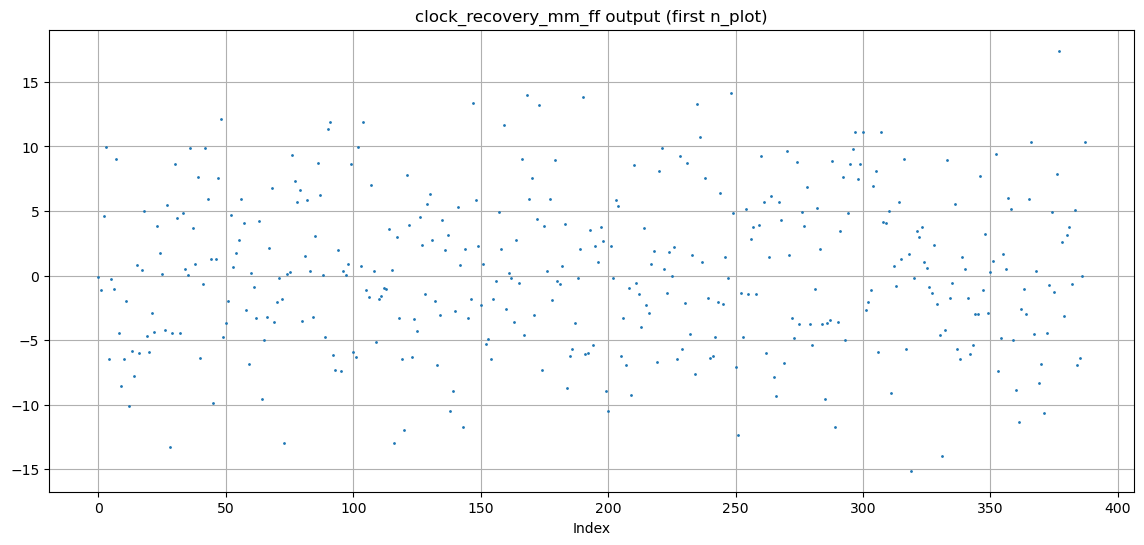

In [79]:

plt.figure(figsize=fig_size); 
scale_factor = clk.shape[0] / iq.shape[0]
idx_start = int(bursts[burst_idx][0] * scale_factor)# + 200
idx_end = int(bursts[burst_idx][1] * scale_factor)
plt.plot(clk[idx_start:idx_end], '.',  markersize=2)
plt.title("clock_recovery_mm_ff output (first n_plot)"); plt.xlabel("Index"); plt.grid(); plt.show()

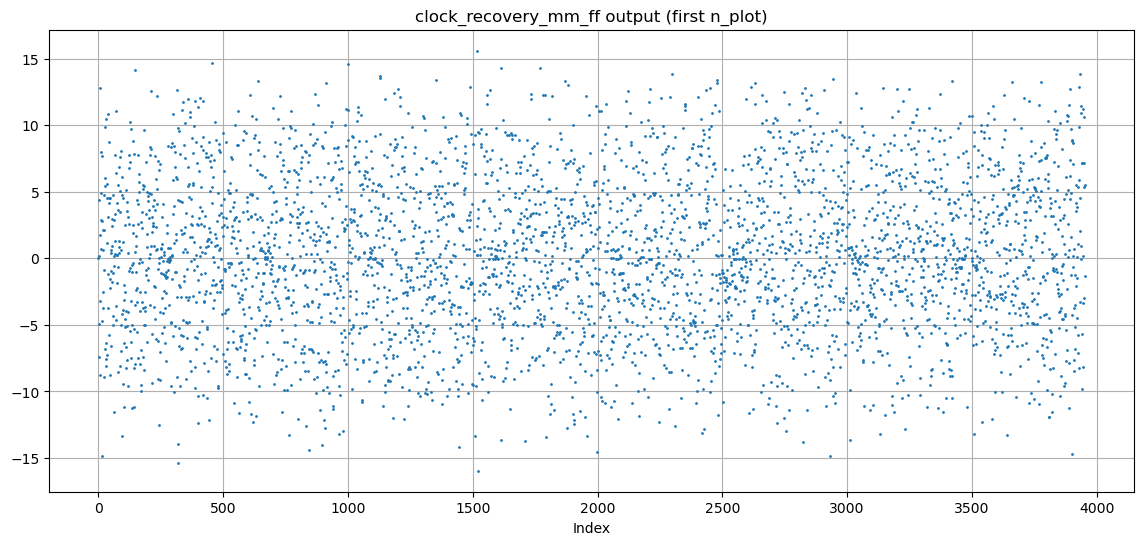

In [84]:
plt.figure(figsize=fig_size); 
scale_factor = clk.shape[0] / iq.shape[0]
idx_start = int(bursts[burst_idx][0] * scale_factor)# + 200
idx_end = int(bursts[burst_idx][1] * scale_factor)
plt.plot(clk[::1000], '.',  markersize=2)
plt.title("clock_recovery_mm_ff output (first n_plot)"); plt.xlabel("Index"); plt.grid(); plt.show()

In [80]:
idx_start

242292

In [81]:
idx_end

242680

In [44]:
iq.shape

(54788096,)

In [45]:
clk.shape

(3897976,)

In [82]:
clk.shape[0] / iq.shape[0]

0.07213780526339152

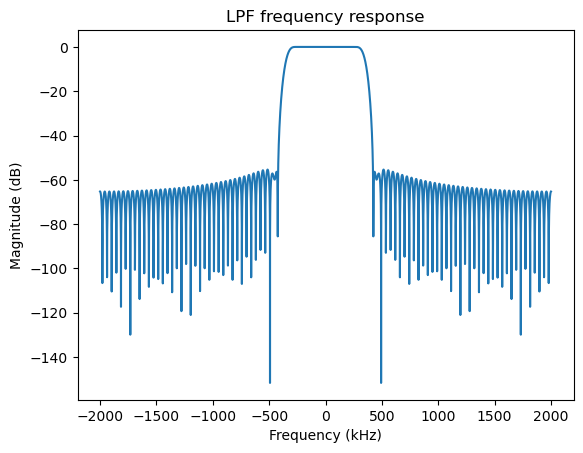

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from gnuradio.filter import firdes

taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
H = np.fft.fftshift(np.abs(np.fft.fft(taps, 8192)))
f = np.linspace(-samp_rate/2, samp_rate/2, len(H))

plt.plot(f/1e3, 20*np.log10(H+1e-12))
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude (dB)")
plt.title("LPF frequency response")
plt.show()


In [81]:
bits.shape

(20000,)

In [76]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
pattern_str = "1110001"
pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(indices)

[]


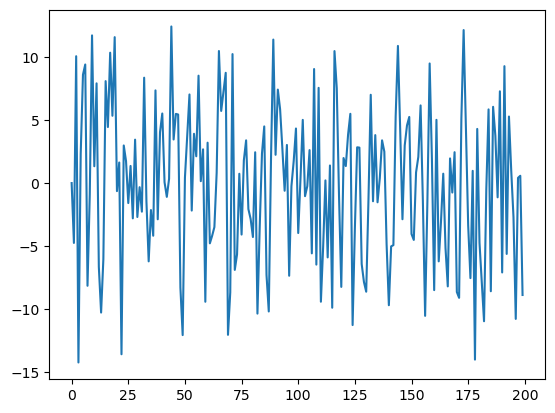

In [100]:
plt.figure()
#plt.plot(lpfv[2500:3000],'.')
plt.plot(lpfv[:30000:100])

# Detect Bursts

File samples (complex): 5518 seconds: 0.0013795
noise_slice percentiles: 0.0023042599204927683 0.0023975179065018892 0.00241446984000504 0.0024154463317245245
open_thr, close_thr: 0.006038615829311311 0.0036217047600075603
pad = 400
Detected bursts: 1
  burst 00: samples 102..5477  (1.34 ms)


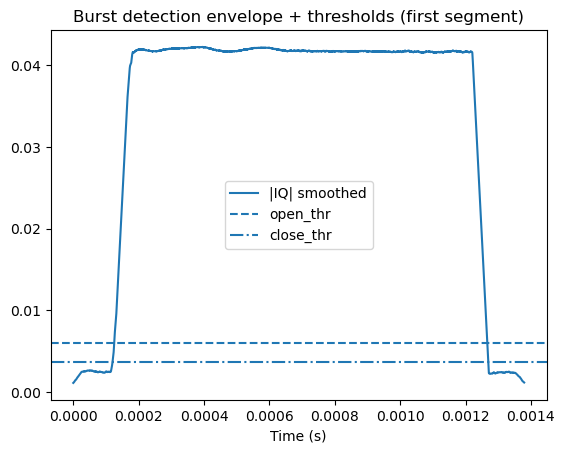

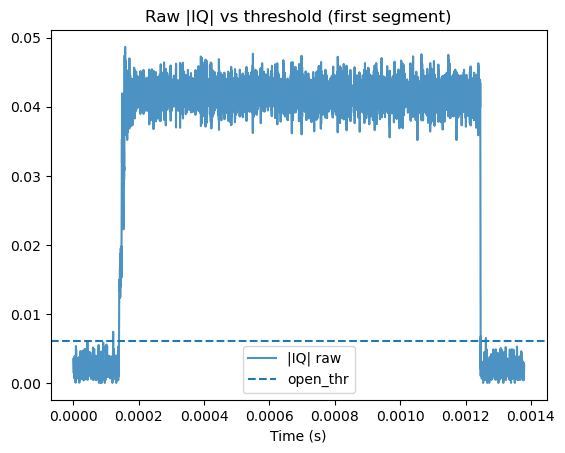

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

iq_file = Path(r"ls-OFF-4M-p6M.complex32s")
#iq_file = Path(r"ls-OFF-4M-p6M-02.complex32s")
fs = 4_000_000

# How much of the file to use to estimate noise floor (seconds)
# noise_est_s = 0.5
# Use bottom fraction of entire mag_s as "noise"
noise_frac = 0.10   # use lowest 10% as noise; try 0.05..0.20

# Smoothing window (seconds) for envelope
smooth_s = 0.00005 #0.0002 #0.0005   # 0.5 ms; try 0.0002..0.002

# Burst constraints
min_burst_ms = 0.5 #1.0  # try 0.5..5.0
pad_ms = 0.1

raw = np.fromfile(iq_file, dtype=np.int16)
i = raw[0::2].astype(np.float32) / 32768.0
q = raw[1::2].astype(np.float32) / 32768.0
x = i + 1j*q
mag = np.abs(x)

print("File samples (complex):", len(x), "seconds:", len(x)/fs)

# Smooth envelope
win = max(1, int(smooth_s * fs))
kernel = np.ones(win, dtype=np.float32) / win
mag_s = np.convolve(mag, kernel, mode="same")


# Noise Floor
# # Estimate noise floor from first noise_est_s seconds (or whole file if shorter)
# n_noise = min(len(mag_s), int(noise_est_s * fs))
# noise_slice = mag_s[:n_noise]

# # Robust stats
# p50 = float(np.percentile(noise_slice, 50))
# p90 = float(np.percentile(noise_slice, 90))
# p99 = float(np.percentile(noise_slice, 99))
# p999 = float(np.percentile(noise_slice, 99.9))

# print(f"Envelope percentiles (first {n_noise/fs:.3f}s): p50={p50:.6g} p90={p90:.6g} p99={p99:.6g} p99.9={p999:.6g}")

# # Auto thresholds with hysteresis:
# # Open above high threshold, close below low threshold.
# # Increase factors if it's too sensitive; reduce if it misses bursts.
# open_thr = max(p999 * 1.5, p99 * 3.0)
# close_thr = max(p99 * 1.2, p90 * 2.0)

# print("Auto thresholds:", "open_thr =", open_thr, "close_thr =", close_thr)


# Use bottom fraction of entire mag_s as "noise"
noise_frac = 0.10   # use lowest 10% as noise; try 0.05..0.20

k = max(1, int(noise_frac * len(mag_s)))
noise_slice = np.partition(mag_s, k)[:k]

p50  = float(np.percentile(noise_slice, 50))
p90  = float(np.percentile(noise_slice, 90))
p99  = float(np.percentile(noise_slice, 99))
p999 = float(np.percentile(noise_slice, 99.9))

print("noise_slice percentiles:", p50, p90, p99, p999)

# Much safer hysteresis thresholds
open_thr  = p999 * 2.5
close_thr = p99  * 1.5
print("open_thr, close_thr:", open_thr, close_thr)


# Hysteresis state machine
state = 0
starts = []
ends = []

for n, v in enumerate(mag_s):
    if state == 0:
        if v >= open_thr:
            state = 1
            starts.append(n)
    else:
        if v <= close_thr:
            state = 0
            ends.append(n)

if state == 1:
    ends.append(len(mag_s)-1)

# Merge/validate bursts
min_len = int((min_burst_ms/1000) * fs)
pad = int((pad_ms/1000) * fs)
print("pad =", pad)

bursts = []
for s, e in zip(starts, ends):
    if e - s + 1 >= min_len:
        s2 = max(0, s - pad)
        e2 = min(len(mag_s)-1, e + pad)
        bursts.append((s2, e2))

print("Detected bursts:", len(bursts))
for k, (s,e) in enumerate(bursts[:20]):
    dur_ms = (e - s + 1) * 1000 / fs
    print(f"  burst {k:02d}: samples {s}..{e}  ({dur_ms:.2f} ms)")

# Plot a zoomed segment to validate visually
# Show first 200 ms (adjust if needed)
show_s = 0.2
N = min(len(mag_s), int(show_s * fs))
t = np.arange(N) / fs

plt.figure()
plt.plot(t, mag_s[:N], label="|IQ| smoothed")
plt.axhline(open_thr, linestyle="--", label="open_thr")
plt.axhline(close_thr, linestyle="-.", label="close_thr")
plt.xlabel("Time (s)")
plt.title("Burst detection envelope + thresholds (first segment)")
plt.legend()
plt.show()

# If you want, also plot raw |IQ| (unsmoothed) for the same window
plt.figure()
plt.plot(t, mag[:N], label="|IQ| raw", alpha=0.8)
plt.axhline(open_thr, linestyle="--", label="open_thr")
plt.xlabel("Time (s)")
plt.title("Raw |IQ| vs threshold (first segment)")
plt.legend()
plt.show()


In [65]:
# Estimate noise floor from first noise_est_s seconds (or whole file if shorter)
n_noise = min(len(mag_s), int(noise_est_s * fs))
noise_slice = mag_s[:n_noise]

# Robust stats
p50 = float(np.percentile(noise_slice, 50))
p90 = float(np.percentile(noise_slice, 90))
p99 = float(np.percentile(noise_slice, 99))
p999 = float(np.percentile(noise_slice, 99.9))

pctl=  [0.001166375121101737, 0.0020716102897293037, 0.002108626196988755, 0.002134322887286544, 0.0021660184591180747, 0.002203321498301294, 0.0022347438304374614, 0.002275539898417062, 0.0023392537712223, 0.00249152397736907]


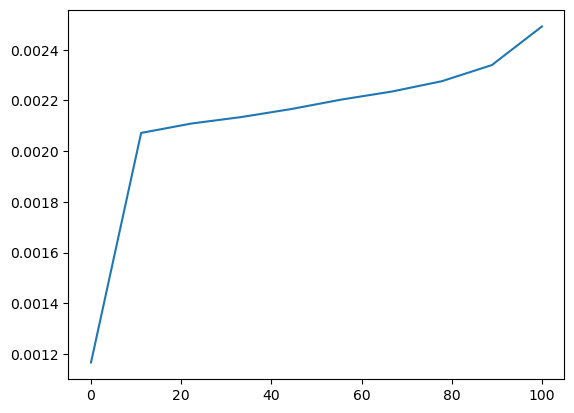

In [66]:
lspc = np.linspace(0,100,10)
pctl = []
for v in lspc:
    pctl.append(float(np.percentile(noise_slice, v)))

plt.plot(lspc, pctl)
print('pctl= ', pctl)

In [51]:
np.percentile(noise_slice, 5)

np.float32(0.0023597877)

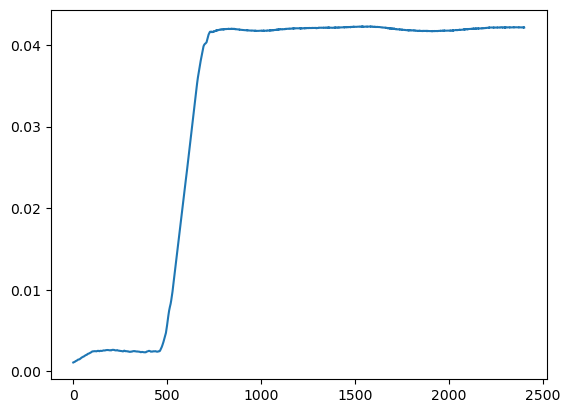

In [48]:
plt.plot(noise_slice)

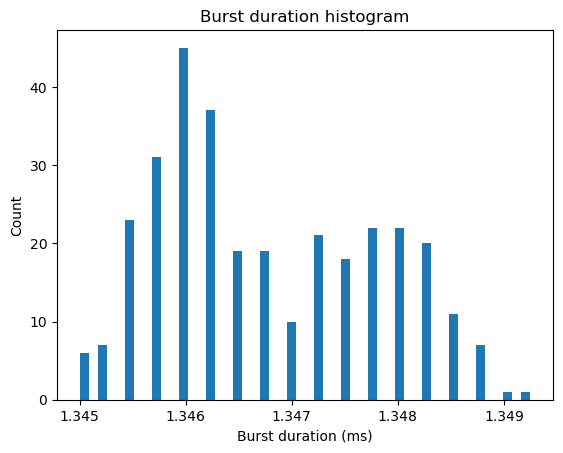

Duration ms: min 1.345 median 1.3465 max 1.34925


In [82]:
durs_ms = np.array([(e - s + 1) * 1000 / fs for s,e in bursts])
plt.figure()
plt.hist(durs_ms, bins=50)
plt.xlabel("Burst duration (ms)")
plt.ylabel("Count")
plt.title("Burst duration histogram")
plt.show()

print("Duration ms: min", durs_ms.min(), "median", np.median(durs_ms), "max", durs_ms.max())


In [83]:
bursts[40]

(8493604, 8498989)

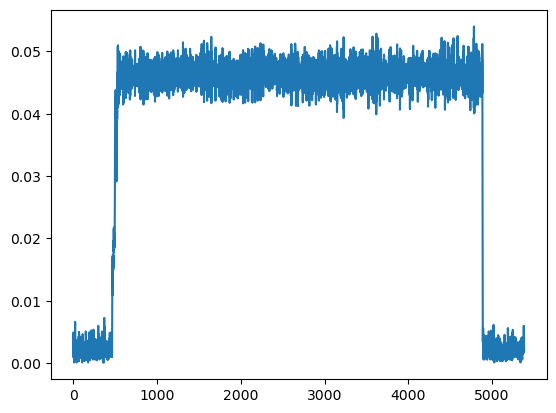

In [84]:
burst_idx = 0
plt.plot(mag[bursts[burst_idx][0]:bursts[burst_idx][1]])

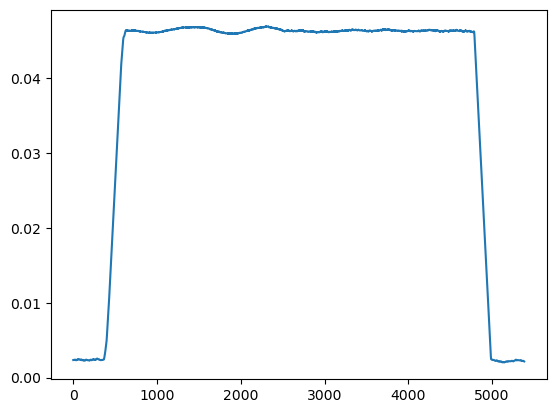

In [85]:
# burst_idx = 2
plt.plot(mag_s[bursts[burst_idx][0]:bursts[burst_idx][1]])

In [71]:
bursts[1]

(3374523, 3384596)

In [ ]:
plt.plot(mag

In [107]:
len(bursts)

320

In [116]:
import numpy as np
from pathlib import Path

# -----------------------------
# SETTINGS
# -----------------------------
bits_dir = Path(r"bursts_out")   # folder containing burst_###.bits
glob_pat = "burst_*.bits"        # adjust if different extension
pattern_str = "11100010000111101010101001011110111110"  # <-- your pattern
#pattern_str = "11100010000111101010101" 
check_inverted = True            # also check inverted bits (0<->1)
# -----------------------------

def load_bits_file(path: Path) -> np.ndarray:
    # Your .bits are written as bytes 0x00 or 0x01
    arr = np.fromfile(path, dtype=np.uint8)
    # normalize just in case some files contain other values (safety)
    arr = (arr != 0).astype(np.uint8)
    return arr

def find_pattern_indices(arr: np.ndarray, pattern_bits: np.ndarray) -> np.ndarray:
    m = len(pattern_bits)
    if arr.size < m:
        return np.array([], dtype=np.int64)

    windows = np.lib.stride_tricks.sliding_window_view(arr, m)
    matches = np.all(windows == pattern_bits, axis=1)
    return np.where(matches)[0]

pattern = np.array(list(pattern_str), dtype=np.uint8)
pattern = (pattern != 0).astype(np.uint8)
pattern_inv = (1 - pattern).astype(np.uint8)

files = sorted(bits_dir.glob(glob_pat))
print("Files found:", len(files))

hits = []
hits_inv = []

for f in files:
    arr = load_bits_file(f)

    idx = find_pattern_indices(arr, pattern)
    if idx.size:
        hits.append((f.name, idx))
        print(f"[MATCH] {f.name}: {idx}")

    if check_inverted:
        idx2 = find_pattern_indices(arr, pattern_inv)
        if idx2.size:
            hits_inv.append((f.name, idx2))
            print(f"[MATCH inverted] {f.name}: {idx2}")

print("\nSummary:")
print("Matches:", len(hits))
if check_inverted:
    print("Inverted matches:", len(hits_inv))


Files found: 320
[MATCH] burst_023.bits: [305]
[MATCH] burst_032.bits: [308]
[MATCH] burst_073.bits: [304]
[MATCH] burst_101.bits: [299]
[MATCH] burst_121.bits: [301]
[MATCH] burst_127.bits: [299]
[MATCH] burst_141.bits: [299]
[MATCH] burst_157.bits: [305]
[MATCH] burst_196.bits: [306]
[MATCH] burst_197.bits: [306]
[MATCH] burst_211.bits: [302]
[MATCH] burst_214.bits: [299]
[MATCH] burst_238.bits: [300]
[MATCH] burst_249.bits: [297]
[MATCH] burst_260.bits: [302]
[MATCH] burst_274.bits: [302]
[MATCH] burst_287.bits: [298]
[MATCH] burst_305.bits: [304]

Summary:
Matches: 18
Inverted matches: 0


File complex samples: 54788096 seconds: 13.697024
Envelope percentiles (first 0.500s): p50=0.00224761 p90=0.00230779 p99=0.00235562 p99.9=0.00239304
Auto thresholds: open_thr = 0.007066858001053333 close_thr = 0.004615576937794685
Detected bursts: 320
  burst 000: samples 3356447..3366523  (2.52 ms)
  burst 001: samples 3374523..3384596  (2.52 ms)
  burst 002: samples 3392595..3402673  (2.52 ms)
  burst 003: samples 3410667..3420746  (2.52 ms)
  burst 004: samples 3428763..3438845  (2.52 ms)
  burst 005: samples 3446833..3456919  (2.52 ms)
  burst 006: samples 3464906..3474997  (2.52 ms)
  burst 007: samples 3482980..3493076  (2.52 ms)
  burst 008: samples 3501051..3511165  (2.53 ms)
  burst 009: samples 3519123..3529245  (2.53 ms)
  burst 010: samples 3537201..3547325  (2.53 ms)
  burst 011: samples 3555275..3565402  (2.53 ms)
  burst 012: samples 3573353..3583488  (2.53 ms)
  burst 013: samples 3591425..3601566  (2.54 ms)
  burst 014: samples 3609504..3619642  (2.53 ms)
  burst 015: 

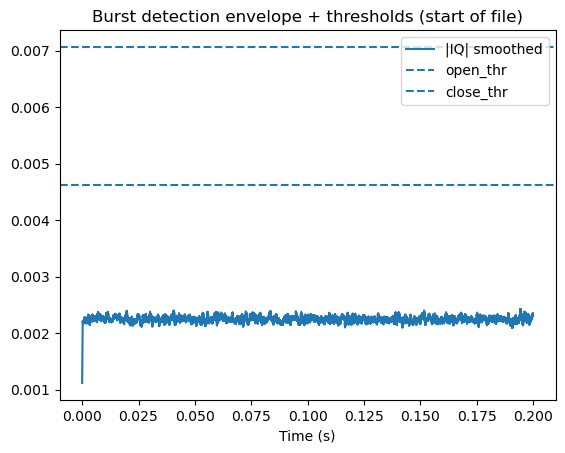

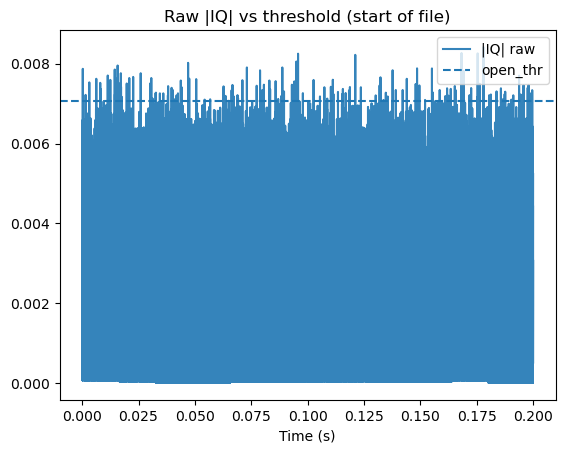

Decoding bursts: 320 (out of 320) into bursts_out
Done.
Burst IQ files: bursts_out/burst_000.iq ...
Burst bit files: bursts_out/burst_000.bits ...


In [117]:
# FULL NOTEBOOK CODE (single cell):
# 1) Detect bursts in a long int16 interleaved IQ file (I0,Q0,I1,Q1,...) at 4 MS/s
# 2) For each detected burst, write a burst IQ file and decode it with GNU Radio
# 3) Save per-burst bit outputs so you can later search for patterns yourself

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# USER SETTINGS
# -----------------------------
iq_file = Path(r"ls-OFF-4M-p6M-02.complex32s")  # long file: int16 interleaved I,Q
fs = 4_000_000

# Burst detection
noise_est_s   = 0.5       # seconds used for noise floor estimate (from beginning)
smooth_s      = 0.0005    # envelope smoothing (seconds). try 0.0001..0.002
min_burst_ms  = 1.0       # minimum burst duration (ms)
pad_ms        = 0.5       # pad before/after each burst (ms)
show_s        = 0.2       # seconds to plot at start (for sanity)

# Decoder parameters (match what you already use)
samples_per_symbol = 16
quad_gain = 4.11

# LPF (deviation-friendly)
lpf_cutoff_hz = 350_000   # try 250k, 350k, 450k
lpf_trans_hz  = 100_000

# Output folder
out_dir = iq_file.parent / "bursts_out"
out_dir.mkdir(exist_ok=True)

# Whether to write unpacked bits (one byte per bit: 0/1) OR packed (8 bits per byte)
write_packed_bits = False  # set True if you want packed bytes
packed_order = "LSB"       # "LSB" or "MSB" if packing

# Limit number of bursts to decode (None = all)
max_bursts_to_decode = None
# -----------------------------


# ============================================================
# 1) LOAD IQ (int16 interleaved) + DETECT BURSTS
# ============================================================
raw = np.fromfile(iq_file, dtype=np.int16)
if raw.size % 2 != 0:
    raise RuntimeError("File length not divisible by 2 int16 values; not interleaved IQ?")

i = raw[0::2].astype(np.float32) / 32768.0
q = raw[1::2].astype(np.float32) / 32768.0
x = i + 1j*q
mag = np.abs(x)

print("File complex samples:", len(x), "seconds:", len(x)/fs)

# Smooth envelope
win = max(1, int(smooth_s * fs))
kernel = np.ones(win, dtype=np.float32) / win
mag_s = np.convolve(mag, kernel, mode="same")

# Noise floor estimate from first noise_est_s seconds
n_noise = min(len(mag_s), int(noise_est_s * fs))
noise_slice = mag_s[:n_noise]

p50  = float(np.percentile(noise_slice, 50))
p90  = float(np.percentile(noise_slice, 90))
p99  = float(np.percentile(noise_slice, 99))
p999 = float(np.percentile(noise_slice, 99.9))

print(f"Envelope percentiles (first {n_noise/fs:.3f}s): p50={p50:.6g} p90={p90:.6g} p99={p99:.6g} p99.9={p999:.6g}")

# Auto hysteresis thresholds (works well in practice; tweak if needed)
open_thr  = max(p999 * 1.5, p99 * 3.0)
close_thr = max(p99  * 1.2, p90 * 2.0)
print("Auto thresholds:", "open_thr =", open_thr, "close_thr =", close_thr)

# Hysteresis state machine
state = 0
starts, ends = [], []
for n, v in enumerate(mag_s):
    if state == 0:
        if v >= open_thr:
            state = 1
            starts.append(n)
    else:
        if v <= close_thr:
            state = 0
            ends.append(n)
if state == 1:
    ends.append(len(mag_s)-1)

min_len = int((min_burst_ms/1000) * fs)
pad = int((pad_ms/1000) * fs)

bursts = []
for s, e in zip(starts, ends):
    if (e - s + 1) >= min_len:
        s2 = max(0, s - pad)
        e2 = min(len(mag_s)-1, e + pad)
        bursts.append((s2, e2))

print("Detected bursts:", len(bursts))
for k, (s,e) in enumerate(bursts[:20]):
    dur_ms = (e - s + 1) * 1000 / fs
    print(f"  burst {k:03d}: samples {s}..{e}  ({dur_ms:.2f} ms)")

# Quick sanity plots at start of file
N = min(len(mag_s), int(show_s * fs))
t = np.arange(N) / fs

plt.figure()
plt.plot(t, mag_s[:N], label="|IQ| smoothed")
plt.axhline(open_thr, linestyle="--", label="open_thr")
plt.axhline(close_thr, linestyle="--", label="close_thr")
plt.xlabel("Time (s)")
plt.title("Burst detection envelope + thresholds (start of file)")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, mag[:N], label="|IQ| raw", alpha=0.9)
plt.axhline(open_thr, linestyle="--", label="open_thr")
plt.xlabel("Time (s)")
plt.title("Raw |IQ| vs threshold (start of file)")
plt.legend()
plt.show()


# ============================================================
# 2) GNU RADIO BURST DECODER (per burst)
#    Reads burst IQ file (int16 interleaved) -> writes bits file
# ============================================================
from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes
import numpy as np

try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find WIN_HAMMING in this GNU Radio build.")

def decode_burst_iq_to_bits(in_iq_path, out_bits_path,
                           fs=4_000_000,
                           samples_per_symbol=16,
                           quad_gain=4.11,
                           lpf_cutoff_hz=350_000,
                           lpf_trans_hz=100_000):
    tb = gr.top_block()

    # int16 interleaved IQ -> complex
    src = blocks.file_source(gr.sizeof_short, str(in_iq_path), False)
    deint = blocks.deinterleave(gr.sizeof_short)
    i_f = blocks.short_to_float(1, 1.0/32768.0)
    q_f = blocks.short_to_float(1, 1.0/32768.0)
    iq_c = blocks.float_to_complex(1)

    demod = analog.quadrature_demod_cf(float(quad_gain))

    # DC removal (fallback for builds without dc_blocker_ff)
    dc_ma = blocks.moving_average_ff(64, 1.0/64.0, 4000)
    dc_sub = blocks.sub_ff()

    # LPF on discriminator output
    lpf_taps = firdes.low_pass(1.0, fs, lpf_cutoff_hz, lpf_trans_hz, WIN)
    lpf = filter.fir_filter_fff(1, lpf_taps)

    # --- PFB clock sync (more robust than MM for bursts) ---
    sps = float(samples_per_symbol)
    loop_bw = 0.0628            # start value (from your screenshot-ish range)
    filter_size = 32            # typical
    init_phase = filter_size//2
    max_rate_dev = 1.5
    output_sps = 1

    # RRC taps for the clock sync filterbank
    rrc_taps = firdes.root_raised_cosine(
        gain=1.0,
        sampling_freq=fs,
        symbol_rate=fs/sps,
        alpha=0.35,
        ntaps=int(11*sps)        # typical length
    )

    clk = digital.pfb_clock_sync_fff(sps, loop_bw, rrc_taps,
                                     filter_size, init_phase,
                                     max_rate_dev, output_sps)

    slicer = digital.binary_slicer_fb()
    sink = blocks.file_sink(gr.sizeof_char, str(out_bits_path), False)

    # connect
    tb.connect(src, deint)
    tb.connect((deint, 0), i_f); tb.connect((deint, 1), q_f)
    tb.connect(i_f, (iq_c, 0));  tb.connect(q_f, (iq_c, 1))

    tb.connect(iq_c, demod)

    tb.connect(demod, (dc_sub, 0))
    tb.connect(demod, dc_ma)
    tb.connect(dc_ma, (dc_sub, 1))

    tb.connect(dc_sub, lpf, clk, slicer, sink)

    tb.run()


# ============================================================
# 3) WRITE BURST IQ FILES + DECODE EACH BURST
# ============================================================
to_decode = bursts
if max_bursts_to_decode is not None:
    to_decode = to_decode[:max_bursts_to_decode]

print(f"Decoding bursts: {len(to_decode)} (out of {len(bursts)}) into {out_dir}")

for bi, (s, e) in enumerate(to_decode):
    burst_iq = out_dir / f"burst_{bi:03d}.iq"
    burst_bits = out_dir / (f"burst_{bi:03d}.bits_packed" if write_packed_bits else f"burst_{bi:03d}.bits")

    # slice raw int16 words: 2 int16 per complex sample
    s_words = s * 2
    e_words = (e + 1) * 2
    raw[s_words:e_words].tofile(burst_iq)

    decode_burst_iq_to_bits(burst_iq, burst_bits)

print("Done.")
print("Burst IQ files:", out_dir / "burst_000.iq", "...")
print("Burst bit files:", out_dir / ("burst_000.bits_packed" if write_packed_bits else "burst_000.bits"), "...")


In [118]:
import numpy as np
from pathlib import Path

# -----------------------------
# SETTINGS
# -----------------------------
bits_dir = Path(r"bursts_out")   # folder containing burst_###.bits
glob_pat = "burst_*.bits"        # adjust if different extension
pattern_str = "11100010000111101010101001011110111110"  # <-- your pattern
#pattern_str = "11100010000111101010101" 
check_inverted = True            # also check inverted bits (0<->1)
# -----------------------------

def load_bits_file(path: Path) -> np.ndarray:
    # Your .bits are written as bytes 0x00 or 0x01
    arr = np.fromfile(path, dtype=np.uint8)
    # normalize just in case some files contain other values (safety)
    arr = (arr != 0).astype(np.uint8)
    return arr

def find_pattern_indices(arr: np.ndarray, pattern_bits: np.ndarray) -> np.ndarray:
    m = len(pattern_bits)
    if arr.size < m:
        return np.array([], dtype=np.int64)

    windows = np.lib.stride_tricks.sliding_window_view(arr, m)
    matches = np.all(windows == pattern_bits, axis=1)
    return np.where(matches)[0]

pattern = np.array(list(pattern_str), dtype=np.uint8)
pattern = (pattern != 0).astype(np.uint8)
pattern_inv = (1 - pattern).astype(np.uint8)

files = sorted(bits_dir.glob(glob_pat))
print("Files found:", len(files))

hits = []
hits_inv = []

for f in files:
    arr = load_bits_file(f)

    idx = find_pattern_indices(arr, pattern)
    if idx.size:
        hits.append((f.name, idx))
        print(f"[MATCH] {f.name}: {idx}")

    if check_inverted:
        idx2 = find_pattern_indices(arr, pattern_inv)
        if idx2.size:
            hits_inv.append((f.name, idx2))
            print(f"[MATCH inverted] {f.name}: {idx2}")

print("\nSummary:")
print("Matches:", len(hits))
if check_inverted:
    print("Inverted matches:", len(hits_inv))


Files found: 320
[MATCH] burst_002.bits: [304]
[MATCH inverted] burst_133.bits: [303]
[MATCH] burst_145.bits: [303]
[MATCH] burst_150.bits: [306]
[MATCH] burst_158.bits: [305]
[MATCH] burst_183.bits: [307]
[MATCH] burst_211.bits: [301]
[MATCH] burst_240.bits: [302]
[MATCH] burst_254.bits: [302]
[MATCH] burst_294.bits: [301]
[MATCH] burst_308.bits: [304]
[MATCH] burst_318.bits: [306]

Summary:
Matches: 11
Inverted matches: 1


In [119]:
import numpy as np
from pathlib import Path

from gnuradio import gr, blocks, analog, filter
from gnuradio.filter import firdes

# -----------------------------
# SETTINGS
# -----------------------------
bursts_dir = Path("bursts_out")          # contains burst_###.iq (int16 interleaved IQ)
out_dir = Path("bursts_out_decoded")     # will write burst_###.bits_best here
out_dir.mkdir(exist_ok=True)

fs = 4_000_000
sps = 16                      # samples per symbol (what you used in URH)
quad_gain = 4.11              # your computed gain
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

pattern_str = "11100010000111101010101001011110111110"  # your pattern
pattern = np.array(list(pattern_str), dtype=np.uint8)

# How many bits to search within each burst (cap for speed). Set None to search all.
max_search_bits = None

# Use averaging over each symbol window (more robust than single-sample)
use_symbol_average = True
# -----------------------------

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find WIN_HAMMING in this GNU Radio build.")


def gnuradio_demod_to_float(in_iq_path: Path) -> np.ndarray:
    """int16 interleaved IQ -> discriminator float array (no clock recovery)."""
    tb = gr.top_block()

    src = blocks.file_source(gr.sizeof_short, str(in_iq_path), False)
    deint = blocks.deinterleave(gr.sizeof_short)
    i_f = blocks.short_to_float(1, 1.0/32768.0)
    q_f = blocks.short_to_float(1, 1.0/32768.0)
    iq_c = blocks.float_to_complex(1)

    demod = analog.quadrature_demod_cf(float(quad_gain))

    # DC removal replacement: x - moving average(x)
    dc_ma = blocks.moving_average_ff(64, 1.0/64.0, 4000)
    dc_sub = blocks.sub_ff()

    lpf_taps = firdes.low_pass(1.0, fs, lpf_cutoff_hz, lpf_trans_hz, WIN)
    lpf = filter.fir_filter_fff(1, lpf_taps)

    vs = blocks.vector_sink_f()

    tb.connect(src, deint)
    tb.connect((deint, 0), i_f); tb.connect((deint, 1), q_f)
    tb.connect(i_f, (iq_c, 0));  tb.connect(q_f, (iq_c, 1))

    tb.connect(iq_c, demod)
    tb.connect(demod, (dc_sub, 0))
    tb.connect(demod, dc_ma)
    tb.connect(dc_ma, (dc_sub, 1))

    tb.connect(dc_sub, lpf, vs)

    tb.run()
    return np.asarray(vs.data(), dtype=np.float32)


def downsample_to_bits(disc: np.ndarray, phase: int, sps: int, avg: bool) -> np.ndarray:
    """disc -> 0/1 bits using fixed phase and known sps."""
    disc = disc[phase:]
    n_syms = len(disc) // sps
    if n_syms <= 0:
        return np.array([], dtype=np.uint8)

    disc = disc[:n_syms * sps].reshape(n_syms, sps)
    if avg:
        sym = disc.mean(axis=1)
    else:
        sym = disc[:, sps//2]  # mid-sample

    bits = (sym > 0).astype(np.uint8)
    return bits


def find_pattern_indices(arr: np.ndarray, pat: np.ndarray) -> np.ndarray:
    m = len(pat)
    if arr.size < m:
        return np.array([], dtype=np.int64)
    windows = np.lib.stride_tricks.sliding_window_view(arr, m)
    matches = np.all(windows == pat, axis=1)
    return np.where(matches)[0]


# -----------------------------
# RUN ON ALL BURSTS
# -----------------------------
files = sorted(bursts_dir.glob("burst_*.iq"))
print("Burst IQ files found:", len(files))

hits = []
for f in files:
    disc = gnuradio_demod_to_float(f)

    best = None  # (num_hits, phase, inverted, indices, bits)
    for phase in range(sps):
        bits = downsample_to_bits(disc, phase, sps, use_symbol_average)
        if max_search_bits is not None:
            bits_search = bits[:max_search_bits]
        else:
            bits_search = bits

        idx = find_pattern_indices(bits_search, pattern)
        nh = idx.size
        if nh > 0:
            cand = (nh, phase, False, idx, bits)
            if best is None or cand[0] > best[0]:
                best = cand

        # also try inversion (some decodes invert)
        bits_inv = (1 - bits).astype(np.uint8)
        if max_search_bits is not None:
            bits_inv_search = bits_inv[:max_search_bits]
        else:
            bits_inv_search = bits_inv

        idx2 = find_pattern_indices(bits_inv_search, pattern)
        nh2 = idx2.size
        if nh2 > 0:
            cand2 = (nh2, phase, True, idx2, bits_inv)
            if best is None or cand2[0] > best[0]:
                best = cand2

    if best is not None:
        nh, phase, inv, idx, bits_best = best
        hits.append((f.name, nh, phase, inv, idx[0]))
        out_bits = out_dir / f"{f.stem}.bits_best"
        bits_best.astype(np.uint8).tofile(out_bits)

print("\nHits (burst, count, phase, inverted, first_index):")
for h in hits[:50]:
    print(" ", h)
print("\nTotal bursts with pattern:", len(hits), "out of", len(files))
print("Decoded best-bit files written to:", out_dir)


Burst IQ files found: 320

Hits (burst, count, phase, inverted, first_index):
  ('burst_058.iq', 1, 9, False, np.int64(302))
  ('burst_110.iq', 1, 9, False, np.int64(302))
  ('burst_158.iq', 1, 11, False, np.int64(302))
  ('burst_176.iq', 1, 0, False, np.int64(301))
  ('burst_222.iq', 1, 5, False, np.int64(299))
  ('burst_265.iq', 1, 14, False, np.int64(301))
  ('burst_281.iq', 1, 8, False, np.int64(299))
  ('burst_285.iq', 1, 3, False, np.int64(299))
  ('burst_286.iq', 1, 4, False, np.int64(299))
  ('burst_287.iq', 1, 3, False, np.int64(299))

Total bursts with pattern: 10 out of 320
Decoded best-bit files written to: bursts_out_decoded


In [120]:
# after your hysteresis loop you have starts, ends (these are unpadded)

# Print true durations (no padding)
print("True (unpadded) burst durations, first 20:")
for k, (s,e) in enumerate(list(zip(starts, ends))[:20]):
    dur_ms = (e - s + 1) * 1000 / fs
    print(f"  burst {k:03d}: {dur_ms:.3f} ms")

# Then your padded bursts list (bursts = [(s2,e2), ...]) prints padded durations
print("\nPadded burst durations, first 20:")
for k, (s,e) in enumerate(bursts[:20]):
    dur_ms = (e - s + 1) * 1000 / fs
    print(f"  burst {k:03d}: {dur_ms:.3f} ms")


True (unpadded) burst durations, first 20:
  burst 000: 1.519 ms
  burst 001: 1.518 ms
  burst 002: 1.520 ms
  burst 003: 1.520 ms
  burst 004: 1.521 ms
  burst 005: 1.522 ms
  burst 006: 1.523 ms
  burst 007: 1.524 ms
  burst 008: 1.529 ms
  burst 009: 1.531 ms
  burst 010: 1.531 ms
  burst 011: 1.532 ms
  burst 012: 1.534 ms
  burst 013: 1.536 ms
  burst 014: 1.535 ms
  burst 015: 1.535 ms
  burst 016: 1.536 ms
  burst 017: 1.536 ms
  burst 018: 1.536 ms
  burst 019: 1.537 ms

Padded burst durations, first 20:
  burst 000: 2.519 ms
  burst 001: 2.518 ms
  burst 002: 2.520 ms
  burst 003: 2.520 ms
  burst 004: 2.521 ms
  burst 005: 2.522 ms
  burst 006: 2.523 ms
  burst 007: 2.524 ms
  burst 008: 2.529 ms
  burst 009: 2.531 ms
  burst 010: 2.531 ms
  burst 011: 2.532 ms
  burst 012: 2.534 ms
  burst 013: 2.535 ms
  burst 014: 2.535 ms
  burst 015: 2.535 ms
  burst 016: 2.535 ms
  burst 017: 2.537 ms
  burst 018: 2.536 ms
  burst 019: 2.537 ms


# Burst detection with gnuradio

Captured 95713 complex samples
Total tags captured: 10
'burst' tags captured: 10
tag: offset=7692, key=burst, value=#t, srcid=burst_tagger51
tag: offset=12050, key=burst, value=#f, srcid=burst_tagger51
tag: offset=25767, key=burst, value=#t, srcid=burst_tagger51
tag: offset=30124, key=burst, value=#f, srcid=burst_tagger51
tag: offset=43839, key=burst, value=#t, srcid=burst_tagger51
tag: offset=48199, key=burst, value=#f, srcid=burst_tagger51
tag: offset=61912, key=burst, value=#t, srcid=burst_tagger51
tag: offset=66273, key=burst, value=#f, srcid=burst_tagger51
tag: offset=80010, key=burst, value=#t, srcid=burst_tagger51
tag: offset=84372, key=burst, value=#f, srcid=burst_tagger51


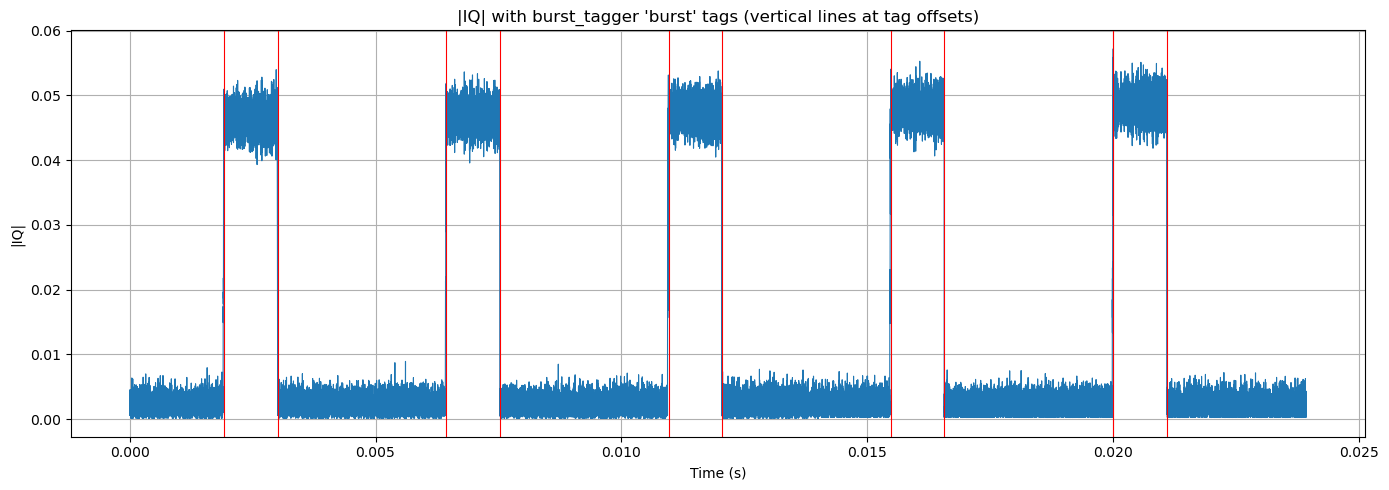

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks

# -----------------------------
# PARAMETERS
# -----------------------------
# iq_file = r"ls-OFF-4M-p6M.complex32s" 
# iq_file = r"ls-OFF-4M-p6M-02.complex32s"  # int16 interleaved I,Q
iq_file = r"ls-OFF-4M-p6M-03.complex32s"
samp_rate = 4_000_000

n_plot = 200_000

# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0

smooth_len = 64  # helps avoid trigger chatter
tag_key = "burst"  # default key name used by burst_tagger docs



tap_ma = blocks.vector_sink_f()


# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tagger_minimal_two_input")

# Source: int16 I,Q  (your starting point)
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0 float

# Convert gate 0/1 -> trigger short +/-1
# map: 0 -> -1, 1 -> +1
#  gatef: 0 or 1
#  gatef - 0.5 -> -0.5 or +0.5
#  *2 -> -1 or +1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Limit capture for plotting + capture tags
head  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink = blocks.vector_sink_c()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger short stream (+/-)

tb.connect(bt, head)
tb.connect(head, vsink)


tb.connect(ma, tap_ma)

tb.run()

# -----------------------------
# Pull samples + tags and plot
# -----------------------------
x = np.array(vsink.data(), dtype=np.complex64)
ma_vals = np.array(tap_ma.data(), dtype=np.float32)


tags = list(vsink.tags())

burst_tags = [t for t in tags if str(t.key) == tag_key]
print(f"Captured {len(x)} complex samples")
print(f"Total tags captured: {len(tags)}")
print(f"'{tag_key}' tags captured: {len(burst_tags)}")
for t in burst_tags[:10]:
    print(f"tag: offset={t.offset}, key={t.key}, value={t.value}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| with burst_tagger 'burst' tags (vertical lines at tag offsets)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")

for tt in burst_tags:
    idx = int(tt.offset)
    if 0 <= idx < len(x):
        plt.axvline(idx / samp_rate, linewidth=0.8, color='red')

plt.grid(True)
plt.tight_layout()
plt.show()


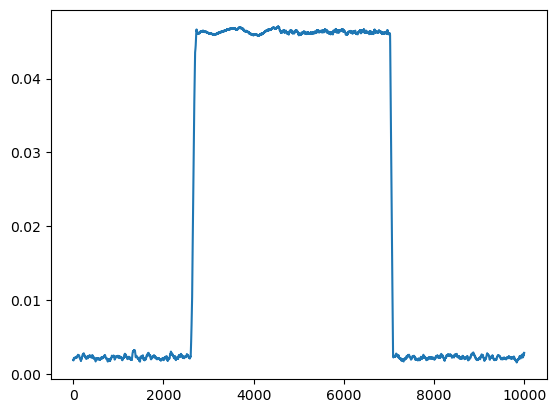

In [10]:
plt.plot(ma_vals[5000:15000])

In [191]:
import pmt

tags = list(vsink.tags())

# Filter only burst tags
burst_tags = [t for t in tags if str(t.key) == "burst"]

bursts = []
start_offset = None

for t in burst_tags:
    if pmt.to_bool(t.value):          # PMT_T → burst start
        start_offset = t.offset
    else:                             # PMT_F → burst end
        if start_offset is not None:
            length = t.offset - start_offset
            bursts.append((start_offset, length))
            start_offset = None

for i, (off, ln) in enumerate(bursts):
    print(f"Burst {i}: start={off}, length={ln} samples")


Burst 0: start=7692, length=4358 samples
Burst 1: start=25767, length=4357 samples
Burst 2: start=43839, length=4360 samples
Burst 3: start=61912, length=4361 samples
Burst 4: start=80010, length=4362 samples


In [192]:
burst_tags[0].offset

7692

In [193]:
# import pprint

# t = burst_tags[0]
# pprint.pp(dir(t))


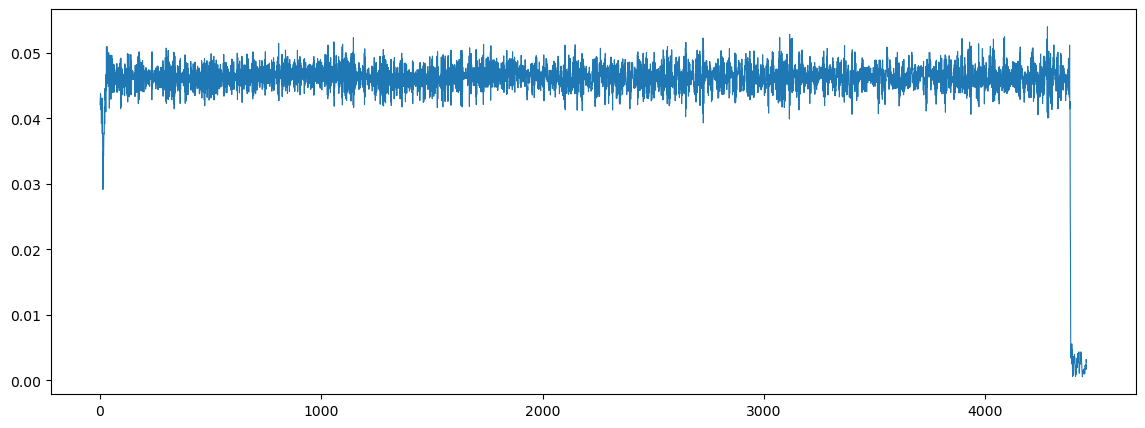

In [199]:
padding = 50
plt.figure(figsize=(14, 5))
plt.plot(np.abs(x)[burst_tags[0].offset-padding:burst_tags[1].offset+padding], linewidth=0.8)

In [2]:
import numpy as np
from gnuradio import gr, blocks, analog

tb = gr.top_block()

iq_file = r"ls-OFF-4M-p6M-02.complex32s"
samp_rate = 4_000_000
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

gate_hi = 0.03
gate_lo = 0.02
gate_initial = 0
smooth_len = 64

# -----------------------------
# Source: int16 I,Q (your starting point)
# -----------------------------
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# -----------------------------
# Magnitude -> smoothed -> gate (0/1 float)
# -----------------------------
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # 0.0 or 1.0 float

# Build trigger short +/-1 for burst_tagger (GR3.7 ctor: burst_tagger(itemsize))
# 0/1 -> -1/+1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# -----------------------------
# Burst tagger (adds tags to IQ stream)
# -----------------------------
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# -----------------------------
# Demod + GATE the discriminator (demod * gate)
# -----------------------------
demod = analog.quadrature_demod_cf(float(quad_gain))
disc_gate = blocks.multiply_ff(1)

# -----------------------------
# Wire it up
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# gate path
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst_tagger tagging IQ
tb.connect(iq_c, (bt, 0))   # stream to tag
tb.connect(f2s,  (bt, 1))   # trigger +/-1 short

# demod the *tagged* IQ (tags propagate downstream)
tb.connect(bt, demod)

# gate discriminator output using the same 0/1 gatef
tb.connect(demod, (disc_gate, 0))
tb.connect(gatef, (disc_gate, 1))

# tb.connect(disc_gate, tap_dg_sink)

# LPF + tap
tb.connect(disc_gate, lpf)
tb.connect(lpf, tap_lpf_sink)

# Clock recovery + tap
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk_sink)

# Bits + taps
tb.connect(clockrec, slicer)
# tb.connect(slicer, tap_bits_sink)
tb.connect(slicer, bits_sink)

tb.run()
print("Done. Wrote ALL decoded bits to:", out_bits_file)

# -----------------------------
# Plot first n_plot samples
# -----------------------------
# def read_c64_all(path):
#     return np.fromfile(path, dtype=np.complex64)

# def read_f32_all(path):
#     return np.fromfile(path, dtype=np.float32)

# def read_u8_all(path):
#     return np.fromfile(path, dtype=np.uint8)

# iq   = read_c64_all(tap_iq_file)
# magv = read_f32_all(tap_mag_file)
# gatev= read_f32_all(tap_gate_file)
# disc = read_f32_all(tap_disc_file)
# dg   = read_f32_all(tap_dg_file)
# # railv= read_f32(tap_rail_file)
# lpfv = read_f32_all(tap_lpf_file)
# clk  = read_f32_all(tap_clk_file)
# bits = read_u8_all(tap_bits_file)

# fig_size = (14, 6)
# marker_size = 1

# t = np.arange(len(disc)) / samp_rate
# t_iq = np.arange(len(iq)) / samp_rate

# plt.figure(figsize=fig_size); 
# plt.plot(t_iq, iq.real, '.', markersize=1); plt.plot(t_iq, iq.imag, '.', markersize=1)
# plt.title("IQ (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

# plt.figure(figsize=fig_size); 
# plt.plot(t, magv, '.', markersize=1); plt.title("|IQ| (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

# plt.figure();  
# plt.plot(t, gatev, '.', markersize=1); plt.title("Gate (0/1) from |IQ|"); plt.xlabel("Time (s)"); plt.show()

# plt.figure(figsize=fig_size); 
# plt.plot(t, disc, '.', markersize=1); plt.title("Disc raw"); plt.xlabel("Time (s)"); plt.show()

# plt.figure(figsize=fig_size); 
# plt.plot(t, dg, markersize=1); plt.title("Disc gated (disc*gate)"); plt.xlabel("Time (s)"); plt.show()
# # plt.figure(); plt.plot(t, railv,'.', markersize=1); plt.title("Disc gated + railed"); plt.xlabel("Time (s)"); plt.show()

# plt.figure(figsize=fig_size); 
# plt.plot(t, lpfv, markersize=1); plt.title("LPF output"); plt.xlabel("Time (s)"); plt.show()

# plt.figure(figsize=fig_size); 
# plt.plot(clk, '.', markersize=2); plt.title("Clock recovery output"); plt.xlabel("Index"); plt.grid(); plt.show()


NameError: name 'lpf' is not defined

In [4]:
import numpy as np
from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-03.complex32s"   # int16 interleaved I,Q
out_bits_file = "out_bits.bin"

samp_rate = 4_000_000
samples_per_symbol = 16

df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

# Gate thresholds on |IQ|
gate_hi = 0.03
gate_lo = 0.02
gate_initial = 0

# Smoothing for envelope detection
smooth_len = 64
ma_delay = (smooth_len - 1) // 2  # group delay (integer samples)


# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("fsk_burst_gate_with_burst_tagger")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# IMPORTANT: short_to_float multiplies by "scale"
# You want int16 -> [-1,1), so scale = 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# Delay IQ so it lines up with moving_average output
iq_del = blocks.delay(gr.sizeof_gr_complex, ma_delay)

# Magnitude -> moving average -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # 0.0 or 1.0

# Trigger for burst_tagger: 0/1 -> -1/+1 short
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# Burst tagger (GR 3.7-style: ctor(itemsize), 2 inputs)
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Demod + gate discriminator
demod = analog.quadrature_demod_cf(float(quad_gain))
disc_gate = blocks.multiply_ff(1)

# LPF
# lpf = filter.fir_filter_fff(1, lpf_taps)

# Clock recovery + slicer
clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)
slicer = digital.binary_slicer_fb()

# Output bits
bits_sink = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# Delay IQ for consistent alignment with MA/gate
tb.connect(iq_c, iq_del)

# Build gate/trigger from the *delayed* IQ (so everything aligns)
tb.connect(iq_del, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst_tagger tags the delayed IQ stream using the trigger
tb.connect(iq_del, (bt, 0))
tb.connect(f2s,   (bt, 1))

# demod tagged IQ (tags propagate)
tb.connect(bt, demod)

# gate discriminator using gatef (aligned)
tb.connect(demod, (disc_gate, 0))
tb.connect(gatef, (disc_gate, 1))

# finish chain
# tb.connect(disc_gate, lpf)
# tb.connect(lpf, clockrec)
tb.connect(disc_gate, clockrec)
tb.connect(clockrec, slicer)
tb.connect(slicer, bits_sink)

tb.run()
print("Done. Wrote ALL decoded bits to:", out_bits_file)


Done. Wrote ALL decoded bits to: out_bits.bin


In [ ]:
# ---- pull data for plotting ----
iq   = np.asarray(tap_iq.data(),   dtype=np.complex64)
disc = np.asarray(tap_disc.data(), dtype=np.float32)
lpfv = np.asarray(tap_lpf.data(),  dtype=np.float32)
clk  = np.asarray(tap_clk.data(),  dtype=np.float32)
bits = np.asarray(tap_bits.data(), dtype=np.uint8)

Done. Wrote decoded bits to: out_bits.bin
Tap files written: tap_iq_complex64.c64 tap_iq_delayed_complex64.c64 tap_mag_float32.f32 tap_env_float32.f32 tap_gate_float32.f32 tap_trigger_int16.s16 tap_demod_float32.f32 tap_demod_gated_float32.f32 tap_clockrec_float32.f32 tap_bits_u8.u8


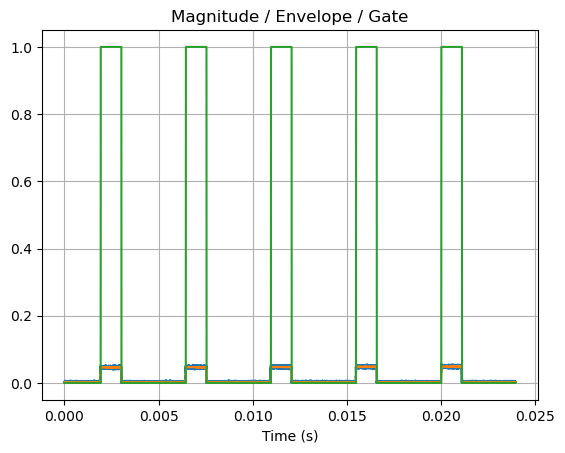

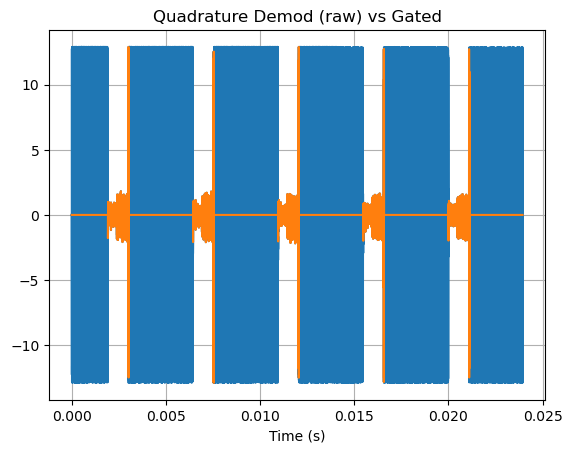

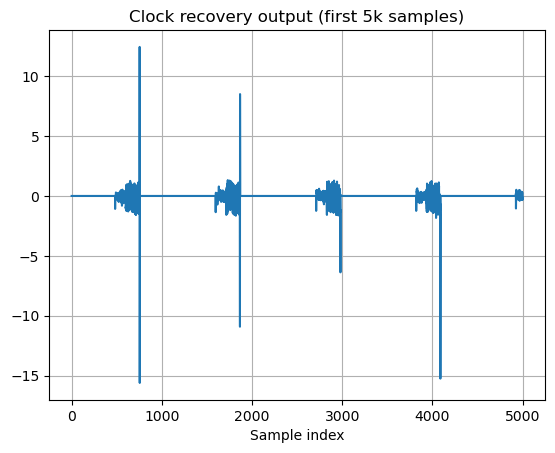

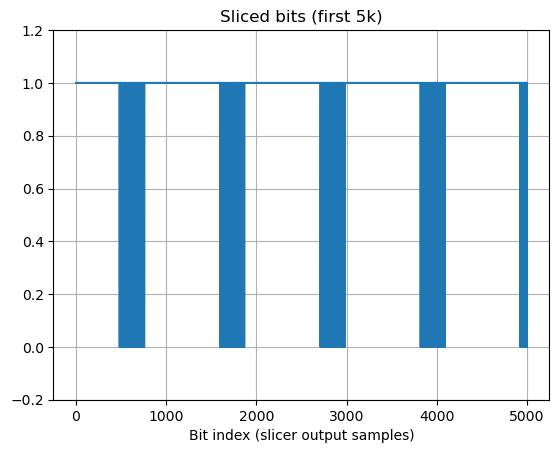

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from gnuradio import gr, blocks, analog, digital

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"
iq_file = r"ls-OFF-4M-p6M-03.complex32s"   # int16 interleaved I,Q
out_bits_file = "out_bits.bin"

samp_rate = 4_000_000
samples_per_symbol = 16

df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

# Gate thresholds on |IQ|
gate_hi = 0.03
gate_lo = 0.02
gate_initial = 0

# Smoothing for envelope detection
smooth_len = 64
ma_delay = (smooth_len - 1) // 2  # group delay (integer samples)

# Tap files (raw streams)
tap_iq_c64          = "tap_iq_complex64.c64"
tap_iq_del_c64      = "tap_iq_delayed_complex64.c64"
tap_mag_f32         = "tap_mag_float32.f32"
tap_env_f32         = "tap_env_float32.f32"
tap_gate_f32        = "tap_gate_float32.f32"
tap_trigger_s16     = "tap_trigger_int16.s16"
tap_demod_f32       = "tap_demod_float32.f32"
tap_demod_gated_f32 = "tap_demod_gated_float32.f32"
tap_clockrec_f32    = "tap_clockrec_float32.f32"
tap_bits_u8         = "tap_bits_u8.u8"

# How much to plot (avoid loading huge files)
PLOT_N = 200_000  # samples


# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("fsk_burst_gate_with_taps")

# --- Source: int16 I,Q (interleaved)
src_iq_i16 = blocks.file_source(gr.sizeof_short, iq_file, False)
split_iq   = blocks.deinterleave(gr.sizeof_short)

# int16 -> float32 in [-1, 1)
i_i16_to_f = blocks.short_to_float(1, 32768.0)
q_i16_to_f = blocks.short_to_float(1, 32768.0)
make_c64   = blocks.float_to_complex(1)

# Align IQ with envelope moving average delay
delay_iq_c64 = blocks.delay(gr.sizeof_gr_complex, ma_delay)

# Envelope detector: |IQ| -> moving average -> hysteresis gate (0/1 float)
iq_to_mag_f32   = blocks.complex_to_mag(1)
env_ma_f32      = blocks.moving_average_ff(smooth_len, 1.0 / smooth_len, 4000)
gate_hyst_f32   = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0/1.0

# Trigger for burst_tagger expects +/- values (short)
gate_minus_half = blocks.add_const_ff(-0.5)
gate_times_two  = blocks.multiply_const_ff(2.0)
gate_to_s16     = blocks.float_to_short(1, 1.0)  # -> -1 or +1 short

# Burst tagger: tags IQ stream using trigger stream
burst_tag_iq = blocks.burst_tagger(gr.sizeof_gr_complex)

# FSK demod + gate discriminator
quad_demod_f32   = analog.quadrature_demod_cf(float(quad_gain))
apply_gate_f32   = blocks.multiply_ff(1)

# Clock recovery + slicer
clockrec_mm_f32 = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)
bit_slicer_u8 = digital.binary_slicer_fb()

# --- Sinks (final + taps)
sink_bits = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

sink_tap_iq_c64          = blocks.file_sink(gr.sizeof_gr_complex, tap_iq_c64, False)
sink_tap_iq_del_c64      = blocks.file_sink(gr.sizeof_gr_complex, tap_iq_del_c64, False)
sink_tap_mag_f32         = blocks.file_sink(gr.sizeof_float,      tap_mag_f32, False)
sink_tap_env_f32         = blocks.file_sink(gr.sizeof_float,      tap_env_f32, False)
sink_tap_gate_f32        = blocks.file_sink(gr.sizeof_float,      tap_gate_f32, False)
sink_tap_trigger_s16     = blocks.file_sink(gr.sizeof_short,      tap_trigger_s16, False)
sink_tap_demod_f32       = blocks.file_sink(gr.sizeof_float,      tap_demod_f32, False)
sink_tap_demod_gated_f32 = blocks.file_sink(gr.sizeof_float,      tap_demod_gated_f32, False)
sink_tap_clockrec_f32    = blocks.file_sink(gr.sizeof_float,      tap_clockrec_f32, False)
sink_tap_bits_u8         = blocks.file_sink(gr.sizeof_char,       tap_bits_u8, False)

# Optional: unbuffered taps can be handy while debugging
for s in [
    sink_tap_iq_c64, sink_tap_iq_del_c64, sink_tap_mag_f32, sink_tap_env_f32,
    sink_tap_gate_f32, sink_tap_trigger_s16, sink_tap_demod_f32,
    sink_tap_demod_gated_f32, sink_tap_clockrec_f32, sink_tap_bits_u8, sink_bits
]:
    try:
        s.set_unbuffered(True)
    except Exception:
        pass

# -----------------------------
# Connections
# -----------------------------
tb.connect(src_iq_i16, split_iq)

tb.connect((split_iq, 0), i_i16_to_f)
tb.connect((split_iq, 1), q_i16_to_f)
tb.connect(i_i16_to_f, (make_c64, 0))
tb.connect(q_i16_to_f, (make_c64, 1))

# Tap: original complex IQ
tb.connect(make_c64, sink_tap_iq_c64)

# Delay IQ to align with moving average envelope
tb.connect(make_c64, delay_iq_c64)

# Tap: delayed IQ
tb.connect(delay_iq_c64, sink_tap_iq_del_c64)

# Envelope from delayed IQ
tb.connect(delay_iq_c64, iq_to_mag_f32)
tb.connect(iq_to_mag_f32, sink_tap_mag_f32)

tb.connect(iq_to_mag_f32, env_ma_f32)
tb.connect(env_ma_f32, sink_tap_env_f32)

tb.connect(env_ma_f32, gate_hyst_f32)
tb.connect(gate_hyst_f32, sink_tap_gate_f32)

# Trigger stream (-1/+1 short)
tb.connect(gate_hyst_f32, gate_minus_half)
tb.connect(gate_minus_half, gate_times_two)
tb.connect(gate_times_two, gate_to_s16)
tb.connect(gate_to_s16, sink_tap_trigger_s16)

# Burst tagger: input0 = IQ, input1 = trigger
tb.connect(delay_iq_c64, (burst_tag_iq, 0))
tb.connect(gate_to_s16,  (burst_tag_iq, 1))

# Demod (tags propagate downstream)
tb.connect(burst_tag_iq, quad_demod_f32)
tb.connect(quad_demod_f32, sink_tap_demod_f32)

# Gate the discriminator using the same aligned gate
tb.connect(quad_demod_f32, (apply_gate_f32, 0))
tb.connect(gate_hyst_f32,  (apply_gate_f32, 1))
tb.connect(apply_gate_f32, sink_tap_demod_gated_f32)

# Clock recovery -> slicer -> sinks
tb.connect(apply_gate_f32, clockrec_mm_f32)
tb.connect(clockrec_mm_f32, sink_tap_clockrec_f32)

tb.connect(clockrec_mm_f32, bit_slicer_u8)
tb.connect(bit_slicer_u8, sink_tap_bits_u8)
tb.connect(bit_slicer_u8, sink_bits)

# -----------------------------
# Run
# -----------------------------
tb.run()
print("Done. Wrote decoded bits to:", out_bits_file)
print("Tap files written:", tap_iq_c64, tap_iq_del_c64, tap_mag_f32, tap_env_f32, tap_gate_f32,
      tap_trigger_s16, tap_demod_f32, tap_demod_gated_f32, tap_clockrec_f32, tap_bits_u8)

# -----------------------------
# Retrieve + plot
# -----------------------------
def read_f32(path, n=None):
    x = np.fromfile(path, dtype=np.float32)
    return x if n is None else x[:n]

def read_c64(path, n=None):
    x = np.fromfile(path, dtype=np.complex64)
    return x if n is None else x[:n]

def read_u8(path, n=None):
    x = np.fromfile(path, dtype=np.uint8)
    return x if n is None else x[:n]

gate = read_f32(tap_gate_f32, PLOT_N)
env  = read_f32(tap_env_f32,  PLOT_N)
mag  = read_f32(tap_mag_f32,  PLOT_N)
dem  = read_f32(tap_demod_f32, PLOT_N)
dmg  = read_f32(tap_demod_gated_f32, PLOT_N)
clk  = read_f32(tap_clockrec_f32, PLOT_N)
bits = read_u8(tap_bits_u8, PLOT_N)

t = np.arange(len(gate)) / samp_rate

plt.figure()
plt.plot(t, mag)
plt.plot(t, env)
plt.plot(t, gate)
plt.title("Magnitude / Envelope / Gate")
plt.xlabel("Time (s)")
plt.grid(True)

plt.figure()
plt.plot(t, dem)
plt.plot(t, dmg)
plt.title("Quadrature Demod (raw) vs Gated")
plt.xlabel("Time (s)")
plt.grid(True)

plt.figure()
plt.plot(clk[:min(len(clk), 5000)])
plt.title("Clock recovery output (first 5k samples)")
plt.xlabel("Sample index")
plt.grid(True)

bits = read_u8(tap_bits_u8, 5000)
plt.figure()
plt.step(np.arange(len(bits)), bits, where="post")
plt.title("Sliced bits (first 5k)")
plt.xlabel("Bit index (slicer output samples)")
plt.ylim(-0.2, 1.2)
plt.grid(True)

plt.show()


In [7]:
bits.shape

(5000,)

In [8]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
pattern_str = "1110001"
pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(indices)

[2831]


In [12]:
t.shape

(95713,)

In [13]:
t_iq.shape

(95713,)

In [14]:
dg.shape

(109767618,)

In [ ]:
plt.plot(dg)

# Gate + LP, Limitedto x Samples. works on short file

Done. Wrote ALL decoded bits to: out_bits.bin


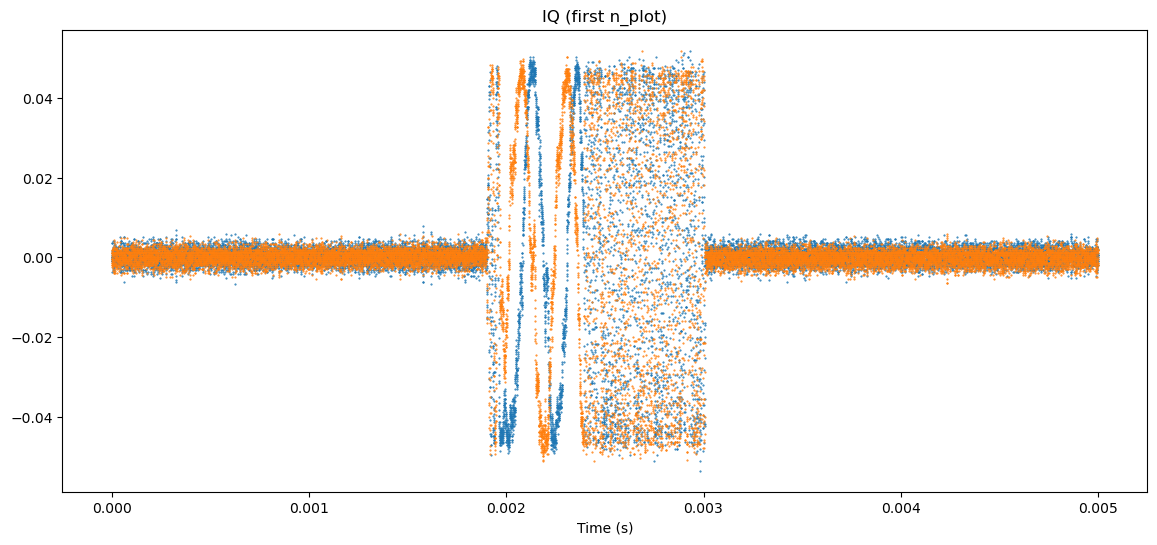

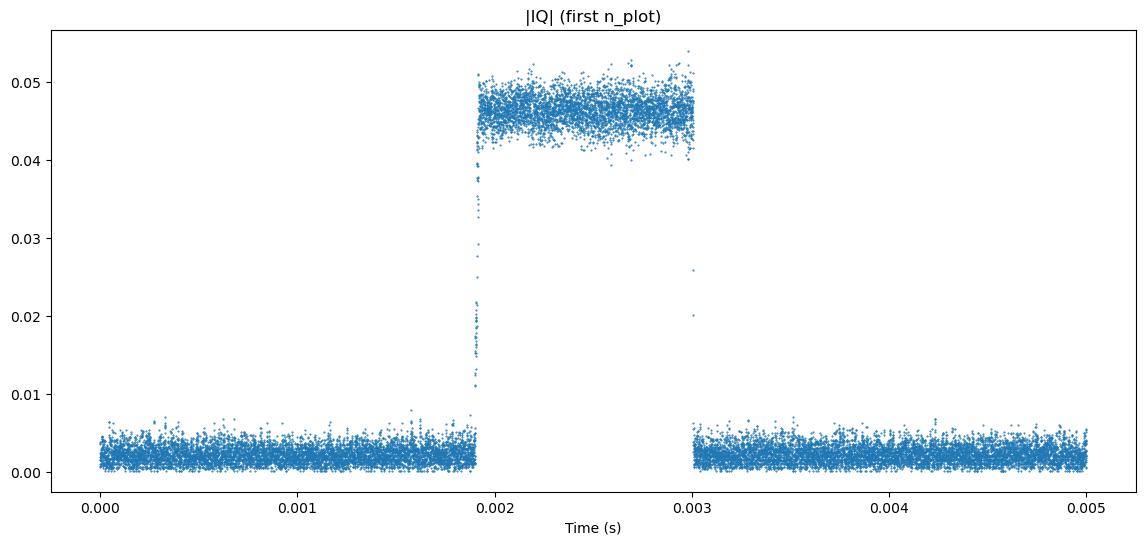

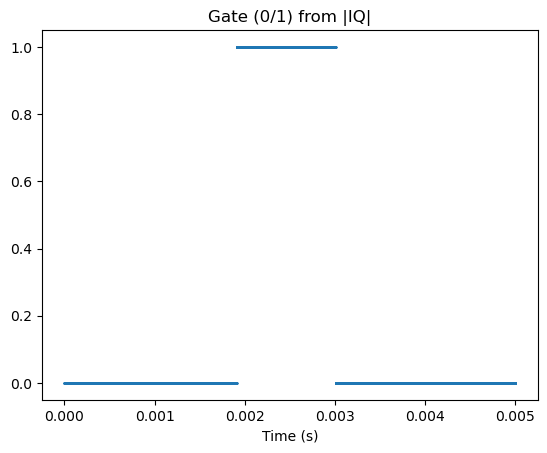

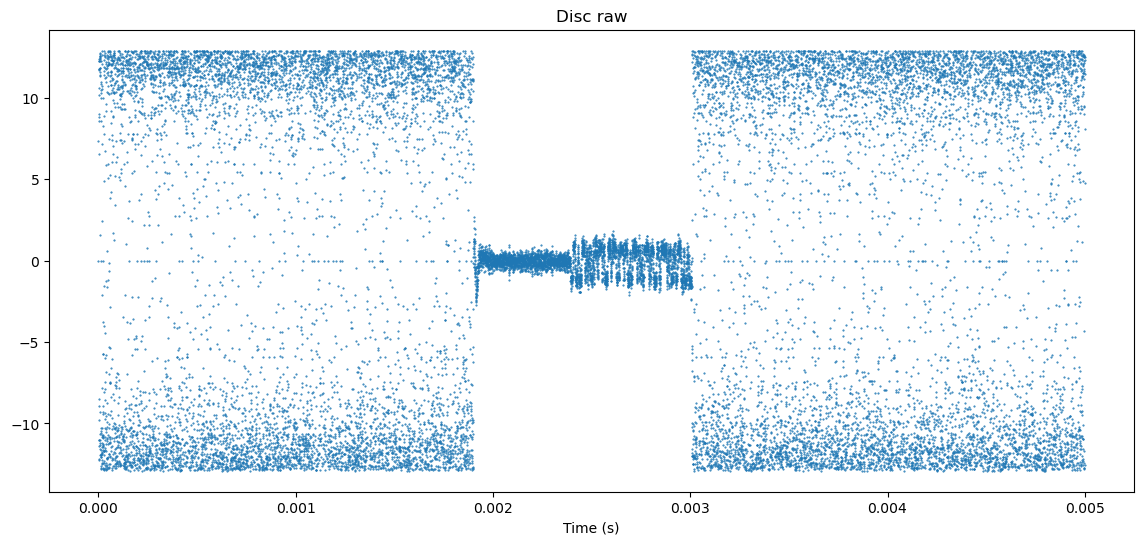

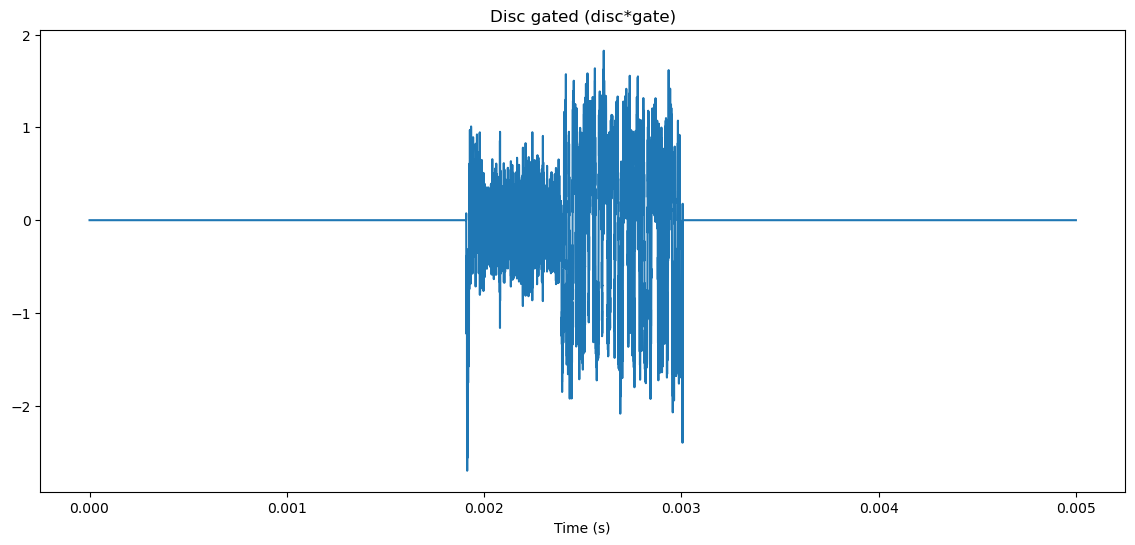

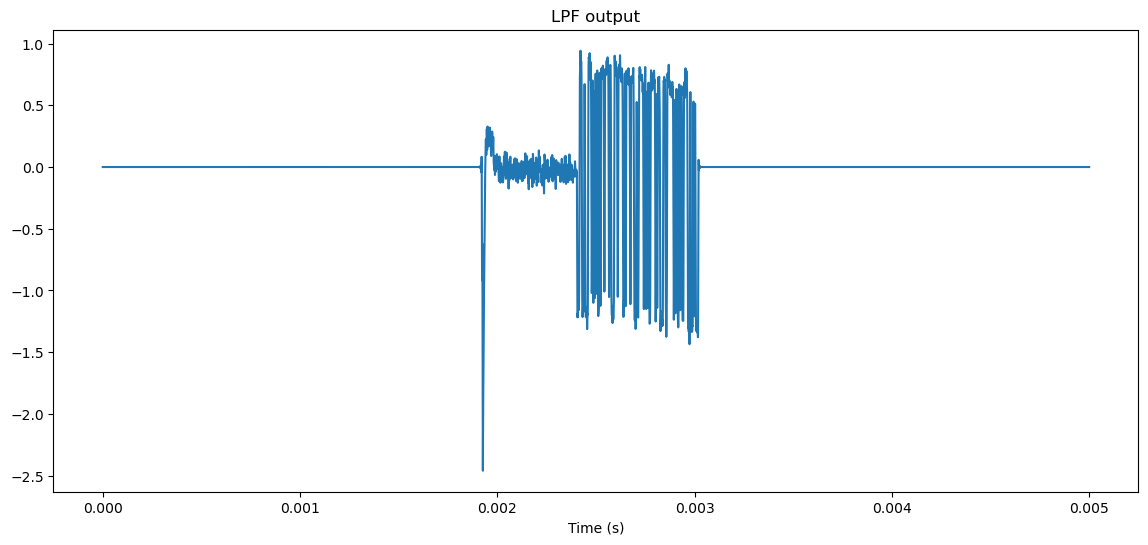

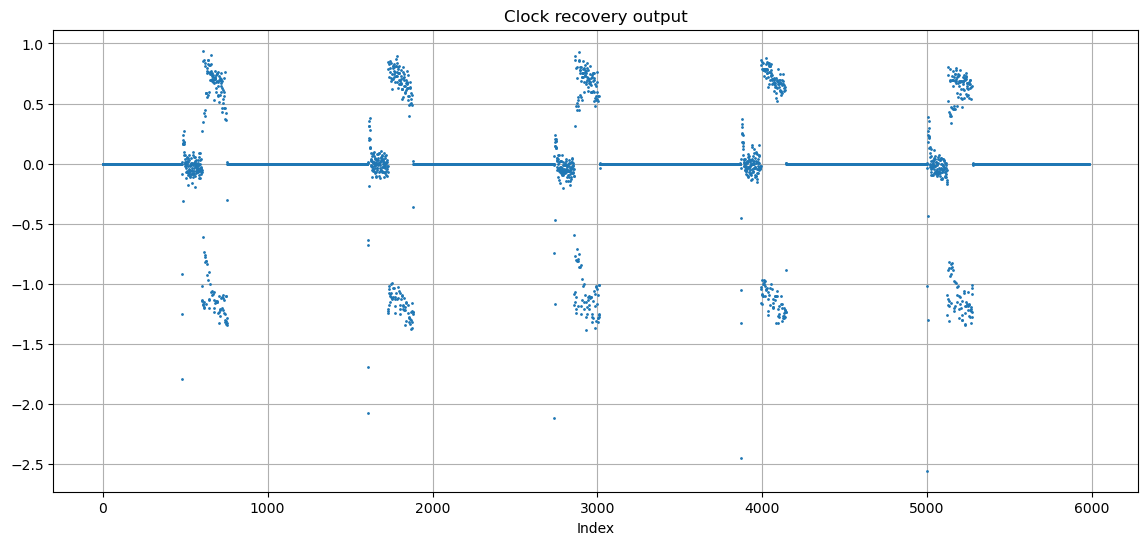

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
#iq_file = r"ls-OFF-4M-p6M.complex32s"
# iq_file = r"ls-OFF-4M-p6M-02.complex32s"   # int16 interleaved I,Q
iq_file = r"ls-OFF-4M-p6M-03.complex32s"
out_bits_file = "out_bits.bin"            # FULL decoded bits (bytes 0/1)

samp_rate = 4_000_000
samples_per_symbol = 16

# Quadrature demod gain: normalize to ~±1 for ±df
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)   # ≈ 4.11

# LPF on discriminator
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# Gate thresholds on |IQ| (tune these!)
# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.03 # above -> gate=1  (hysteresis)
gate_lo = 0.02 # below -> gate=0
gate_initial = 0

# tap files (FULL streams)
tap_iq_file   = "tap_iq.c64"
tap_mag_file  = "tap_mag.f32"
tap_gate_file = "tap_gate.f32"
tap_disc_file = "tap_disc.f32"
tap_dg_file   = "tap_disc_gated.f32"
# tap_rail_file = "tap_disc_rail.f32"
tap_lpf_file  = "tap_lpf.f32"
tap_clk_file  = "tap_clk.f32"
tap_bits_file = "tap_bits.u8"

n_plot = 20000  # plotting only
# -----------------------------

tb = gr.top_block("fsk_burst_gate_then_mm")

# Source: int16 I,Q
src = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f = blocks.short_to_float(1, 32768.0)
q_f = blocks.short_to_float(1, 32768.0)
iq_c = blocks.float_to_complex(1)

# Magnitude -> gate
mag = blocks.complex_to_mag(1)
gate = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)   # outputs 0.0 or 1.0

# Demod
demod = analog.quadrature_demod_cf(float(quad_gain))

# Gate discriminator (disc * gate)
disc_gate = blocks.multiply_ff(1)

# LPF
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

# Clock recovery + slicer
clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)
slicer = digital.binary_slicer_fb()

# Main output
bits_sink = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# Tap sinks
tap_iq_sink   = blocks.file_sink(gr.sizeof_gr_complex, tap_iq_file, False)
tap_mag_sink  = blocks.file_sink(gr.sizeof_float,      tap_mag_file, False)
tap_gate_sink = blocks.file_sink(gr.sizeof_float,      tap_gate_file, False)
tap_disc_sink = blocks.file_sink(gr.sizeof_float,      tap_disc_file, False)
tap_dg_sink   = blocks.file_sink(gr.sizeof_float,      tap_dg_file, False)
# tap_rail_sink = blocks.file_sink(gr.sizeof_float,      tap_rail_file, False)
tap_lpf_sink  = blocks.file_sink(gr.sizeof_float,      tap_lpf_file,  False)
tap_clk_sink  = blocks.file_sink(gr.sizeof_float,      tap_clk_file,  False)
tap_bits_sink = blocks.file_sink(gr.sizeof_char,       tap_bits_file, False)

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# Tap IQ
tb.connect(iq_c, tap_iq_sink)

# Magnitude + gate taps
tb.connect(iq_c, mag)
tb.connect(mag, tap_mag_sink)
tb.connect(mag, gate)
tb.connect(gate, tap_gate_sink)

# Demod + tap
tb.connect(iq_c, demod)
tb.connect(demod, tap_disc_sink)

# disc * gate
tb.connect(demod, (disc_gate, 0))
tb.connect(gate,  (disc_gate, 1))
tb.connect(disc_gate, tap_dg_sink)

# LPF + tap
tb.connect(disc_gate, lpf)
tb.connect(lpf, tap_lpf_sink)

# Clock recovery + tap
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk_sink)

# Bits + taps
tb.connect(clockrec, slicer)
tb.connect(slicer, tap_bits_sink)
tb.connect(slicer, bits_sink)

tb.run()
print("Done. Wrote ALL decoded bits to:", out_bits_file)

# -----------------------------
# Plot first n_plot samples
# -----------------------------
def read_c64(path, n): return np.fromfile(path, dtype=np.complex64, count=n)
def read_f32(path, n): return np.fromfile(path, dtype=np.float32,  count=n)
def read_u8(path, n):  return np.fromfile(path, dtype=np.uint8,    count=n)

iq   = read_c64(tap_iq_file, n_plot)
magv = read_f32(tap_mag_file, n_plot)
gatev= read_f32(tap_gate_file, n_plot)
disc = read_f32(tap_disc_file, n_plot)
dg   = read_f32(tap_dg_file, n_plot)
# railv= read_f32(tap_rail_file, n_plot)
lpfv = read_f32(tap_lpf_file,  n_plot)
clk  = read_f32(tap_clk_file,  n_plot)
bits = read_u8(tap_bits_file,  min(n_plot, 5000))

fig_size = (14, 6)
marker_size = 1

t = np.arange(len(disc)) / samp_rate
t_iq = np.arange(len(iq)) / samp_rate

plt.figure(figsize=fig_size); 
plt.plot(t_iq, iq.real, '.', markersize=1); plt.plot(t_iq, iq.imag, '.', markersize=1)
plt.title("IQ (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, magv, '.', markersize=1); plt.title("|IQ| (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

plt.figure();  
plt.plot(t, gatev, '.', markersize=1); plt.title("Gate (0/1) from |IQ|"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, disc, '.', markersize=1); plt.title("Disc raw"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, dg, markersize=1); plt.title("Disc gated (disc*gate)"); plt.xlabel("Time (s)"); plt.show()
# plt.figure(); plt.plot(t, railv,'.', markersize=1); plt.title("Disc gated + railed"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, lpfv, markersize=1); plt.title("LPF output"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(clk, '.', markersize=2); plt.title("Clock recovery output"); plt.xlabel("Index"); plt.grid(); plt.show()

# plt.figure(figsize=fig_size); 
# m = min(500, len(bits)); plt.step(np.arange(m), bits[:m], where="post"); plt.ylim(-0.2, 1.2)
# plt.title("Bits (first 500)"); plt.xlabel("Bit index"); plt.show()


In [7]:
bits.shape

(5000,)

In [8]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
pattern_str = "1110001"
pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(indices)

[ 604 1732 2862 3994]


# Burst Tag Gate

## Tag Gate Pass Blocks

In [12]:
from gnuradio import gr
import numpy as np
import pmt

class burst_tag_gate_cc(gr.sync_block):
    """
    Pass complex64 samples only when between burst start/end tags.
    Outside burst: outputs 0+0j (muted).
    """

    def __init__(self, start_key="tx_sob", end_key="tx_eob", pass_during_burst=True):
        gr.sync_block.__init__(
            self,
            name="burst_tag_gate_cc",
            in_sig=[np.complex64],
            out_sig=[np.complex64],
        )
        self.start_key = pmt.intern(start_key)
        self.end_key   = pmt.intern(end_key)
        self.in_burst = False
        self.pass_during_burst = bool(pass_during_burst)

    def work(self, input_items, output_items):
        x = input_items[0]
        y = output_items[0]
        n = len(x)

        abs0 = self.nitems_read(0)
        tags = self.get_tags_in_window(0, 0, n)
        tags.sort(key=lambda t: t.offset)

        # Default fill for whole window based on current state
        if self.in_burst == self.pass_during_burst:
            y[:] = x
        else:
            y[:] = 0.0 + 0.0j

        # Apply transitions at tag boundaries inside this work window
        for t in tags:
            rel = int(t.offset - abs0)
            if rel < 0 or rel >= n:
                continue

            if t.key == self.start_key:
                self.in_burst = True
                if self.pass_during_burst:
                    y[rel:] = x[rel:]
                else:
                    y[rel:] = 0.0 + 0.0j

            elif t.key == self.end_key:
                self.in_burst = False
                if self.pass_during_burst:
                    y[rel:] = 0.0 + 0.0j
                else:
                    y[rel:] = x[rel:]

        return n


In [13]:
from gnuradio import gr
import numpy as np
import pmt

class burst_tag_gate_ff(gr.sync_block):
    """
    Pass float32 samples only when between burst start/end tags.
    Outside burst: outputs 0.0
    """

    def __init__(self, start_key="tx_sob", end_key="tx_eob", pass_during_burst=True):
        gr.sync_block.__init__(
            self,
            name="burst_tag_gate_ff",
            in_sig=[np.float32],
            out_sig=[np.float32],
        )
        self.start_key = pmt.intern(start_key)
        self.end_key   = pmt.intern(end_key)
        self.in_burst = False
        self.pass_during_burst = bool(pass_during_burst)

    def work(self, input_items, output_items):
        x = input_items[0]
        y = output_items[0]
        n = len(x)

        abs0 = self.nitems_read(0)
        tags = self.get_tags_in_window(0, 0, n)
        tags.sort(key=lambda t: t.offset)

        if self.in_burst == self.pass_during_burst:
            y[:] = x
        else:
            y[:] = 0.0

        for t in tags:
            rel = int(t.offset - abs0)
            if rel < 0 or rel >= n:
                continue

            if t.key == self.start_key:
                self.in_burst = True
                y[rel:] = x[rel:] if self.pass_during_burst else 0.0

            elif t.key == self.end_key:
                self.in_burst = False
                y[rel:] = 0.0 if self.pass_during_burst else x[rel:]

        return n


Captured 95713 complex samples
Total tags captured: 10
'burst' tags captured: 10
tag: offset=7692, key=burst, value=#t, srcid=burst_tagger67
tag: offset=12050, key=burst, value=#f, srcid=burst_tagger67
tag: offset=25767, key=burst, value=#t, srcid=burst_tagger67
tag: offset=30124, key=burst, value=#f, srcid=burst_tagger67
tag: offset=43839, key=burst, value=#t, srcid=burst_tagger67
tag: offset=48199, key=burst, value=#f, srcid=burst_tagger67
tag: offset=61912, key=burst, value=#t, srcid=burst_tagger67
tag: offset=66273, key=burst, value=#f, srcid=burst_tagger67
tag: offset=80010, key=burst, value=#t, srcid=burst_tagger67
tag: offset=84372, key=burst, value=#f, srcid=burst_tagger67


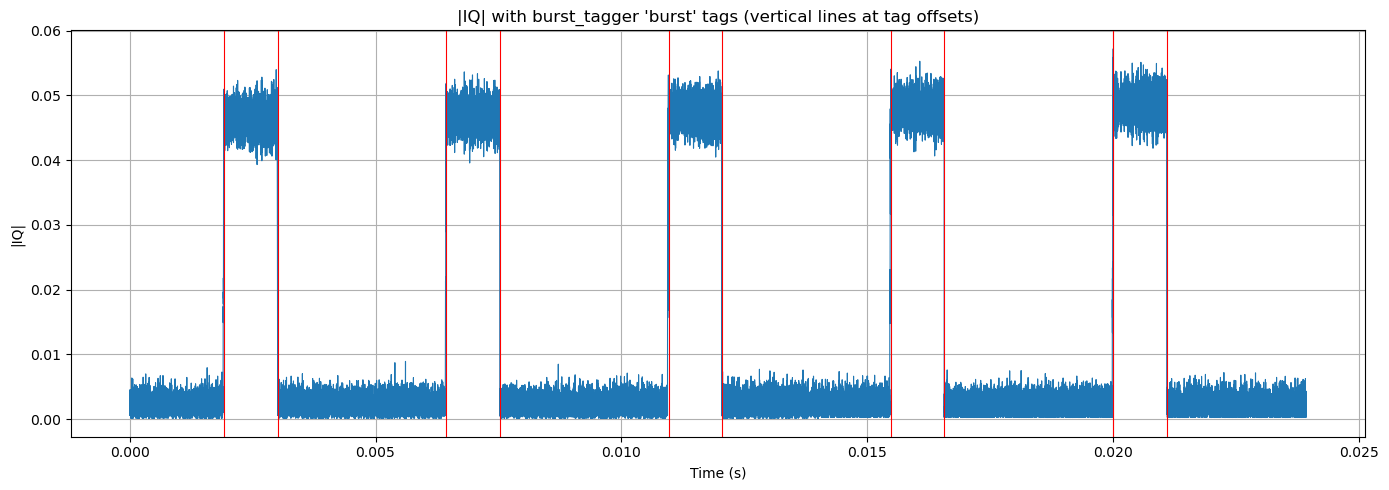

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks

# -----------------------------
# PARAMETERS
# -----------------------------
# iq_file = r"ls-OFF-4M-p6M.complex32s" 
# iq_file = r"ls-OFF-4M-p6M-02.complex32s"  # int16 interleaved I,Q
iq_file = r"ls-OFF-4M-p6M-03.complex32s"
samp_rate = 4_000_000

n_plot = 200_000

# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0

smooth_len = 64  # helps avoid trigger chatter
tag_key = "burst"  # default key name used by burst_tagger docs



tap_ma = blocks.vector_sink_f()


# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tagger_minimal_two_input")

# Source: int16 I,Q  (your starting point)
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0 float

# Convert gate 0/1 -> trigger short +/-1
# map: 0 -> -1, 1 -> +1
#  gatef: 0 or 1
#  gatef - 0.5 -> -0.5 or +0.5
#  *2 -> -1 or +1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Limit capture for plotting + capture tags
head  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink = blocks.vector_sink_c()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger short stream (+/-)

tb.connect(bt, head)
tb.connect(head, vsink)


tb.connect(ma, tap_ma)

tb.run()

# -----------------------------
# Pull samples + tags and plot
# -----------------------------
x = np.array(vsink.data(), dtype=np.complex64)
ma_vals = np.array(tap_ma.data(), dtype=np.float32)


tags = list(vsink.tags())

burst_tags = [t for t in tags if str(t.key) == tag_key]
print(f"Captured {len(x)} complex samples")
print(f"Total tags captured: {len(tags)}")
print(f"'{tag_key}' tags captured: {len(burst_tags)}")
for t in burst_tags[:10]:
    print(f"tag: offset={t.offset}, key={t.key}, value={t.value}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| with burst_tagger 'burst' tags (vertical lines at tag offsets)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")

for tt in burst_tags:
    idx = int(tt.offset)
    if 0 <= idx < len(x):
        plt.axvline(idx / samp_rate, linewidth=0.8, color='red')

plt.grid(True)
plt.tight_layout()
plt.show()


## With pass-gate

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks
import pmt

# -----------------------------
# Tag-gated pass block (complex)
# -----------------------------
class burst_tag_gate_cc(gr.sync_block):
    """
    Mute (output 0+0j) when not inside a burst, based on a burst tag.
    Burst state is controlled by tags with key==tag_key:

      - If tag value is integer:
          >0  => enter burst
          <=0 => exit burst
      - If tag value is bool:
          True  => enter burst
          False => exit burst
      - If tag value is PMT NIL:
          treat as "start" (enter burst)

    Tags are propagated downstream.
    """
    def __init__(self, tag_key="burst", start_on_nil=True, initial_in_burst=False):
        gr.sync_block.__init__(
            self,
            name="burst_tag_gate_cc",
            in_sig=[np.complex64],
            out_sig=[np.complex64],
        )
        self.tag_key = pmt.intern(tag_key)
        self.start_on_nil = bool(start_on_nil)
        self.in_burst = bool(initial_in_burst)

        # Ensure tags propagate
        try:
            self.set_tag_propagation_policy(gr.TPP_ALL_TO_ALL)
        except Exception:
            pass

    def _value_to_state(self, v):
        # NIL => usually "start"
        if pmt.is_null(v):
            return True if self.start_on_nil else None

        # Integer?
        if pmt.is_integer(v):
            return pmt.to_long(v) > 0

        # Bool?
        if pmt.is_bool(v):
            return bool(pmt.to_bool(v))

        # Fallback: try string parse
        try:
            s = pmt.write_string(v)
            if s in ("#t", "true", "True", "1"):
                return True
            if s in ("#f", "false", "False", "0"):
                return False
        except Exception:
            pass

        # Unknown -> ignore
        return None

    def work(self, input_items, output_items):
        x = input_items[0]
        y = output_items[0]
        n = len(x)

        abs0 = self.nitems_read(0)
        tags = self.get_tags_in_window(0, 0, n)
        tags.sort(key=lambda t: t.offset)

        # Default fill for this window based on current state
        if self.in_burst:
            y[:] = x
        else:
            y[:] = 0.0 + 0.0j

        # Apply transitions at tag offsets
        for t in tags:
            if t.key != self.tag_key:
                continue

            rel = int(t.offset - abs0)
            if rel < 0 or rel >= n:
                continue

            new_state = self._value_to_state(t.value)
            if new_state is None:
                continue

            self.in_burst = new_state
            if self.in_burst:
                y[rel:] = x[rel:]
            else:
                y[rel:] = 0.0 + 0.0j

        return n

Captured 95713 complex samples
Total tags captured: 10
'burst' tags captured: 10
tag: offset=7692, key=burst, value=#t, srcid=burst_tagger117
tag: offset=12050, key=burst, value=#f, srcid=burst_tagger117
tag: offset=25767, key=burst, value=#t, srcid=burst_tagger117
tag: offset=30124, key=burst, value=#f, srcid=burst_tagger117
tag: offset=43839, key=burst, value=#t, srcid=burst_tagger117
tag: offset=48199, key=burst, value=#f, srcid=burst_tagger117
tag: offset=61912, key=burst, value=#t, srcid=burst_tagger117
tag: offset=66273, key=burst, value=#f, srcid=burst_tagger117
tag: offset=80010, key=burst, value=#t, srcid=burst_tagger117
tag: offset=84372, key=burst, value=#f, srcid=burst_tagger117


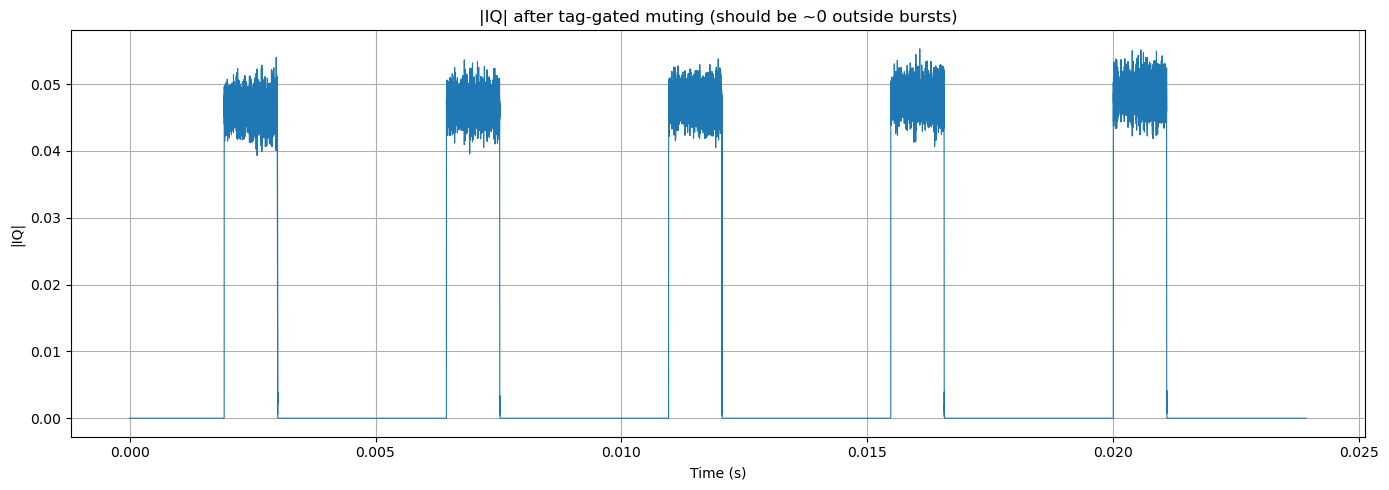

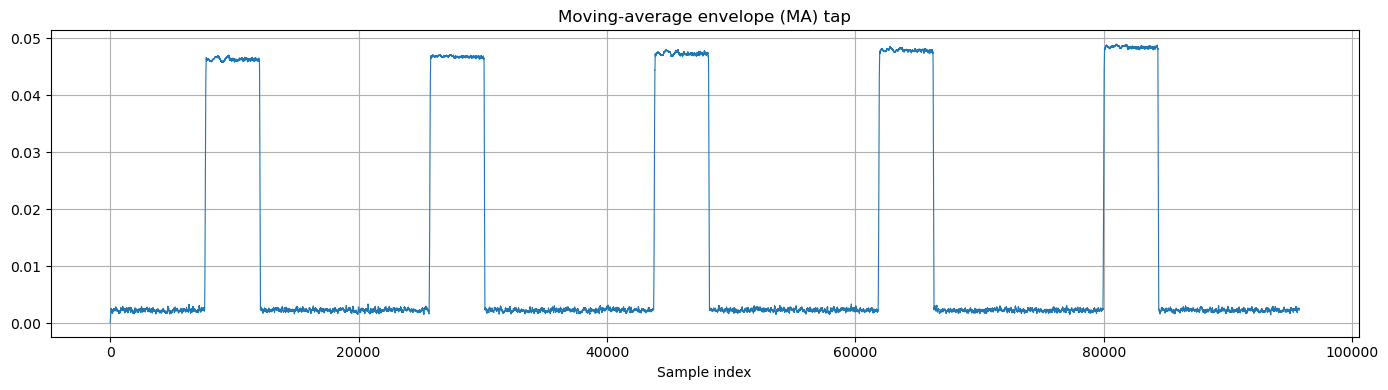

In [17]:
# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-03.complex32s"
samp_rate = 4_000_000
n_plot = 200_000

# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0

smooth_len = 64  # helps avoid trigger chatter
tag_key = "burst"  # the tag key you want to drive gating


tap_ma = blocks.vector_sink_f()

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tagger_minimal_two_input")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# FIX: short_to_float MULTIPLIES by scale; int16 -> [-1,1) needs 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)

iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# NEW: Tag-gated pass (mute) block driven by burst tags
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# Limit capture for plotting + capture tags
head  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink = blocks.vector_sink_c()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# NEW: apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# capture gated stream
tb.connect(tag_gate, head)
tb.connect(head, vsink)

# tap MA for plotting/debug
tb.connect(ma, tap_ma)

tb.run()

# -----------------------------
# Pull samples + tags and plot
# -----------------------------
x = np.array(vsink.data(), dtype=np.complex64)
ma_vals = np.array(tap_ma.data(), dtype=np.float32)

tags = list(vsink.tags())
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Captured {len(x)} complex samples")
print(f"Total tags captured: {len(tags)}")
print(f"'{tag_key}' tags captured: {len(burst_tags)}")
for t in burst_tags[:10]:
    # display value in a readable way
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| after tag-gated muting (should be ~0 outside bursts)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(ma_vals[:min(len(ma_vals), n_plot)], linewidth=0.8)
plt.title("Moving-average envelope (MA) tap")
plt.xlabel("Sample index")
plt.grid(True)
plt.tight_layout()
plt.show()


# Pass-Gate applied to demod

Captured: IQ=5000000 complex, disc=5000000, lpf=5000000, clk=311282, bits=311282
Captured 5000000 complex samples
Total tags captured: 80
'burst' tags captured: 80
tag: offset=3359293, key=burst, value=#t, srcid=burst_tagger90
tag: offset=3363651, key=burst, value=#f, srcid=burst_tagger90
tag: offset=3377368, key=burst, value=#t, srcid=burst_tagger90
tag: offset=3381725, key=burst, value=#f, srcid=burst_tagger90
tag: offset=3395440, key=burst, value=#t, srcid=burst_tagger90
tag: offset=3399800, key=burst, value=#f, srcid=burst_tagger90
tag: offset=3413513, key=burst, value=#t, srcid=burst_tagger90
tag: offset=3417874, key=burst, value=#f, srcid=burst_tagger90
tag: offset=3431611, key=burst, value=#t, srcid=burst_tagger90
tag: offset=3435973, key=burst, value=#f, srcid=burst_tagger90


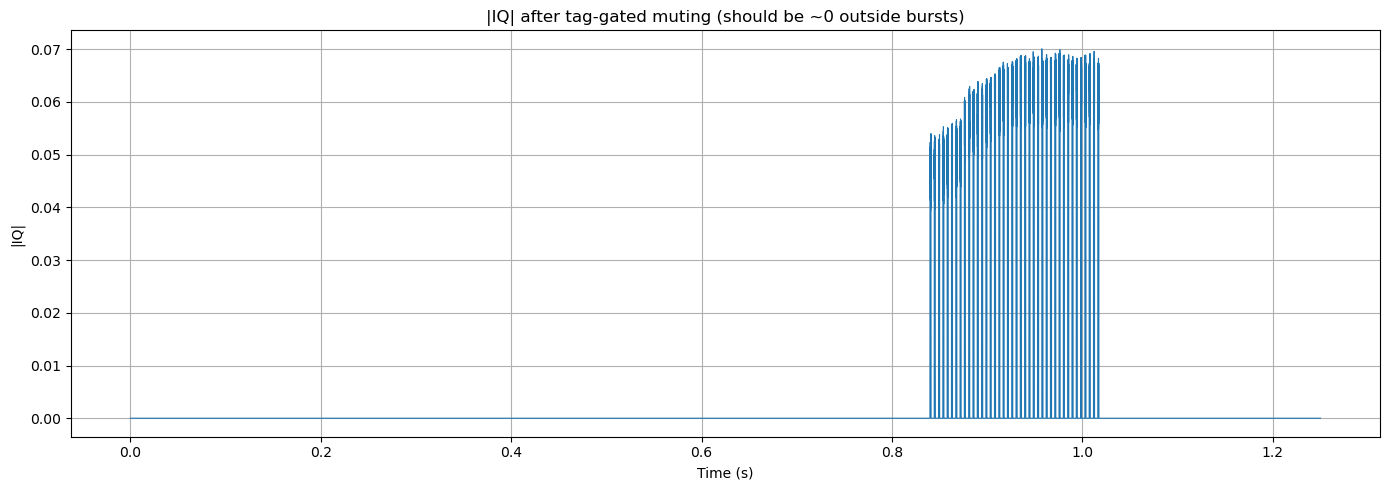

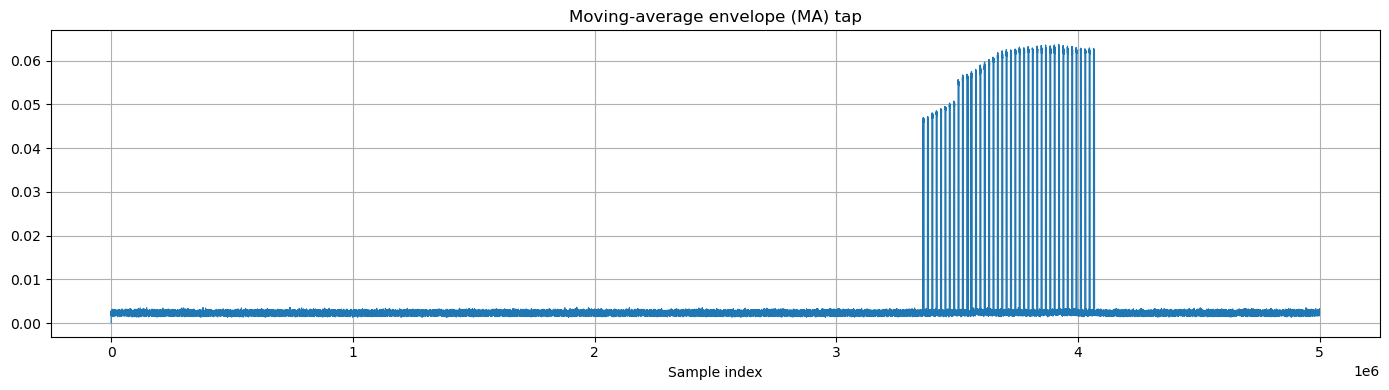

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"
samp_rate = 4_000_000
samples_per_symbol = 16
n_plot = 5_000_000 # 500_000 #200_000

# Quad Gain
df = 155_000  # FSK frequency deviation (freq_spacing / 2)
quad_gain = samp_rate / (2*np.pi*df)   # ≈ 4.11

# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0

lpf_cutoff_hz = 350_000  
lpf_trans_hz  = 100_000

smooth_len = 64  # helps avoid trigger chatter
tag_key = "burst"  # the tag key you want to drive gating


tap_ma = blocks.vector_sink_f()

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tagger_minimal_two_input")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# FIX: short_to_float MULTIPLIES by scale; int16 -> [-1,1) needs 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# Limit capture for plotting + capture tags
head  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink = blocks.vector_sink_c()

# ---- taps (vector sinks) ----
tap_iq   = blocks.vector_sink_c()   # complex IQ after conversion
tap_disc = blocks.vector_sink_f()   # after quadrature demod
tap_lpf  = blocks.vector_sink_f()   # after LPF
tap_clk  = blocks.vector_sink_f()   # after clock recovery
tap_bits = blocks.vector_sink_b()   # after slicer (bytes 0/1)

# 2-FSK discriminator
fsk_disc = analog.quadrature_demod_cf(quad_gain)

# Post-demod LPF
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

# Clock recovery (Mueller & Muller)
clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

# Bit slicer
slicer = digital.binary_slicer_fb()









# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# NEW: Tag-gated pass (mute) block driven by burst tags
tag_gate = burst_tag_gate_cc(tag_key=tag_key)



# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# NEW: apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# capture gated stream
tb.connect(tag_gate, head)
tb.connect(head, vsink)

tb.connect(head, tap_iq)
tb.connect(head, fsk_disc)
tb.connect(fsk_disc, tap_disc)
tb.connect(fsk_disc, lpf)
tb.connect(lpf, tap_lpf)
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk)
tb.connect(clockrec, slicer)
tb.connect(slicer, tap_bits)


# tap MA for plotting/debug
tb.connect(ma, tap_ma)

tb.run()

# -----------------------------
# Pull samples + tags and plot
# -----------------------------
x = np.array(vsink.data(), dtype=np.complex64)
ma_vals = np.array(tap_ma.data(), dtype=np.float32)


iq   = np.asarray(tap_iq.data(),   dtype=np.complex64)
disc = np.asarray(tap_disc.data(), dtype=np.float32)
lpfv = np.asarray(tap_lpf.data(),  dtype=np.float32)
clk  = np.asarray(tap_clk.data(),  dtype=np.float32)
bits = np.asarray(tap_bits.data(), dtype=np.uint8)

print(f"Captured: IQ={iq.size} complex, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")



tags = list(vsink.tags())
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Captured {len(x)} complex samples")
print(f"Total tags captured: {len(tags)}")
print(f"'{tag_key}' tags captured: {len(burst_tags)}")
for t in burst_tags[:10]:
    # display value in a readable way
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| after tag-gated muting (should be ~0 outside bursts)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(ma_vals[:min(len(ma_vals), n_plot)], linewidth=0.8)
plt.title("Moving-average envelope (MA) tap")
plt.xlabel("Sample index")
plt.grid(True)
plt.tight_layout()
plt.show()


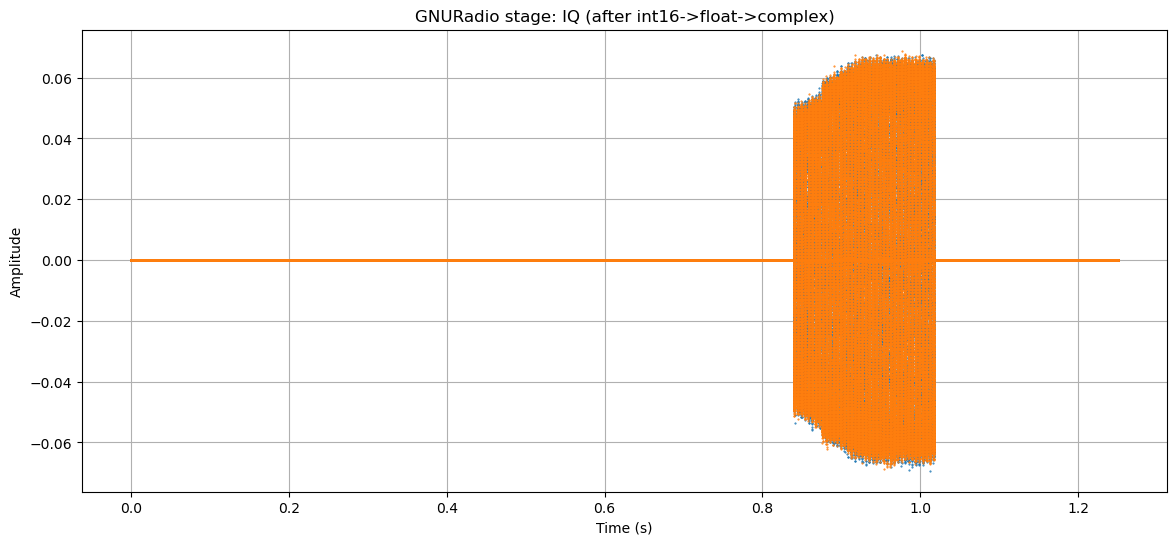

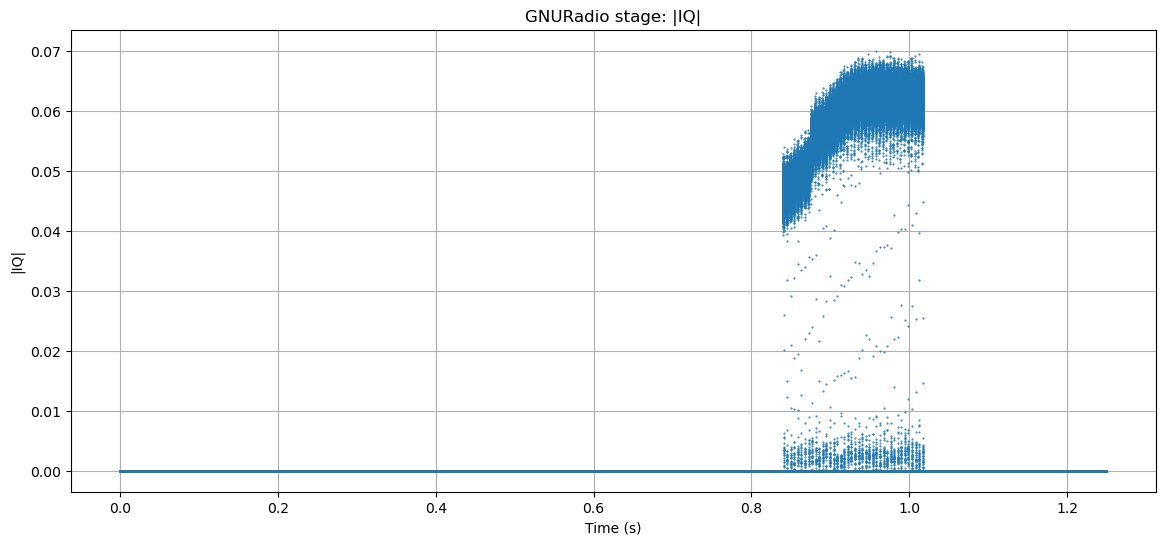

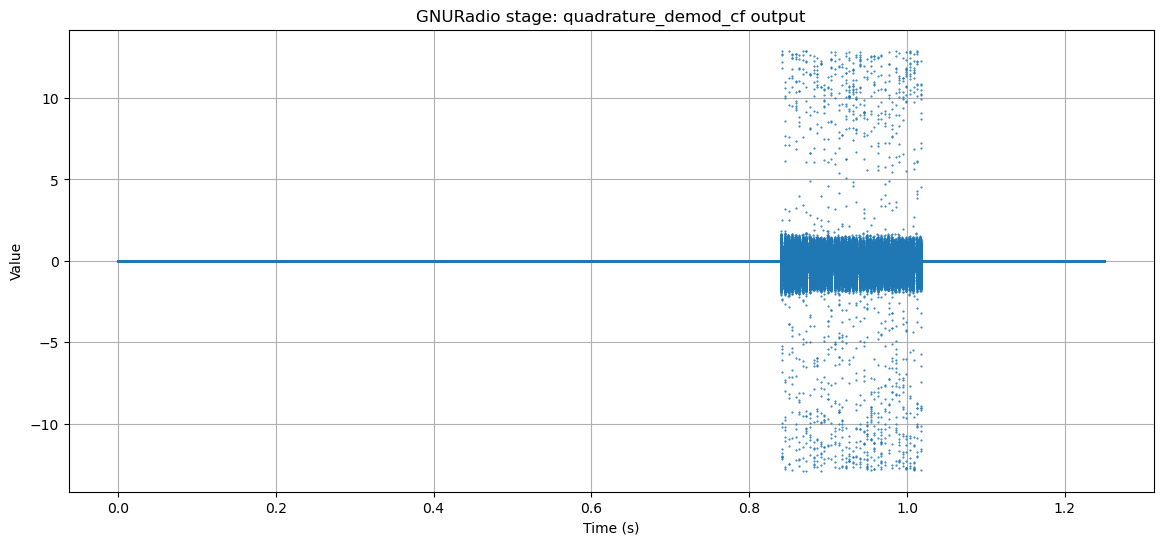

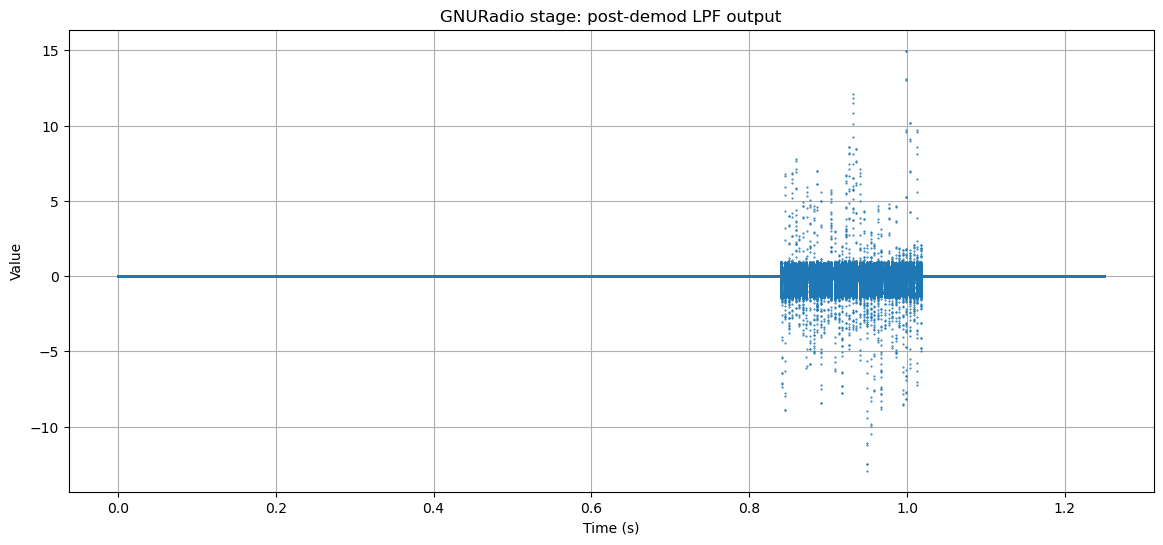

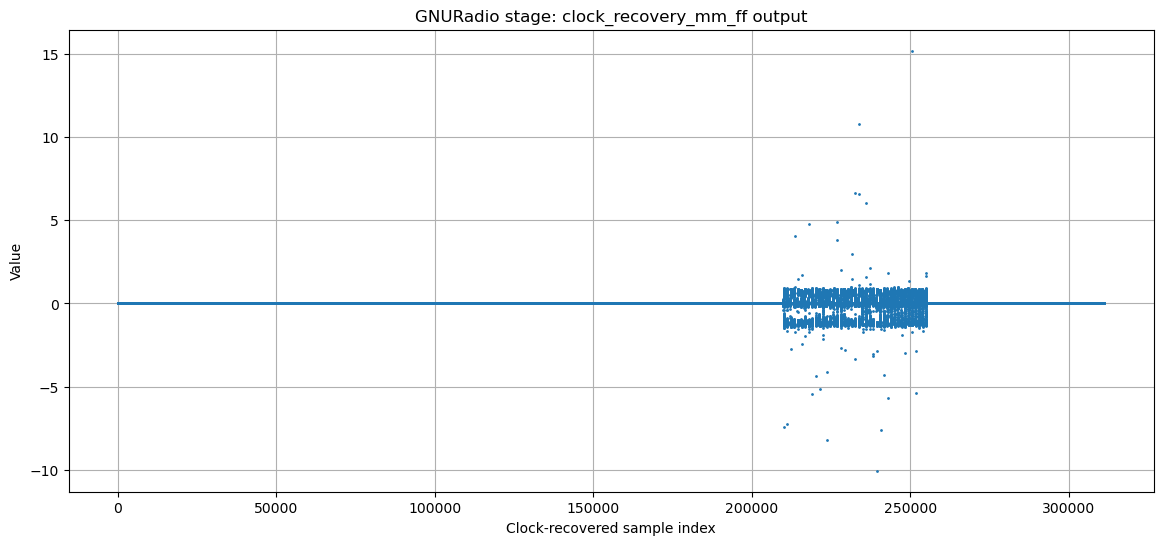

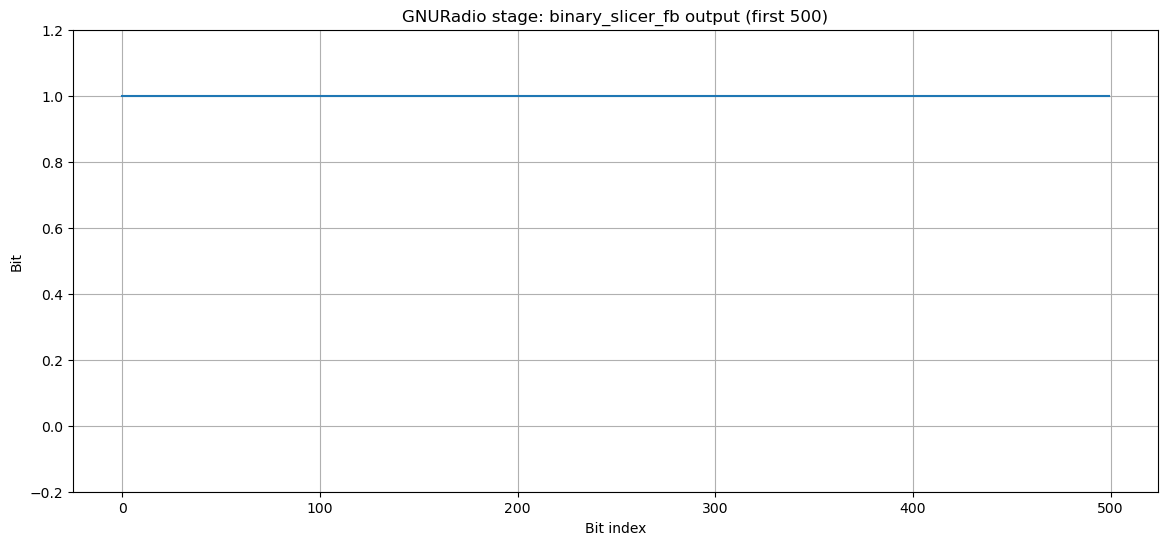

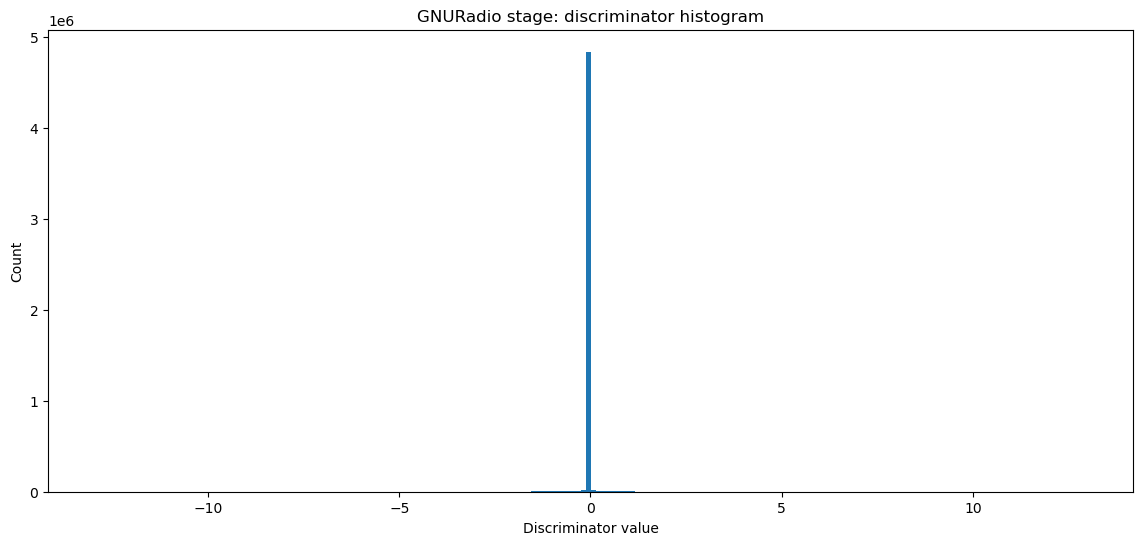

In [12]:
fig_size = (14, 6)
marker_size = 1

t_iq = np.arange(iq.size) / samp_rate
t_f  = np.arange(disc.size) / samp_rate

# 1) IQ (I and Q)
plt.figure(figsize=fig_size)
plt.plot(t_iq, iq.real, '.', markersize=marker_size); 
plt.plot(t_iq, iq.imag, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("GNURadio stage: IQ (after int16->float->complex)")
plt.grid()
plt.show()

# 2) |IQ|
plt.figure(figsize=fig_size)
plt.plot(t_iq, np.abs(iq), '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.title("GNURadio stage: |IQ|")
plt.grid()
plt.show()

# 3) Discriminator output
plt.figure(figsize=fig_size)
plt.plot(t_f, disc, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: quadrature_demod_cf output")
plt.grid()
plt.show()

# 4) LPF output
plt.figure(figsize=fig_size)
plt.plot(np.arange(lpfv.size) / samp_rate, lpfv, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: post-demod LPF output")
plt.grid()
plt.show()

# 5) Clock recovery output (index axis; sample rate has changed)
marker_size = 2
plt.figure(figsize=fig_size)
plt.plot(clk, '.', markersize=marker_size); 
plt.xlabel("Clock-recovered sample index")
plt.ylabel("Value")
plt.title("GNURadio stage: clock_recovery_mm_ff output")
plt.grid()
plt.show()

# 6) Bits (first 500)
plt.figure(figsize=fig_size)
m = min(500, bits.size)
plt.step(np.arange(m), bits[:m], where="post", markersize=marker_size); 
plt.ylim(-0.2, 1.2)
plt.xlabel("Bit index")
plt.ylabel("Bit")
plt.title("GNURadio stage: binary_slicer_fb output (first 500)")
plt.grid()
plt.show()

# Optional: histogram of discriminator (often shows two lobes for 2-FSK)
plt.figure(figsize=fig_size)
plt.hist(disc, bins=200)
plt.xlabel("Discriminator value")
plt.ylabel("Count")
plt.title("GNURadio stage: discriminator histogram")
plt.show()

In [13]:
bits.shape

(311282,)

In [14]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
# pattern_str = "1110001"
# pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(indices)

[210079 211101 212230 213357 214489 215619 216747 217880 219009 220137
 221265 223521 224651 225784 226916 229191 230318 231447 232578 233711
 234849 237126 238253]


## Remved n_plot from data processing

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"
#iq_file = r"ls-OFF-4M-p6M-03.complex32s"
samp_rate = 4_000_000
samples_per_symbol = 16

tap_bits_file = "out_bits.bin"

# Plot-only limit (ONLY used on plot branch)
n_plot = 5_000_000

# Quad Gain
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0

lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

smooth_len = 64
tag_key = "burst"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tagger_two_branch")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# NOTE: short_to_float MULTIPLIES by scale -> use 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)

# Convert gate 0/1 -> trigger short +/-1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-gated pass/mute block driven by burst tags
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# -----------------------------
# Full processing chain (NO head, NO vector sinks)
# -----------------------------
fsk_disc = analog.quadrature_demod_cf(quad_gain)

lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

slicer = digital.binary_slicer_fb()

# IMPORTANT: don’t store full-file outputs in RAM
# Write bits to disk (or use null_sink if you only care that it runs)
bits_out = blocks.file_sink(gr.sizeof_char, "out_bits.bin", False)
# If you want float/diagnostic streams, also use file_sink or null_sink:
# disc_out = blocks.file_sink(gr.sizeof_float, "out_disc.f32", False)

# Termination sinks if you don’t need them:
null_c = blocks.null_sink(gr.sizeof_gr_complex)
null_f = blocks.null_sink(gr.sizeof_float)

# -----------------------------
# Plot branch (ONLY place that uses n_plot + vector sinks)
# -----------------------------
head_plot_c = blocks.head(gr.sizeof_gr_complex, n_plot)
# head_plot_c = blocks.head(gr.sizeof_gr_complex)
vsink_plot_c = blocks.vector_sink_c()

tap_ma = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

head_plot_ma   = blocks.head(gr.sizeof_float, n_plot)       # MA is float stream
head_plot_disc = blocks.head(gr.sizeof_float, n_plot)
head_plot_lpf  = blocks.head(gr.sizeof_float, n_plot)
head_plot_clk  = blocks.head(gr.sizeof_float, n_plot)
head_plot_bits = blocks.head(gr.sizeof_char,  n_plot)       # slicer outputs bytes

# head_plot_ma   = blocks.head(gr.sizeof_float)       # MA is float stream
# head_plot_disc = blocks.head(gr.sizeof_float)
# head_plot_lpf  = blocks.head(gr.sizeof_float)
# head_plot_clk  = blocks.head(gr.sizeof_float)
# head_plot_bits = blocks.head(gr.sizeof_char)       # slicer outputs bytes

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))
tb.connect(f2s,  (bt, 1))

# apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# -----------------------------
# FULL processing path (unbounded)
# -----------------------------
tb.connect(tag_gate, fsk_disc)
tb.connect(fsk_disc, lpf)
tb.connect(lpf, clockrec)
tb.connect(clockrec, slicer)
tb.connect(slicer, bits_out)

# (optional) terminate streams you don’t otherwise sink
# tb.connect(tag_gate, null_c)
# tb.connect(fsk_disc, null_f)

# -----------------------------
# PLOT branch (bounded by n_plot)
# -----------------------------
tb.connect(tag_gate, head_plot_c)
tb.connect(head_plot_c, vsink_plot_c)

tb.connect(ma, head_plot_ma)
tb.connect(head_plot_ma, tap_ma)

tb.connect(fsk_disc, head_plot_disc)
tb.connect(head_plot_disc, tap_disc)

tb.connect(lpf, head_plot_lpf)
tb.connect(head_plot_lpf, tap_lpf)

tb.connect(clockrec, head_plot_clk)
tb.connect(head_plot_clk, tap_clk)

tb.connect(slicer, head_plot_bits)
tb.connect(head_plot_bits, tap_bits)

tb.run()

# -----------------------------
# Pull plot samples + tags and plot
# -----------------------------
def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)
    
x = np.array(vsink_plot_c.data(), dtype=np.complex64)
ma_vals = np.array(tap_ma.data(), dtype=np.float32)

disc = np.asarray(tap_disc.data(), dtype=np.float32)
lpfv = np.asarray(tap_lpf.data(),  dtype=np.float32)
clk  = np.asarray(tap_clk.data(),  dtype=np.float32)
bits = np.asarray(tap_bits.data(), dtype=np.uint8)

bits_out = read_u8(tap_bits_file)


print(f"Plot captured: x={x.size}, ma={ma_vals.size}, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")
print("Full bits written to: out_bits.bin")

tags = list(vsink_plot_c.tags())
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Plot tags captured: total={len(tags)} '{tag_key}'={len(burst_tags)}")
for t in burst_tags[:10]:
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

# t = np.arange(len(x)) / samp_rate

# plt.figure(figsize=(14, 5))
# plt.plot(t, np.abs(x), linewidth=0.8)
# plt.title("|IQ| after tag-gated muting (plot branch only)")
# plt.xlabel("Time (s)")
# plt.ylabel("|IQ|")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) tap (plot branch only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Plot captured: x=5000000, ma=5000000, disc=5000000, lpf=5000000, clk=311273, bits=311273
Full bits written to: out_bits.bin
Plot tags captured: total=80 'burst'=80
tag: offset=3359293, key=burst, value=#t, srcid=burst_tagger343
tag: offset=3363651, key=burst, value=#f, srcid=burst_tagger343
tag: offset=3377368, key=burst, value=#t, srcid=burst_tagger343
tag: offset=3381725, key=burst, value=#f, srcid=burst_tagger343
tag: offset=3395440, key=burst, value=#t, srcid=burst_tagger343
tag: offset=3399800, key=burst, value=#f, srcid=burst_tagger343
tag: offset=3413513, key=burst, value=#t, srcid=burst_tagger343
tag: offset=3417874, key=burst, value=#f, srcid=burst_tagger343
tag: offset=3431611, key=burst, value=#t, srcid=burst_tagger343
tag: offset=3435973, key=burst, value=#f, srcid=burst_tagger343


In [35]:
bits_out.shape

(311273,)

In [31]:
import numpy as np

arr = bits_out

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
# pattern_str = "1110001"
pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(len(indices))
print(indices)

29
[210079 211101 212230 213357 214489 215619 216747 217880 219009 220137
 221265 223521 224651 225784 226916 229191 230318 231447 232578 233711
 234849 237126 238253 241622 242738 244968 246081 247192 250520]


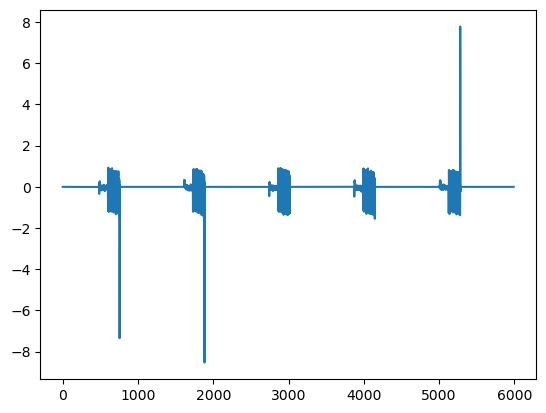

In [26]:
plt.plot(clk)

In [ ]:
# -----------------------------
# Plot branch (ONLY place that uses n_plot + vector sinks)
# -----------------------------
head_plot_c = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink_plot_c = blocks.vector_sink_c()

tap_ma = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

head_plot_ma   = blocks.head(gr.sizeof_float, n_plot)       # MA is float stream
head_plot_disc = blocks.head(gr.sizeof_float, n_plot)
head_plot_lpf  = blocks.head(gr.sizeof_float, n_plot)
head_plot_clk  = blocks.head(gr.sizeof_float, n_plot)
head_plot_bits = blocks.head(gr.sizeof_char,  n_plot)       # slicer outputs bytes



### head block stops the full flow graph

Plot captured: IQ=5000000 complex, MA=5000000, disc=5000000, lpf=5000000, clk=311282, bits=311282
Full-file bits written to: out_bits.bin
Plot tags captured: total=80  'burst'=80
tag: offset=3359293, key=burst, value=#t, srcid=burst_tagger440
tag: offset=3363651, key=burst, value=#f, srcid=burst_tagger440
tag: offset=3377368, key=burst, value=#t, srcid=burst_tagger440
tag: offset=3381725, key=burst, value=#f, srcid=burst_tagger440
tag: offset=3395440, key=burst, value=#t, srcid=burst_tagger440
tag: offset=3399800, key=burst, value=#f, srcid=burst_tagger440
tag: offset=3413513, key=burst, value=#t, srcid=burst_tagger440
tag: offset=3417874, key=burst, value=#f, srcid=burst_tagger440
tag: offset=3431611, key=burst, value=#t, srcid=burst_tagger440
tag: offset=3435973, key=burst, value=#f, srcid=burst_tagger440


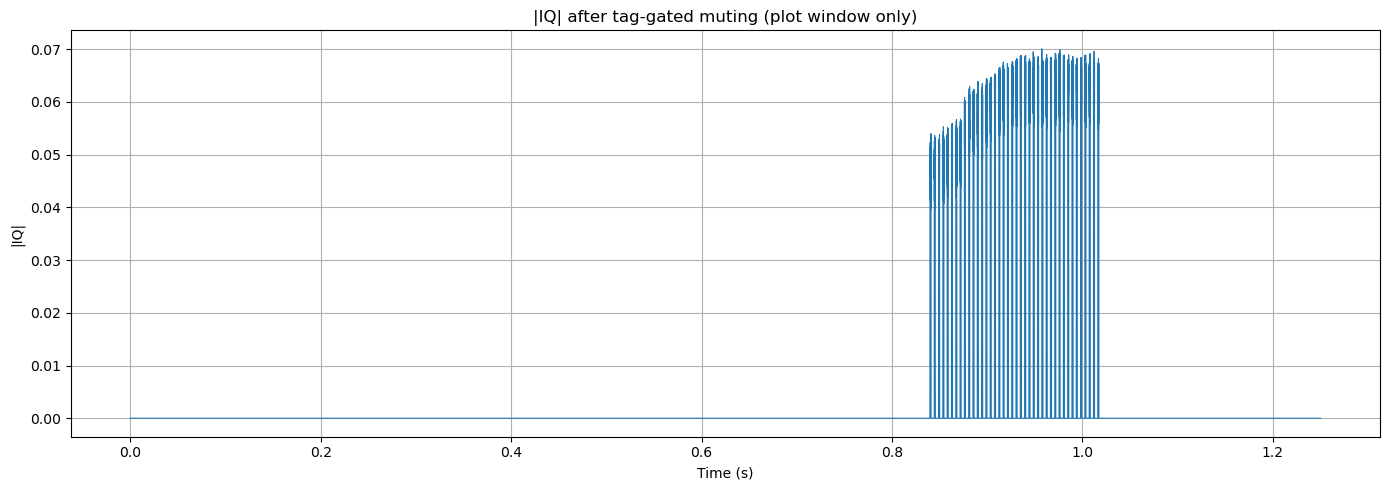

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"     # int16 interleaved I,Q
samp_rate = 4_000_000
samples_per_symbol = 16

# Plot-only limit (ONLY used once, to bound plotting RAM)
n_plot = 5_000_000

# 2-FSK discriminator gain
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

# Gate from envelope
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 64

# Post-demod LPF
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# Tag key used by burst_tagger and tag-driven gate
tag_key = "burst"

# Output (full-file) bits
out_bits_file = "out_bits.bin"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tag_gate_full_plus_plot")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# IMPORTANT: short_to_float MULTIPLIES by scale, so use 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1 (burst_tagger expects short trigger stream)
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1 (+/-)
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-gated pass/mute block driven by burst tags (YOUR custom block)
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# LPF taps reused by both chains
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)

# -----------------------------
# FULL processing chain (unbounded; no heads, no vector sinks)
# -----------------------------
full_disc = analog.quadrature_demod_cf(quad_gain)
full_lpf  = filter.fir_filter_fff(1, lpf_taps)

full_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

full_slicer = digital.binary_slicer_fb()
bits_out    = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# -----------------------------
# PLOT branch (bounded ONCE by n_plot on complex stream)
# -----------------------------
head_plot_c  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink_plot_c = blocks.vector_sink_c()

# Plot-only re-derive envelope/MA from the *same bounded window*
plot_mag = blocks.complex_to_mag(1)
plot_ma  = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)

plot_disc = analog.quadrature_demod_cf(quad_gain)
plot_lpf  = filter.fir_filter_fff(1, lpf_taps)

plot_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

plot_slicer = digital.binary_slicer_fb()

tap_ma   = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging (tags are placed on the complex stream)
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# -----------------------------
# FULL chain (process whole file)
# -----------------------------
tb.connect(tag_gate, full_disc)
tb.connect(full_disc, full_lpf)
tb.connect(full_lpf, full_clockrec)
tb.connect(full_clockrec, full_slicer)
tb.connect(full_slicer, bits_out)

# -----------------------------
# PLOT chain (process only first n_plot complex samples AFTER tag gating)
# -----------------------------
tb.connect(tag_gate, head_plot_c)

# capture bounded IQ + tags
tb.connect(head_plot_c, vsink_plot_c)

# bounded envelope/MA for plotting (aligned with bounded IQ)
tb.connect(head_plot_c, plot_mag)
tb.connect(plot_mag, plot_ma)
tb.connect(plot_ma, tap_ma)

# bounded demod chain for plotting (aligned with bounded IQ)
tb.connect(head_plot_c, plot_disc)
tb.connect(plot_disc, plot_lpf)
tb.connect(plot_lpf, plot_clockrec)
tb.connect(plot_clockrec, plot_slicer)

# taps (NO extra heads anywhere)
tb.connect(plot_disc, tap_disc)
tb.connect(plot_lpf,  tap_lpf)
tb.connect(plot_clockrec, tap_clk)
tb.connect(plot_slicer, tap_bits)

# -----------------------------
# Run
# -----------------------------
tb.run()

# -----------------------------
# Pull plot samples + tags and plot
# -----------------------------
def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)
    
x      = np.asarray(vsink_plot_c.data(), dtype=np.complex64)
ma_vals= np.asarray(tap_ma.data(),       dtype=np.float32)
disc   = np.asarray(tap_disc.data(),     dtype=np.float32)
lpfv   = np.asarray(tap_lpf.data(),      dtype=np.float32)
clk    = np.asarray(tap_clk.data(),      dtype=np.float32)
bits   = np.asarray(tap_bits.data(),     dtype=np.uint8)

bits_out = read_u8(tap_bits_file)

print(f"Plot captured: IQ={x.size} complex, MA={ma_vals.size}, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")
print(f"Full-file bits written to: {out_bits_file}")

# tags captured on the bounded IQ sink
tags = list(vsink_plot_c.tags())
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Plot tags captured: total={len(tags)}  '{tag_key}'={len(burst_tags)}")
for t in burst_tags[:10]:
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| after tag-gated muting (plot window only)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(lpfv, linewidth=0.8)
# plt.title("LPF output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(clk, linewidth=0.8)
# plt.title("Clock recovery output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [38]:
bits.shape

(311108,)

In [41]:
bits_out.shape

(311331,)

In [42]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
# pattern_str = "1110001"
pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(len(indices))
print(indices)

29
[210079 211101 212230 213357 214489 215619 216747 217880 219009 220137
 221265 223521 224651 225784 226916 229191 230318 231447 232578 233711
 234849 237126 238253 241622 242738 244968 246081 247192 250520]


Plot captured: IQ=5000000 complex, MA=5000000, disc=5000000, lpf=5000000, clk=313911, bits=313911
Full-file bits written to: out_bits.bin
Plot tags captured: total=80  'burst'=80
tag: offset=3359293, key=burst, value=#t, srcid=burst_tagger538
tag: offset=3363651, key=burst, value=#f, srcid=burst_tagger538
tag: offset=3377368, key=burst, value=#t, srcid=burst_tagger538
tag: offset=3381725, key=burst, value=#f, srcid=burst_tagger538
tag: offset=3395440, key=burst, value=#t, srcid=burst_tagger538
tag: offset=3399800, key=burst, value=#f, srcid=burst_tagger538
tag: offset=3413513, key=burst, value=#t, srcid=burst_tagger538
tag: offset=3417874, key=burst, value=#f, srcid=burst_tagger538
tag: offset=3431611, key=burst, value=#t, srcid=burst_tagger538
tag: offset=3435973, key=burst, value=#f, srcid=burst_tagger538


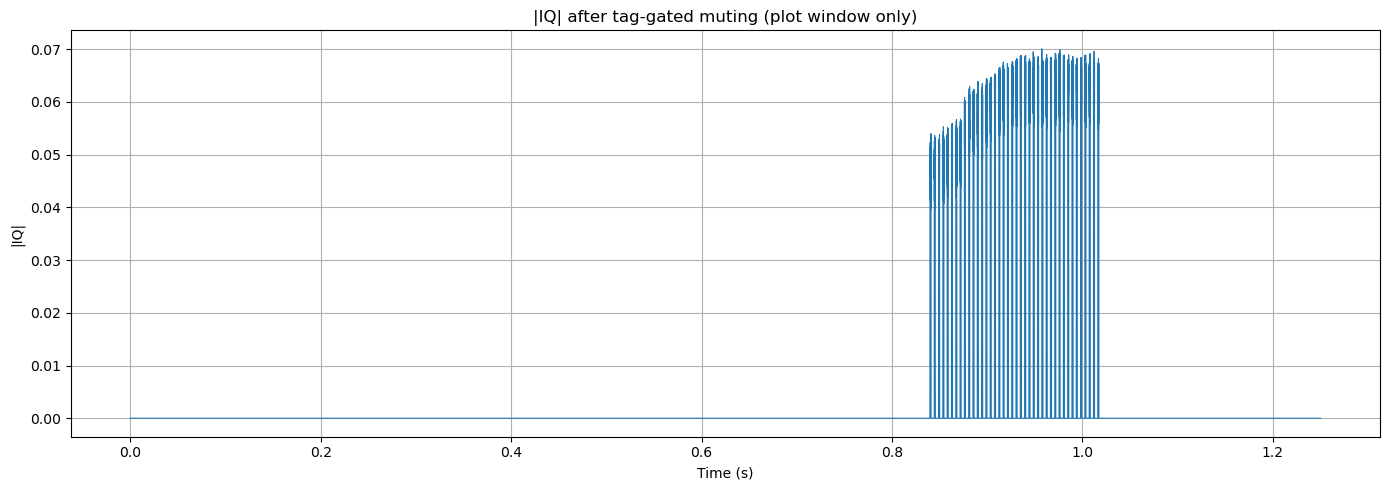

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"   # int16 interleaved I,Q
samp_rate = 4_000_000
samples_per_symbol = 16

# Plot-only limit (ONLY for plotting RAM; full chain processes entire file)
n_plot = 5_000_000

# 2-FSK discriminator gain
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

# Gate from envelope
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 64

# Post-demod LPF
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# Tag key used by burst_tagger and tag-driven gate
tag_key = "burst"

# Output (full-file) bits
out_bits_file = "out_bits.bin"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tag_gate_full_plus_plot_isolated")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# IMPORTANT: short_to_float MULTIPLIES by scale, so use 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1 (burst_tagger expects short trigger stream)
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1 (+/-)
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-gated pass/mute block driven by burst tags (YOUR custom block)
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# LPF taps reused by both chains
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)

# -----------------------------
# FULL processing chain (unbounded; no heads, no vector sinks)
# -----------------------------
full_disc = analog.quadrature_demod_cf(quad_gain)
full_lpf  = filter.fir_filter_fff(1, lpf_taps)

full_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

full_slicer = digital.binary_slicer_fb()
bits_out    = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# -----------------------------
# PLOT branch (bounded, and ISOLATED so it won't stop the full chain)
# -----------------------------
# IMPORTANT: isolate the plot branch so head() can't terminate the whole flowgraph
plot_copy = blocks.copy(gr.sizeof_gr_complex)

head_plot_c  = blocks.head(gr.sizeof_gr_complex, n_plot)   # ONLY use of n_plot
vsink_plot_c = blocks.vector_sink_c()

# Plot-only chain (separate instances so plotting doesn't disturb full chain)
plot_mag = blocks.complex_to_mag(1)
plot_ma  = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)

plot_disc = analog.quadrature_demod_cf(quad_gain)
plot_lpf  = filter.fir_filter_fff(1, lpf_taps)

plot_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

plot_slicer = digital.binary_slicer_fb()

tap_ma   = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging (tags are placed on the complex stream)
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# -----------------------------
# FULL chain (process whole file)
# -----------------------------
tb.connect(tag_gate, full_disc)
tb.connect(full_disc, full_lpf)
tb.connect(full_lpf, full_clockrec)
tb.connect(full_clockrec, full_slicer)
tb.connect(full_slicer, bits_out)

# -----------------------------
# PLOT chain (safe: isolated by copy, bounded by head)
# -----------------------------
tb.connect(tag_gate, plot_copy)       # isolate branch from scheduler DONE
tb.connect(plot_copy, head_plot_c)    # bound plot window

# capture bounded IQ + tags
tb.connect(head_plot_c, vsink_plot_c)

# bounded envelope/MA for plotting (aligned with bounded IQ)
tb.connect(head_plot_c, plot_mag)
tb.connect(plot_mag, plot_ma)
tb.connect(plot_ma, tap_ma)

# bounded demod chain for plotting (aligned with bounded IQ)
tb.connect(head_plot_c, plot_disc)
tb.connect(plot_disc, plot_lpf)
tb.connect(plot_lpf, plot_clockrec)
tb.connect(plot_clockrec, plot_slicer)

# taps (NO extra heads anywhere)
tb.connect(plot_disc, tap_disc)
tb.connect(plot_lpf,  tap_lpf)
tb.connect(plot_clockrec, tap_clk)
tb.connect(plot_slicer, tap_bits)

# -----------------------------
# Run
# -----------------------------
tb.run()

# -----------------------------
# Pull plot samples + tags and plot
# -----------------------------
x       = np.asarray(vsink_plot_c.data(), dtype=np.complex64)
ma_vals = np.asarray(tap_ma.data(),       dtype=np.float32)
disc    = np.asarray(tap_disc.data(),     dtype=np.float32)
lpfv    = np.asarray(tap_lpf.data(),      dtype=np.float32)
clk     = np.asarray(tap_clk.data(),      dtype=np.float32)
bits    = np.asarray(tap_bits.data(),     dtype=np.uint8)


def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)

bits_ = read_u8(tap_bits_file)

print(f"Plot captured: IQ={x.size} complex, MA={ma_vals.size}, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")
print(f"Full-file bits written to: {out_bits_file}")

# tags captured on the bounded IQ sink
tags = list(vsink_plot_c.tags())
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Plot tags captured: total={len(tags)}  '{tag_key}'={len(burst_tags)}")
for t in burst_tags[:10]:
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| after tag-gated muting (plot window only)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(lpfv, linewidth=0.8)
# plt.title("LPF output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(clk, linewidth=0.8)
# plt.title("Clock recovery output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [46]:
bits.shape

(313911,)

In [47]:
bits_.shape

(313531,)

### Just one stream

Full-file bits written to: out_bits.bin
Tap files written:
  tap_iq_gated.c64 tap_ma.f32 tap_disc.f32 tap_lpf.f32 tap_clk.f32
Plot arrays: IQ=5000000, MA=5000000, disc=5000000, lpf=5000000, clk=4167412


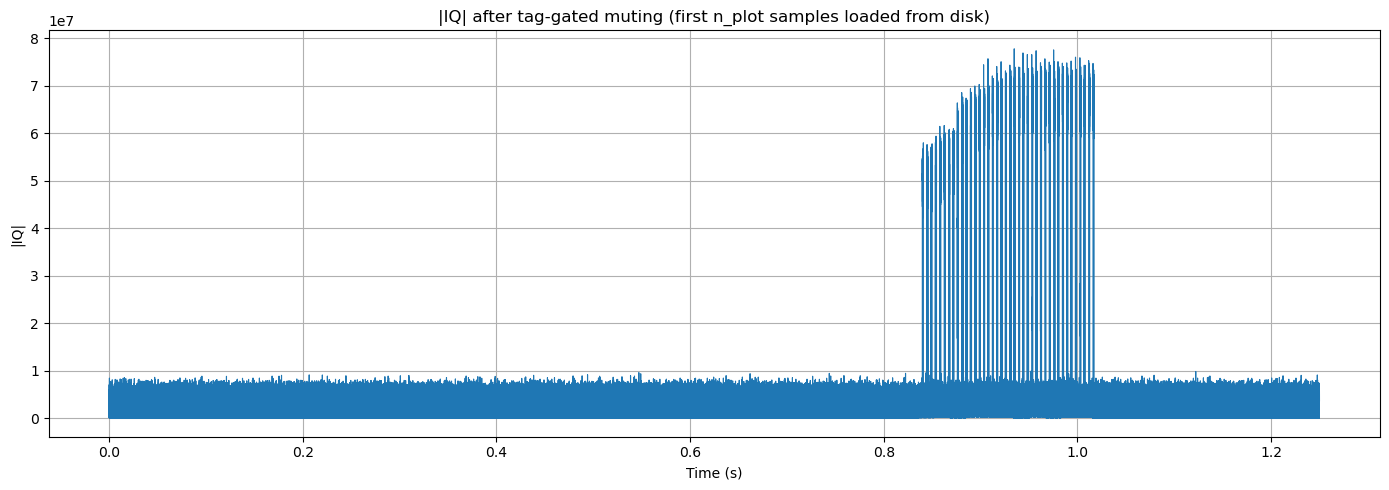

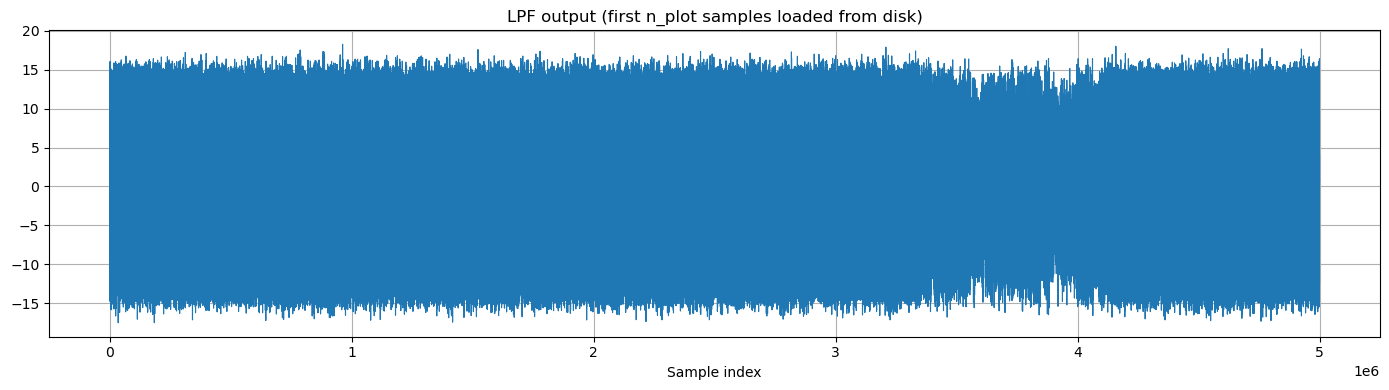

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"   # int16 interleaved I,Q
samp_rate = 4_000_000
samples_per_symbol = 16

# ONLY used for plotting (limits NumPy arrays, not processing)
n_plot = 5_000_000

# 2-FSK discriminator gain
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

# Envelope gate
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 64

# Post-demod LPF
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

tag_key = "burst"

# Output files (full processing goes here)
out_bits_file = "out_bits.bin"

# Debug/plot tap files (full length on disk; we only read first n_plot for plotting)
tap_iq_file   = "tap_iq_gated.c64"
tap_ma_file   = "tap_ma.f32"
tap_disc_file = "tap_disc.f32"
tap_lpf_file  = "tap_lpf.f32"
tap_clk_file  = "tap_clk.f32"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("single_stream_full_processing_plot_from_files")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# IMPORTANT: short_to_float MULTIPLIES by scale => use 1/32768
i_f   = blocks.short_to_float(1, 1.0/32768.0)
q_f   = blocks.short_to_float(1, 1.0/32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1 (+/-)
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-driven gate (YOUR custom block)
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# Demod chain
disc = analog.quadrature_demod_cf(quad_gain)

lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

slicer = digital.binary_slicer_fb()

# -----------------------------
# File sinks for full-length capture (plot later by reading only first n_plot)
# -----------------------------
tap_iq_sink   = blocks.file_sink(gr.sizeof_gr_complex, tap_iq_file, False)
tap_ma_sink   = blocks.file_sink(gr.sizeof_float,      tap_ma_file, False)
tap_disc_sink = blocks.file_sink(gr.sizeof_float,      tap_disc_file, False)
tap_lpf_sink  = blocks.file_sink(gr.sizeof_float,      tap_lpf_file, False)
tap_clk_sink  = blocks.file_sink(gr.sizeof_float,      tap_clk_file, False)

bits_out      = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# (optional) make file output unbuffered-ish for debugging; harmless otherwise
# tap_iq_sink.set_unbuffered(True)
# bits_out.set_unbuffered(True)

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# envelope / trigger
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))
tb.connect(f2s,  (bt, 1))

# tag-gated muting
tb.connect(bt, tag_gate)

# demod chain (single stream)
tb.connect(tag_gate, disc)
tb.connect(disc, lpf)
tb.connect(lpf, clockrec)
tb.connect(clockrec, slicer)
tb.connect(slicer, bits_out)

# tap-to-disk (does NOT affect scheduler termination)
tb.connect(tag_gate, tap_iq_sink)   # gated IQ
tb.connect(ma,       tap_ma_sink)   # MA envelope (ungated; if you want gated MA, compute MA after tag_gate)
tb.connect(disc,     tap_disc_sink)
tb.connect(lpf,      tap_lpf_sink)
tb.connect(clockrec, tap_clk_sink)

# -----------------------------
# Run full file
# -----------------------------
tb.run()

print(f"Full-file bits written to: {out_bits_file}")
print("Tap files written:")
print(" ", tap_iq_file, tap_ma_file, tap_disc_file, tap_lpf_file, tap_clk_file)

# -----------------------------
# Plot: load ONLY first n_plot items from tap files
# -----------------------------
# IQ: complex64
x = np.fromfile(tap_iq_file, dtype=np.complex64, count=n_plot)

# Floats: float32
ma_vals = np.fromfile(tap_ma_file,   dtype=np.float32, count=n_plot)
disc_v  = np.fromfile(tap_disc_file, dtype=np.float32, count=n_plot)
lpf_v   = np.fromfile(tap_lpf_file,  dtype=np.float32, count=n_plot)
clk_v   = np.fromfile(tap_clk_file,  dtype=np.float32, count=n_plot)

print(f"Plot arrays: IQ={x.size}, MA={ma_vals.size}, disc={disc_v.size}, lpf={lpf_v.size}, clk={clk_v.size}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| after tag-gated muting (first n_plot samples loaded from disk)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) (first n_plot samples loaded from disk)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(lpf_v, linewidth=0.8)
# plt.title("LPF output (first n_plot samples loaded from disk)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(clk_v, linewidth=0.8)
# plt.title("Clock recovery output (first n_plot samples loaded from disk)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [50]:
def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)
    
bits_ = read_u8(out_bits_file)

In [51]:
bits_.shape

(4167412,)

In [52]:
import numpy as np

arr = bits_

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110" # x 307
# pattern_str = "1110001" # x 867
pattern_str = "11100010000111101010101001011110111110" # x 316
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(len(indices))
print(indices)

92
[ 244262  247618  250930  258631  262021  264248  268626  272060  282282
  287830  288842  610332  612643  618357  619371  621653  622791  624993
  628406  635992  637014  638131  649040  652353  654519  656731  658983
 1021223 1024514 1025646 1027928 1031185 1032321 1036914 1041253 1042378
 1043526 1045806 1050367 1051504 1053741 1059369 1062800 1526412 1533186
 1535447 1537791 1542297 2020289 2022514 2029132 2031412 2033519 2040229
 2041384 2047162 2057305 2061797 2575998 2580463 2606105 2607257 2613987
 2616258 2618484 2620732 3157081 3158229 3161586 3162732 3165032 3169423
 3171618 3177151 3187123 3188267 3598984 3600009 3602231 3604354 3605483
 3608828 3609850 3612070 3616660 3617682 3630758 3632971 3633996 3636306
 3637440 3638561]
